## Этап 1. выбор датасета, eda и baseline


### Шаг 1. команда и роли
- [x] соберите команду и распределите роли

Состав команды:
  - Коробейников Андрей - организация, первичное наполнение, доработки
  - Комова Влада - написание кода, ревью, доработки
  - Епифанцев Петр - написание кода, ревью, доработки
  - Истомин Александр - ревью, доработки, визуализации

### Шаг 2. выбор датасета
- [x] выберите датасет, который соответствует требованиям проекта

- выбран датасет [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk/data)
- будем исследовать риск дефолта по заявке клиента и его кредитной истории
- основная задача проекта
  - предсказать вероятность дефолта клиента
- целевая переменная
  - target
- тип задачи
  - бинарная классификация
- практический смысл
  - модель может помочь кредитору лучше оценивать риск клиента


Используемые таблицы:
  - application train
  - application test
  - bureau
  - bureau balance
  - previous application
  - pos cash balance
  - installments payments
  - credit card balance

### Шаг 3. согласование датасета и команды
- [x] согласуйте состав команды и выбранный датасет с лектором

- согласовано

### Шаг 4. провести eda и построить baseline
- [x] исследуйте данные
- [x] постройте визуализации
- [x] протестируйте базовые модели
- [x] найдите первые закономерности и гипотезы



In [ ]:
import os
import getpass
os.environ["KAGGLE_API_TOKEN"] = "xxx" # ходим под моей апишкой, чтобы не проходить аутентификацию

In [ ]:
!mkdir -p /content/home_credit_data
!kaggle competitions download -c home-credit-default-risk -p /content/home_credit_data
!unzip -qo /content/home_credit_data/home-credit-default-risk.zip -d /content/home_credit_data
!ls -lh /content/home_credit_data

home-credit-default-risk.zip: Skipping, found more recently modified local copy (use --force to force download)
total 3.2G
-rw-r--r-- 1 root root  26M Dec 11  2019 application_test.csv
-rw-r--r-- 1 root root 159M Dec 11  2019 application_train.csv
-rw-r--r-- 1 root root 359M Dec 11  2019 bureau_balance.csv
-rw-r--r-- 1 root root 163M Dec 11  2019 bureau.csv
-rw-r--r-- 1 root root 405M Dec 11  2019 credit_card_balance.csv
-rw-r--r-- 1 root root  37K Dec 11  2019 HomeCredit_columns_description.csv
-rw-r--r-- 1 root root 689M Dec 11  2019 home-credit-default-risk.zip
-rw-r--r-- 1 root root 690M Dec 11  2019 installments_payments.csv
-rw-r--r-- 1 root root 375M Dec 11  2019 POS_CASH_balance.csv
-rw-r--r-- 1 root root 387M Dec 11  2019 previous_application.csv
-rw-r--r-- 1 root root 524K Dec 11  2019 sample_submission.csv


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mutual_info_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
def generate_metadata(
    df: pd.DataFrame,
    id_col: str = "SK_ID_CURR",
    target_col: str = "TARGET") -> pd.DataFrame:
    """
    Генерирует датафрейм с метаданными по всем признакам.
    Исключает ID-колонку и TARGET из расчёта.
    """
    cols_to_exclude = [id_col, target_col]

    df_filtered = df.drop(columns=cols_to_exclude, errors='ignore')

    metadata = []
    total_rows = len(df_filtered)

    for col in df_filtered.columns:
        s = df_filtered[col]
        non_null = s.notna().sum()
        null_count = s.isna().sum()
        unique_count = s.nunique()
        dtype = s.dtype

        min_v, max_v, mean_v, std_v = None, None, None, None

        if dtype.kind in 'biufc':
            min_v = s.min()
            max_v = s.max()
            mean_v = s.mean()
            std_v = s.std()
        elif pd.api.types.is_datetime64_any_dtype(dtype):
            min_v = s.min()
            max_v = s.max()

        metadata.append({
            'dtype': dtype,
            'non_null_count': non_null,
            'null_count': null_count,
            'null_pct': round(null_count / total_rows * 100, 2),
            'unique_count': unique_count,
            'unique_pct': round(unique_count / total_rows * 100, 2),
            'min': min_v,
            'max': max_v,
            'mean': mean_v,
            'std': std_v
        })

    return pd.DataFrame(metadata, index=df_filtered.columns)

def add_row_null_counts(
    df: pd.DataFrame,
    col_name: str = 'null_count',
    id_col: str = "SK_ID_CURR",
    target_col: str = "TARGET",
    inplace: bool = False) -> pd.DataFrame:
    """
    Добавляет колонку с количеством пропусков (NaN/None) в каждой строке.
    """
    cols_to_exclude = [id_col, target_col]

    if not inplace:
        df = df.copy()

    cols_to_count = df.columns
    if cols_to_exclude:
        cols_to_count = df.columns.difference(cols_to_exclude)

    df[col_name] = df[cols_to_count].isna().sum(axis=1)
    return df


def entropy(x):
    probs = pd.Series(x).value_counts(normalize=True)
    return -(probs * np.log2(probs)).sum()


def symmetric_nmi(x, y):
    mi = mutual_info_score(x, y)
    h_x = entropy(x)
    h_y = entropy(y)

    denom = h_x + h_y
    if denom == 0:
        return 0.0

    return 2 * mi / denom


def compute_nmi(df: pd.DataFrame, target_col: str, cat_cols: list[str]) -> pd.Series:
    y = df[target_col]

    scores = {}
    for col in cat_cols:
        scores[col] = symmetric_nmi(df[col], y)

    return pd.Series(scores).sort_values(ascending=False)

In [ ]:
DATA_DIR = "/content/home_credit_data"

app_train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
app_test = pd.read_csv(f"{DATA_DIR}/application_test.csv")

print(app_train.shape)
print(app_test.shape)
app_train.head()

(307511, 122)
(48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# рассчитаем метаданные по таблице
metadata = generate_metadata(app_train, 'SK_ID_CURR', 'TARGET')

metadata.groupby("dtype").size().rename("counts")

,counts
dtype,
int64,39
float64,65
object,16


In [ ]:
# Посмотрим, как распределены null
print(metadata.sort_values(by="null_count", ascending=False).round(3).to_string())

                                dtype  non_null_count  null_count  null_pct  unique_count  unique_pct        min           max        mean         std
COMMONAREA_AVG                float64           92646      214865     69.87          3181        1.03      0.000  1.000000e+00       0.045       0.076
COMMONAREA_MODE               float64           92646      214865     69.87          3128        1.02      0.000  1.000000e+00       0.043       0.074
COMMONAREA_MEDI               float64           92646      214865     69.87          3202        1.04      0.000  1.000000e+00       0.045       0.076
NONLIVINGAPARTMENTS_AVG       float64           93997      213514     69.43           386        0.13      0.000  1.000000e+00       0.009       0.048
NONLIVINGAPARTMENTS_MODE      float64           93997      213514     69.43           167        0.05      0.000  1.000000e+00       0.008       0.046
NONLIVINGAPARTMENTS_MEDI      float64           93997      213514     69.43           214     

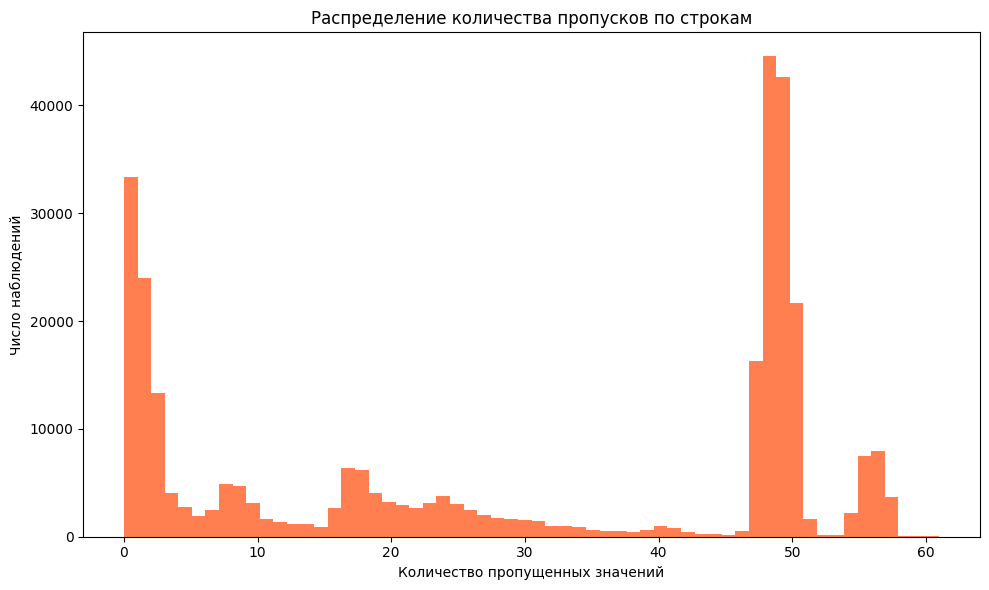

In [ ]:
# распределение null значений в разрезе заявок
to_study = add_row_null_counts(app_train)

ax = to_study.hist(
    column="null_count",
    bins=60,
    grid=False,
    figsize=(10, 6),
    color="coral"
)
plt.title("Распределение количества пропусков по строкам")
plt.xlabel("Количество пропущенных значений")
plt.ylabel("Число наблюдений")

plt.tight_layout()
plt.show()

По пропущенным значениям замечаем, что имеет место воронка формирования кредитных заявок. Гипотеза подтверждается, если мы посмотрим на распределение пустых значений в разрезе заявок. К сожалению у меня не получилось выявить какую-то закономерность этой воронки.

Сразу видим, что такие признаки как DAYS_LAST_PHONE_CHANGE, CNT_FAM_MEMBERS, AMT_ANNUITY, AMT_GOODS_PRICE, EXT_SOURCE_2 могут иметь null значения из-за технических ошибок. Поэтому для их заполнения можно воспользоваться средним/медианным значением признака.

Что касается остальных признаков, то здесь необходимо четкое разделение на числовые и категориальные. В случае числовых я предлагаю оставить как есть для деревянных алгоритмов, либо заполнить признак спец значением (не использовать в линейных моделях). Предлагаю не использовать линейные модели на таких признаках, так как и в случае заполнения признака, и в случае отбрасывания пустых наблюдений, мы будем вносить искажения.

Остановимся отдельно на категориальных признаках.

In [ ]:
metadata.loc[metadata.dtype == "object"].sort_values(by="null_pct")

,dtype,non_null_count,null_count,null_pct,unique_count,unique_pct,min,max,mean,std
NAME_CONTRACT_TYPE,object,307511,0,0.00,2,0.00,NaN,NaN,NaN,NaN
CODE_GENDER,object,307511,0,0.00,3,0.00,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,object,307511,0,0.00,2,0.00,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,object,307511,0,0.00,2,0.00,NaN,NaN,NaN,NaN
NAME_INCOME_TYPE,object,307511,0,0.00,8,0.00,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,object,307511,0,0.00,5,0.00,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,object,307511,0,0.00,6,0.00,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,object,307511,0,0.00,6,0.00,NaN,NaN,NaN,NaN
ORGANIZATION_TYPE,object,307511,0,0.00,58,0.02,NaN,NaN,NaN,NaN
WEEKDAY_APPR_PROCESS_START,object,307511,0,0.00,7,0.00,NaN,NaN,NaN,NaN


In [ ]:
metadata.loc[(metadata.unique_count == 2)].sort_values(by="null_pct")

,dtype,non_null_count,null_count,null_pct,unique_count,unique_pct,min,max,mean,std
NAME_CONTRACT_TYPE,object,307511,0,0.0,2,0.0,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,object,307511,0,0.0,2,0.0,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,object,307511,0,0.0,2,0.0,NaN,NaN,NaN,NaN
FLAG_MOBIL,int64,307511,0,0.0,2,0.0,0.0,1.0,0.999997,0.001803
FLAG_EMP_PHONE,int64,307511,0,0.0,2,0.0,0.0,1.0,0.819889,0.384280
FLAG_WORK_PHONE,int64,307511,0,0.0,2,0.0,0.0,1.0,0.199368,0.399526
FLAG_CONT_MOBILE,int64,307511,0,0.0,2,0.0,0.0,1.0,0.998133,0.043164
FLAG_PHONE,int64,307511,0,0.0,2,0.0,0.0,1.0,0.281066,0.449521
FLAG_EMAIL,int64,307511,0,0.0,2,0.0,0.0,1.0,0.056720,0.231307
REG_REGION_NOT_LIVE_REGION,int64,307511,0,0.0,2,0.0,0.0,1.0,0.015144,0.122126


In [ ]:
# Категория с 0.42% выбросов
app_train.groupby("NAME_TYPE_SUITE").size().sort_values(ascending=False)

,0
NAME_TYPE_SUITE,
Unaccompanied,248526
Family,40149
"Spouse, partner",11370
Children,3267
Other_B,1770
Other_A,866
Group of people,271


Обработка категориальных:
- NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG_OWN_REALTY - спокойно сводятся к бинарным переменным
- NAME_TYPE_SUITE - имеет 0.42% выбросов, можем просто заменить популярным классом
- Видим, что по остальным доля пропусков значительна, заменяем их на специальный класс "NaN"

In [ ]:
COLUMNS_TO_EXCLUDE = ["SK_ID_CURR", "TARGET"]

OBJECT_CAT_FEATURES = [
    'CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
]

BINARY_OBJ_FEATURES = ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

BINARY_INT_FEATURES = [
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
    'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'
]

CAT_FEATURES = list(
    set(OBJECT_CAT_FEATURES).union(
        BINARY_OBJ_FEATURES,
        BINARY_INT_FEATURES
    )
)

SPECIAL_CAT_FEATURE_TRANSFORM = [('NAME_TYPE_SUITE', 'Unaccompanied')]

Анализ таргета

In [ ]:
# Анализ таргета
(
    app_train
    .groupby("TARGET")
    .size()
    .rename("counts")
    .reset_index()
    .assign(
        ratio = lambda x: 100 * x["counts"] / x["counts"].sum(),
        entropy = lambda x: (-1) * (x["ratio"] / 100) * np.log2(x["ratio"] / 100)
    )
    .round(2)
)

,TARGET,counts,ratio,entropy
0,0,282686,91.93,0.11
1,1,24825,8.07,0.29


Наблюдаем дисбаланс классов в приблизительном соотношении 1:10. Можно использовать ROC-AUC для оценки качества.    
При обучении необходимо учитывать этот дисбаланс.

Теперь проведем univariate EDA.

In [ ]:
# Анализ взаимосвязи с числовыми признаками
app_train_tr = add_row_null_counts(app_train)
scores = []

for col in [item for item in app_train_tr.columns if not item in CAT_FEATURES + COLUMNS_TO_EXCLUDE]:
  tmp_df = app_train_tr[["TARGET", col]].dropna()
  left, right = tmp_df.loc[tmp_df["TARGET"] == 0, col].values, tmp_df.loc[tmp_df["TARGET"] == 1, col].values
  res = ks_2samp(left, right)
  scores.append((col, res.statistic, res.pvalue))

scores = (
    pd.DataFrame(scores, columns=["column", "ks_stat", "p_values"])
    .sort_values(by="ks_stat", ascending=False)
    .reset_index(drop=True)
)

print(scores.to_string())

                          column   ks_stat       p_values
0                   EXT_SOURCE_3  0.269812   0.000000e+00
1                   EXT_SOURCE_1  0.242696   0.000000e+00
2                   EXT_SOURCE_2  0.223739   0.000000e+00
3                     DAYS_BIRTH  0.121874  7.355860e-296
4                    OWN_CAR_AGE  0.102979   2.473246e-65
5         DAYS_LAST_PHONE_CHANGE  0.096801  1.399886e-186
6                AMT_GOODS_PRICE  0.094239  1.095322e-176
7                  DAYS_EMPLOYED  0.086583  2.690520e-149
8                DAYS_ID_PUBLISH  0.085212  1.306909e-144
9                     null_count  0.079296  2.916496e-125
10                 FLOORSMAX_AVG  0.072471   3.624307e-46
11                 ELEVATORS_AVG  0.072138   3.392926e-42
12                FLOORSMAX_MEDI  0.071479   6.365108e-45
13                ELEVATORS_MEDI  0.071435   2.196778e-41
14                    AMT_CREDIT  0.069468   3.316027e-96
15                FLOORSMAX_MODE  0.068798   1.208145e-41
16            

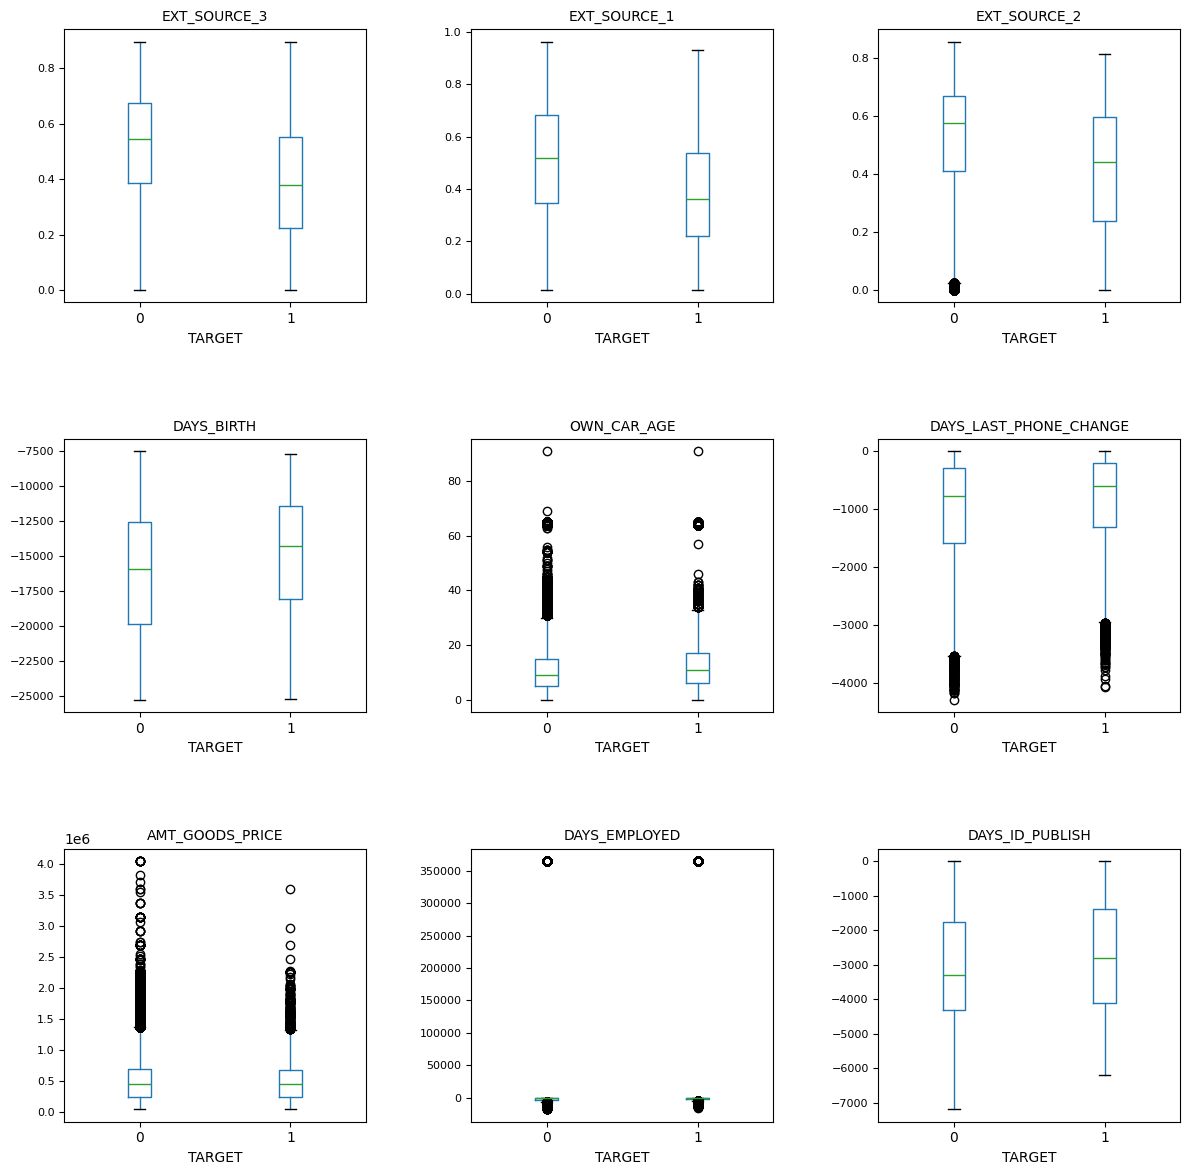

In [ ]:
# Посмотрим на распределение топ-9 фичей
candidates = scores["column"].tolist()[:9]

fig, axs = plt.subplots(3, 3, figsize=(12, 12))

for it, col in enumerate(candidates):
    ax = axs[it // 3, it % 3]

    app_train_tr.boxplot(
        column=col,
        by="TARGET",
        ax=ax,
        grid=False
    )

    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("")
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.35)

plt.show()

Для признака DAYS_EMPLOYED есть экстремально большие выбросы около 350000, очевидно это некая аномалия, а не реальный стаж клиента. В дальнейшем с этой аномалией нужно поработать, например добавить новый признак - индикатор наличия аномалии.     

Пока ограничим ось, чтобы посмотреть как устроено распределение этого признака для разных классов таргета.

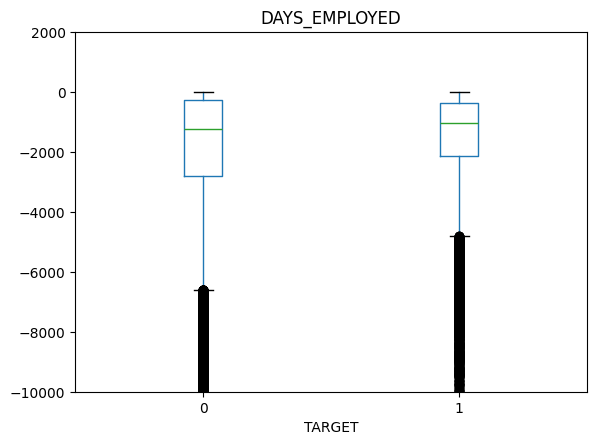

In [ ]:
app_train_tr.boxplot(column="DAYS_EMPLOYED", by="TARGET", grid=False)
plt.suptitle("")
plt.ylim(-10000, 2000)
plt.show()

In [ ]:
# Анализ взаимосвязи с категориальными признаками
transform_special = {
    item[0]: (lambda x, col=item[0], value=item[1]: x[col].fillna(value))
    for item in SPECIAL_CAT_FEATURE_TRANSFORM
}

transform = {
    item: (lambda x, col=item: x[col].fillna("NaN").astype(str))
    for item in OBJECT_CAT_FEATURES
}

app_train_tr = (
    app_train
    .assign(**transform_special)
    .assign(**transform)
)

nmi_df = compute_nmi(app_train_tr, "TARGET", CAT_FEATURES)

nmi_df.sort_values(ascending=False)

,0
NAME_EDUCATION_TYPE,2.395227e-03
CODE_GENDER,2.180798e-03
REG_CITY_NOT_LIVE_CITY,2.180704e-03
FLAG_EMP_PHONE,2.135670e-03
REG_CITY_NOT_WORK_CITY,2.072354e-03
NAME_INCOME_TYPE,2.008677e-03
OCCUPATION_TYPE,1.736750e-03
FLAG_DOCUMENT_3,1.620727e-03
NAME_CONTRACT_TYPE,1.229166e-03
EMERGENCYSTATE_MODE,1.220378e-03


In [ ]:
COL_TO_STUDY = "NAME_EDUCATION_TYPE"

test = (
    app_train_tr
    .groupby(["TARGET", COL_TO_STUDY])
    .size()
    .rename("counts")
    .reset_index()
    .merge(app_train_tr.groupby(COL_TO_STUDY).size().rename("feat_counts").reset_index(), on=COL_TO_STUDY)
    .assign(
        ratio=lambda x: x["counts"] / x["feat_counts"]
    )
    .pivot(index=COL_TO_STUDY, columns="TARGET", values="ratio")
    .join(app_train_tr.groupby(COL_TO_STUDY).size().rename("counts"))
)

test.sort_values(by=0)

,0,1,counts
NAME_EDUCATION_TYPE,,,
Lower secondary,0.890723,0.109277,3816
Secondary / secondary special,0.910601,0.089399,218391
Incomplete higher,0.915150,0.084850,10277
Higher education,0.946449,0.053551,74863
Academic degree,0.981707,0.018293,164


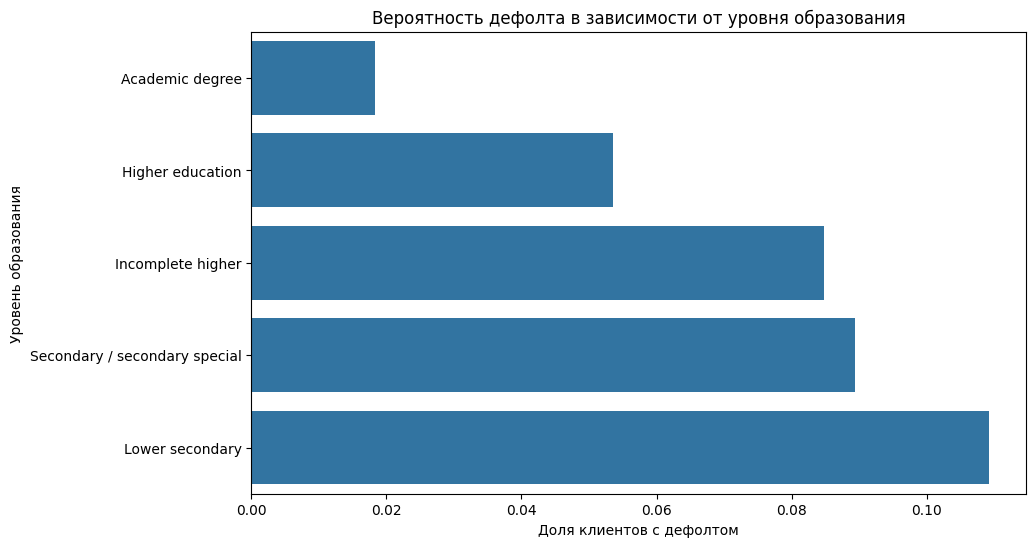

In [ ]:
# визуализация вероятности дефолта от уровня образования
edu_target = (
    app_train
    .groupby('NAME_EDUCATION_TYPE')['TARGET']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=edu_target.values,
    y=edu_target.index
)

plt.title('Вероятность дефолта в зависимости от уровня образования')
plt.xlabel('Доля клиентов с дефолтом')
plt.ylabel('Уровень образования')

plt.show()

Видим, что чем выше уровень образования, тем ниже вероятность дефолта

In [ ]:
COL_TO_STUDY = "CODE_GENDER"

test = (
    app_train_tr
    .groupby(["TARGET", COL_TO_STUDY])
    .size()
    .rename("counts")
    .reset_index()
    .merge(app_train_tr.groupby(COL_TO_STUDY).size().rename("feat_counts").reset_index(), on=COL_TO_STUDY)
    .assign(
        ratio=lambda x: x["counts"] / x["feat_counts"]
    )
    .pivot(index=COL_TO_STUDY, columns="TARGET", values="ratio")
    .join(app_train_tr.groupby(COL_TO_STUDY).size().rename("counts"))
)

test.sort_values(by=0)

,0,1,counts
CODE_GENDER,,,
M,0.898581,0.101419,105059
F,0.930007,0.069993,202448
XNA,1.000000,NaN,4


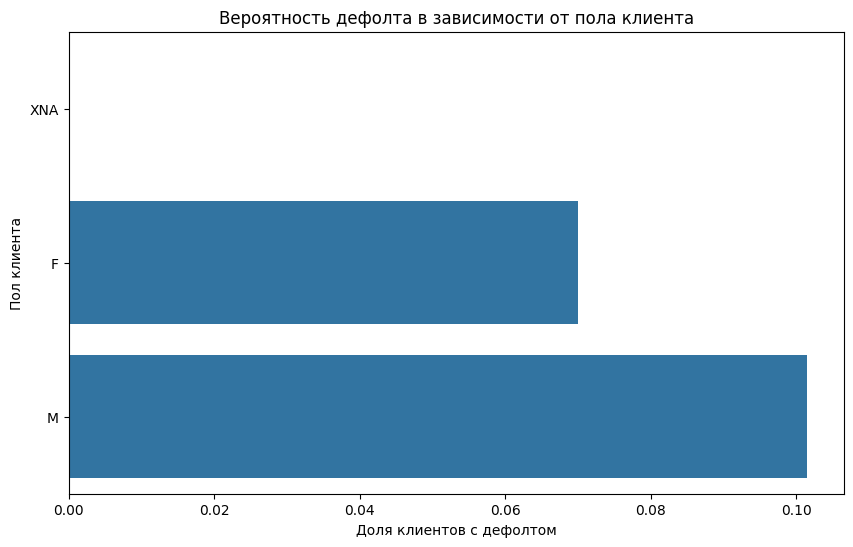

In [ ]:
# визуализация вероятности дефолта в зависимости от пола клиента
edu_target = (
    app_train
    .groupby('CODE_GENDER')['TARGET']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=edu_target.values,
    y=edu_target.index
)

plt.title('Вероятность дефолта в зависимости от пола клиента')
plt.xlabel('Доля клиентов с дефолтом')
plt.ylabel('Пол клиента')

plt.show()

Видим, что вероятность дефолта выше у мужчин

In [ ]:
COL_TO_STUDY = "REG_CITY_NOT_LIVE_CITY"

test = (
    app_train_tr
    .groupby(["TARGET", COL_TO_STUDY])
    .size()
    .rename("counts")
    .reset_index()
    .merge(app_train_tr.groupby(COL_TO_STUDY).size().rename("feat_counts").reset_index(), on=COL_TO_STUDY)
    .assign(
        ratio=lambda x: x["counts"] / x["feat_counts"]
    )
    .pivot(index=COL_TO_STUDY, columns="TARGET", values="ratio")
    .join(app_train_tr.groupby(COL_TO_STUDY).size().rename("counts"))
)

test.sort_values(by=0)

,0,1,counts
REG_CITY_NOT_LIVE_CITY,,,
1,0.877740,0.122260,24039
0,0.922793,0.077207,283472


Обучим бейзлайн

In [ ]:
fillna_special = {
    item[0]: (lambda x, col=item[0], value=item[1]: x[col].fillna(value))
    for item in SPECIAL_CAT_FEATURE_TRANSFORM
}

fillna_cat = {
    item: (lambda x, col=item: x[col].fillna("NaN").astype(str))
    for item in OBJECT_CAT_FEATURES
}

# Label Encoding
transform_cat = {
    item: (lambda x, col=item: x[col].astype("category").cat.codes)  # Fixed
    for item in OBJECT_CAT_FEATURES + BINARY_OBJ_FEATURES
}

app_train_tr = add_row_null_counts(app_train)

for col, func in fillna_special.items():
    app_train_tr[col] = func(app_train_tr)

for col, func in fillna_cat.items():
    app_train_tr[col] = func(app_train_tr)

for col, func in transform_cat.items():
    app_train_tr[col] = func(app_train_tr)

numeric_cols = [col for col in app_train.columns
                if col not in OBJECT_CAT_FEATURES + BINARY_OBJ_FEATURES
                and col not in [item[0] for item in SPECIAL_CAT_FEATURE_TRANSFORM]]

for col in numeric_cols:
    app_train_tr[col] = app_train_tr[col].fillna(-1000)

app_train_tr.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,null_count
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,48
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,-1000.0,56
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,50


In [ ]:
train, test = train_test_split(app_train_tr, test_size=0.33, random_state=42)

In [ ]:
X_train, X_test = (
    train.drop(['TARGET', 'SK_ID_CURR'], axis=1),
    test.drop(['TARGET', 'SK_ID_CURR'], axis=1)
)
y_train, y_test = (
    train['TARGET'],
    test['TARGET']
)

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5, n_jobs=-1,
                       random_state=42)

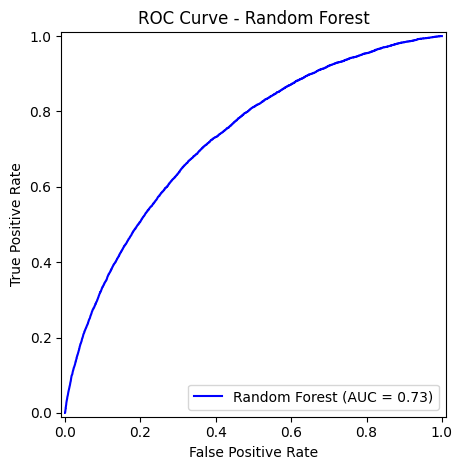

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf_balanced,
    X_test,
    y_test,
    name="Random Forest",
    color="blue"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid(False)
plt.tight_layout()
plt.show()

ROC-AUC = 0.73 неплохой результат для Random Forest, существенно лучше чем случайный классификатор.      
Используем данную модель как бейзлайн, далее попробуем улучшить метрику качества за счет работы с признаками.

In [ ]:
feature_importance = rf_balanced.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df.to_string())

Feature Importance:
                          feature    importance
41                   EXT_SOURCE_3  1.784502e-01
40                   EXT_SOURCE_2  1.630507e-01
39                   EXT_SOURCE_1  5.698781e-02
15                     DAYS_BIRTH  3.828068e-02
16                  DAYS_EMPLOYED  3.808210e-02
8                 AMT_GOODS_PRICE  2.682051e-02
93         DAYS_LAST_PHONE_CHANGE  2.567863e-02
18                DAYS_ID_PUBLISH  2.211461e-02
6                      AMT_CREDIT  2.201929e-02
11            NAME_EDUCATION_TYPE  2.027742e-02
7                     AMT_ANNUITY  1.878827e-02
17              DAYS_REGISTRATION  1.606243e-02
1                     CODE_GENDER  1.529259e-02
10               NAME_INCOME_TYPE  1.473208e-02
38              ORGANIZATION_TYPE  1.263719e-02
14     REGION_POPULATION_RELATIVE  1.187063e-02
5                AMT_INCOME_TOTAL  9.389830e-03
86                 TOTALAREA_MODE  9.054101e-03
29    REGION_RATING_CLIENT_W_CITY  8.772210e-03
42                 A

### Шаг 5. результат этапа 1
- [x] есть описание датасета
- [x] задача проекта сформулирована простыми словами
- [x] проведён eda
- [x] построен baseline


## Этап 2. работа с аномалиями и генерация признаков

### Шаг 1. найти и проанализировать аномалии
- [x] примените z оценку, межквартильный размах и тест граббса
- [x] визуализируйте найденные выбросы
- [x] объясните, почему эти точки можно считать аномалиями
- [x] решите, что делать с аномалиями и обоснуйте выбор

In [ ]:
# общий кешер для тяжелых параграфов

import os
import json
import hashlib
import joblib

if os.path.exists("/content/drive/MyDrive"):
    PROJECT_CACHE_DIR = "/content/drive/MyDrive/home_credit_project_cache"
else:
    PROJECT_CACHE_DIR = "/content/home_credit_project_cache"

os.makedirs(PROJECT_CACHE_DIR, exist_ok=True)

def project_cache_path(*parts):
    path = os.path.join(PROJECT_CACHE_DIR, *parts[:-1])
    os.makedirs(path, exist_ok=True)
    return os.path.join(PROJECT_CACHE_DIR, *parts)

def project_signature(payload, n_chars=12):
    payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=str)
    return hashlib.md5(payload_str.encode("utf-8")).hexdigest()[:n_chars]

def load_or_build_cache(cache_path, builder_func, force=False):
    if os.path.exists(cache_path) and not force:
        print(f"Loaded from cache: {cache_path}")
        return joblib.load(cache_path)

    print(f"Cache not found. Building: {cache_path}")
    result = builder_func()
    joblib.dump(result, cache_path)
    print(f"Saved to cache: {cache_path}")
    return result

,zscore_outliers,iqr_outliers,grubbs_outliers
REGION_RATING_CLIENT__iqr_outlier,NaN,80527.0,NaN
REGION_RATING_CLIENT_W_CITY__iqr_outlier,NaN,78027.0,NaN
DAYS_EMPLOYED__iqr_outlier,NaN,72217.0,NaN
AMT_REQ_CREDIT_BUREAU_QRT__iqr_outlier,NaN,50575.0,NaN
AMT_REQ_CREDIT_BUREAU_MON__iqr_outlier,NaN,43759.0,NaN
DEF_30_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,35166.0,NaN
DEF_60_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,25769.0,NaN
OBS_30_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,19971.0,NaN
OBS_60_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,19564.0,NaN
NONLIVINGAREA_MODE__iqr_outlier,NaN,18817.0,NaN


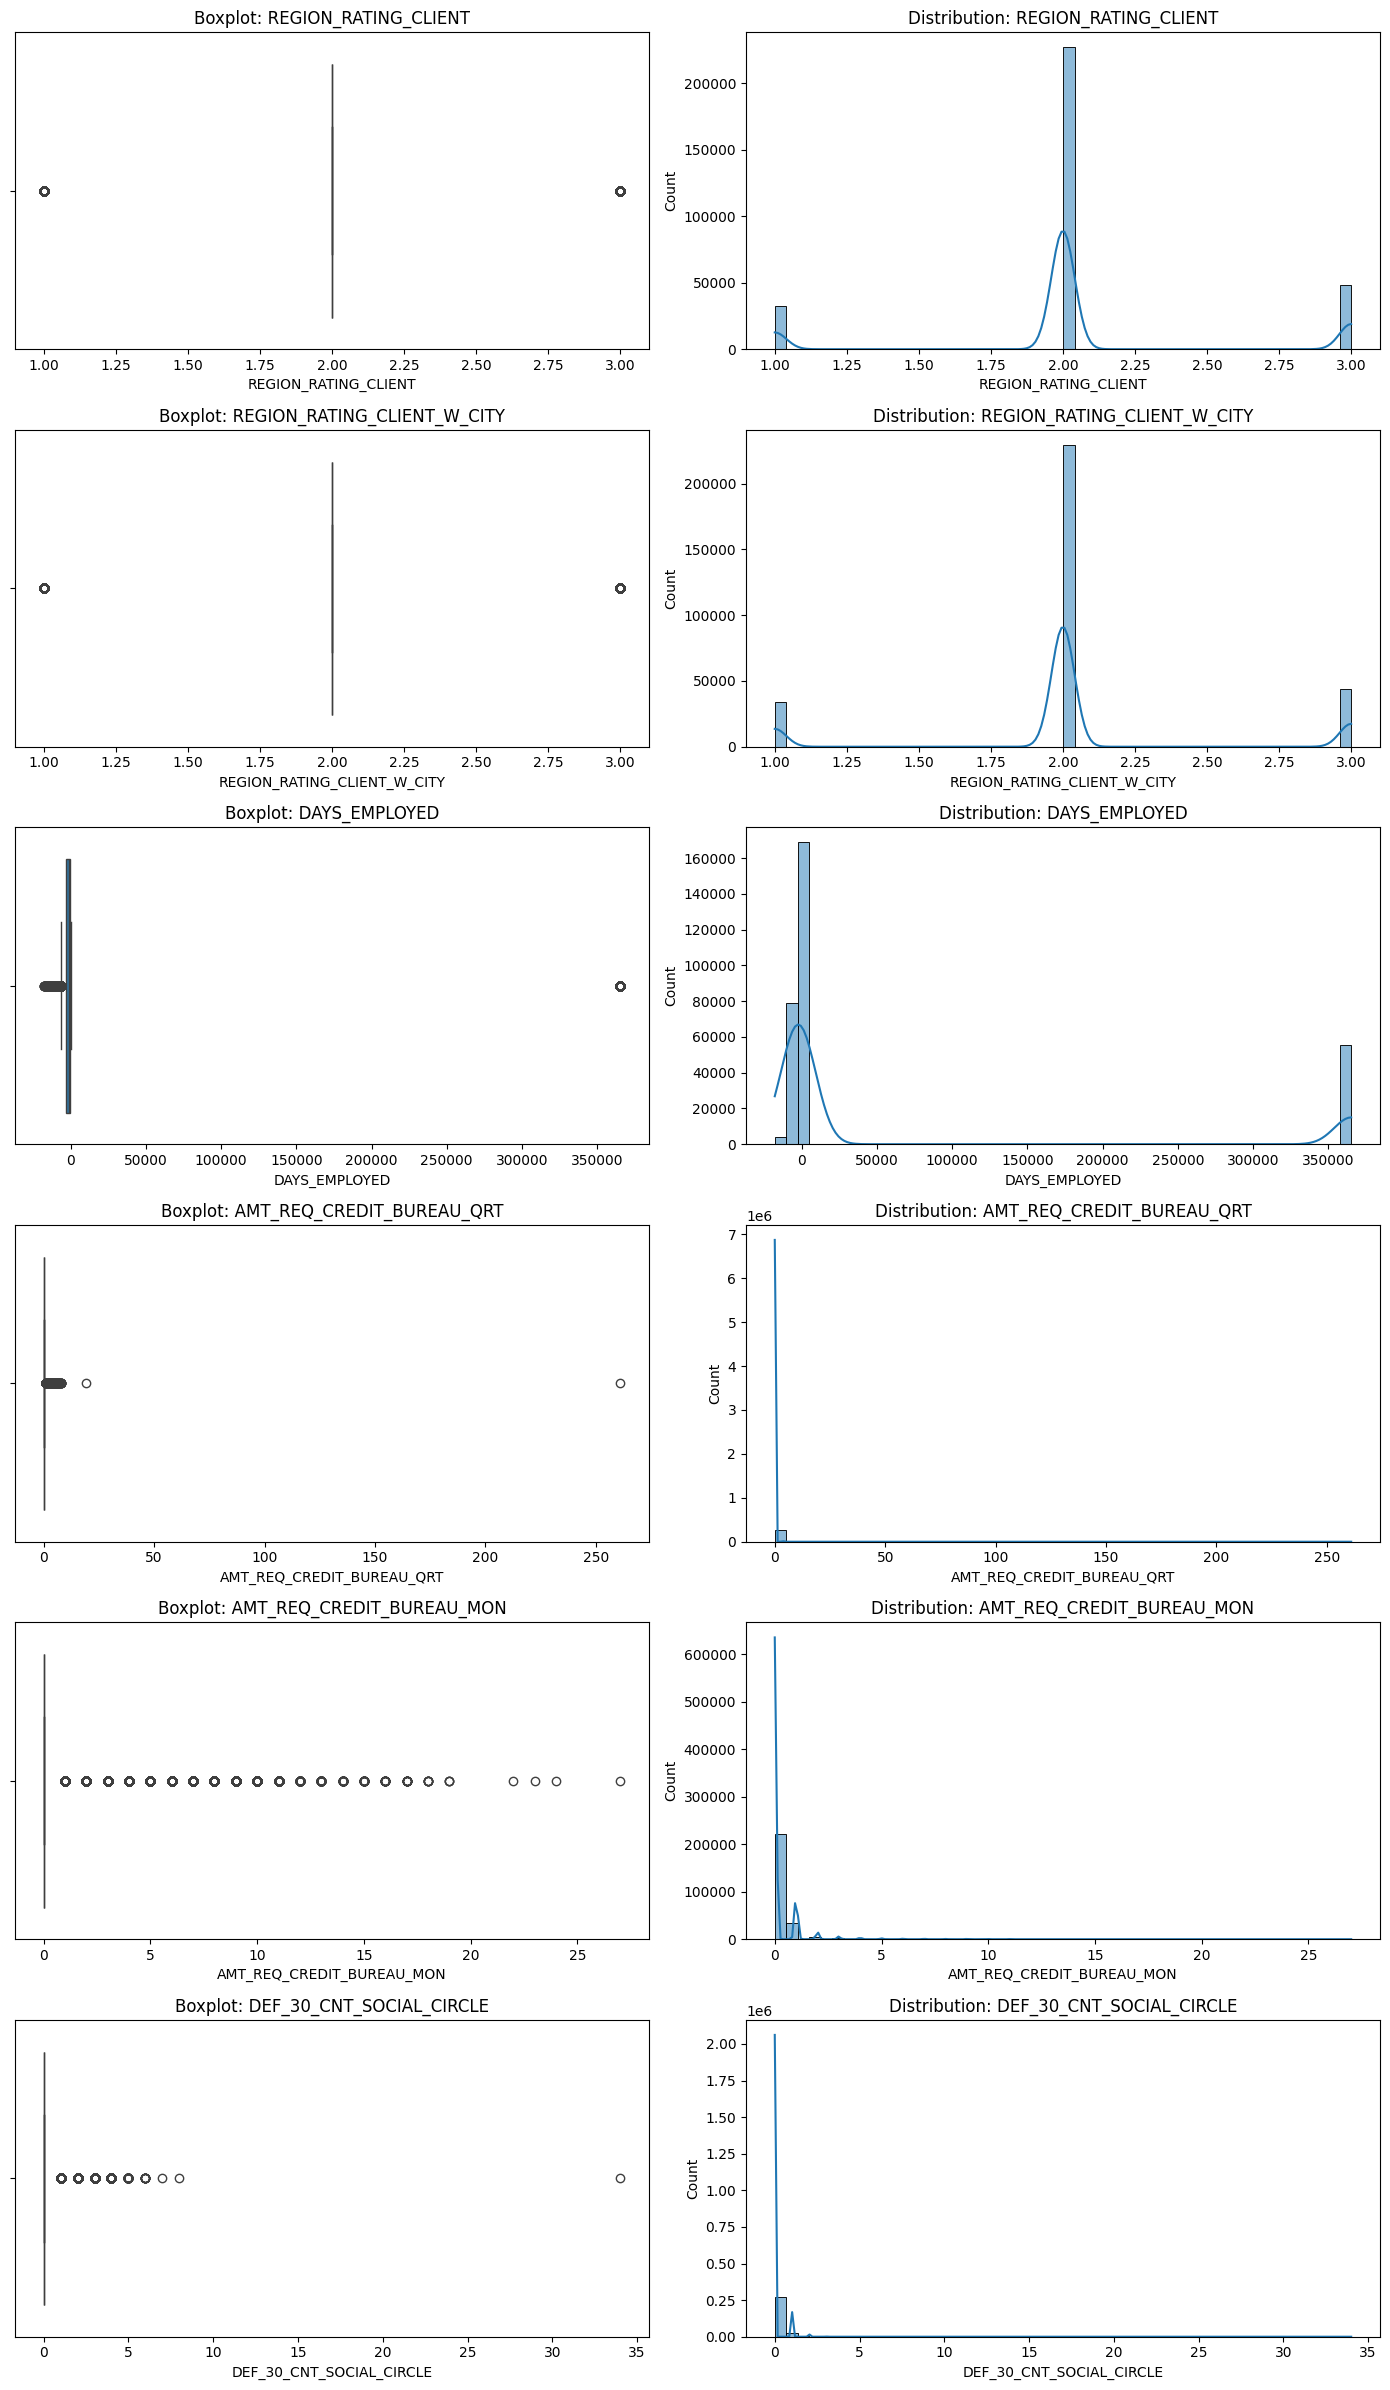

,group,count,target_rate
0,normal,72250,0.092318
1,anomalous,235261,0.077170


Baseline ROC-AUC: 0.74598 ± 0.00254

Вывод
Аномалии не удаляем жёстко, а превращаем в признаки: для кредитного скоринга экстремальные значения часто несут полезный сигнал риска.


In [ ]:
# @title
# - место под список числовых признаков для анализа аномалий
# - место под код для z score
# - место под код для iqr
# - место под код для теста граббса
# - место под boxplot и распределения
# - место под сравнение target у аномальных и обычных наблюдений
# - место под выводы по обработке аномалий

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import t
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

stage2_train = app_train.copy()
stage2_test = app_test.copy()

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

def quick_auc_cv(df, target_col=TARGET_COL, drop_cols=None):
    drop_cols = drop_cols or []
    work = df.copy()
    y = work[target_col]
    X = work.drop(columns=[target_col] + [c for c in drop_cols if c in work.columns], errors="ignore")

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ]
    )

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean(), scores.std()

def grubbs_test_mask(series, alpha=0.05):
    s = series.dropna().astype(float)
    n = len(s)
    if n < 7:
        return pd.Series(False, index=series.index)

    mean_ = s.mean()
    std_ = s.std(ddof=1)
    if std_ == 0 or pd.isna(std_):
        return pd.Series(False, index=series.index)

    G = ((s - mean_).abs() / std_)
    t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
    G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

    flagged_idx = G[G > G_crit].index
    mask = pd.Series(False, index=series.index)
    mask.loc[flagged_idx] = True
    return mask

numeric_cols = [
    c for c in stage2_train.select_dtypes(include=[np.number]).columns
    if c not in [TARGET_COL, ID_COL]
]

# исключим технические бинарные поля
numeric_cols = [c for c in numeric_cols if stage2_train[c].nunique(dropna=True) > 2]

zscore_flags = pd.DataFrame(index=stage2_train.index)
iqr_flags = pd.DataFrame(index=stage2_train.index)
grubbs_flags = pd.DataFrame(index=stage2_train.index)

for col in numeric_cols:
    s = stage2_train[col]

    z = np.abs(stats.zscore(s.fillna(s.median()), nan_policy="omit"))
    zscore_flags[f"{col}__z_outlier"] = z > 3

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_flags[f"{col}__iqr_outlier"] = (s < lower) | (s > upper)

    grubbs_flags[f"{col}__grubbs_outlier"] = grubbs_test_mask(s)

anomaly_summary = pd.DataFrame({
    "zscore_outliers": zscore_flags.sum(),
    "iqr_outliers": iqr_flags.sum(),
    "grubbs_outliers": grubbs_flags.sum()
}).sort_values(by=["iqr_outliers", "zscore_outliers"], ascending=False)

display(anomaly_summary.head(20))

top_outlier_cols = (
    anomaly_summary.head(6).index
    .str.replace(r"__(z|iqr|grubbs)_outlier$", "", regex=True)
    .tolist()
)

top_outlier_cols = [c for c in top_outlier_cols if c in stage2_train.columns]

if len(top_outlier_cols) > 0:
    fig, axes = plt.subplots(len(top_outlier_cols), 2, figsize=(14, 4 * len(top_outlier_cols)))

    if len(top_outlier_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(top_outlier_cols):
        sns.boxplot(x=stage2_train[col], ax=axes[i, 0])
        axes[i, 0].set_title(f"Boxplot: {col}")

        sns.histplot(stage2_train[col], bins=50, kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f"Distribution: {col}")

    plt.tight_layout()
    plt.show()
else:
    print("Не удалось найти признаки для визуализации аномалий")

row_anomaly_mask = (
    zscore_flags.any(axis=1)
    | iqr_flags.any(axis=1)
    | grubbs_flags.any(axis=1)
)

target_compare = pd.DataFrame({
    "group": ["normal", "anomalous"],
    "count": [
        (~row_anomaly_mask).sum(),
        row_anomaly_mask.sum()
    ],
    "target_rate": [
        stage2_train.loc[~row_anomaly_mask, TARGET_COL].mean(),
        stage2_train.loc[row_anomaly_mask, TARGET_COL].mean()
    ]
})

display(target_compare)

baseline_mean, baseline_std = quick_auc_cv(stage2_train, drop_cols=[ID_COL])
print(f"Baseline ROC-AUC: {baseline_mean:.5f} ± {baseline_std:.5f}")

print("\nВывод")
print("Аномалии не удаляем жёстко, а превращаем в признаки: для кредитного скоринга экстремальные значения часто несут полезный сигнал риска.")

=== DAYS_EMPLOYED_ANOM ===
                     count  target_rate
DAYS_EMPLOYED_ANOM                     
0                   252137     0.086600
1                    55374     0.053996

Число числовых признаков для анализа аномалий: 72

=== Топ-20 признаков по числу аномалий ===


,zscore_outliers,iqr_outliers,grubbs_outliers
REGION_RATING_CLIENT__iqr_outlier,NaN,80527.0,NaN
REGION_RATING_CLIENT_W_CITY__iqr_outlier,NaN,78027.0,NaN
AMT_REQ_CREDIT_BUREAU_QRT__iqr_outlier,NaN,50575.0,NaN
AMT_REQ_CREDIT_BUREAU_MON__iqr_outlier,NaN,43759.0,NaN
DEF_30_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,35166.0,NaN
DEF_60_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,25769.0,NaN
OBS_30_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,19971.0,NaN
OBS_60_CNT_SOCIAL_CIRCLE__iqr_outlier,NaN,19564.0,NaN
NONLIVINGAREA_MODE__iqr_outlier,NaN,18817.0,NaN
NONLIVINGAREA_MEDI__iqr_outlier,NaN,17254.0,NaN


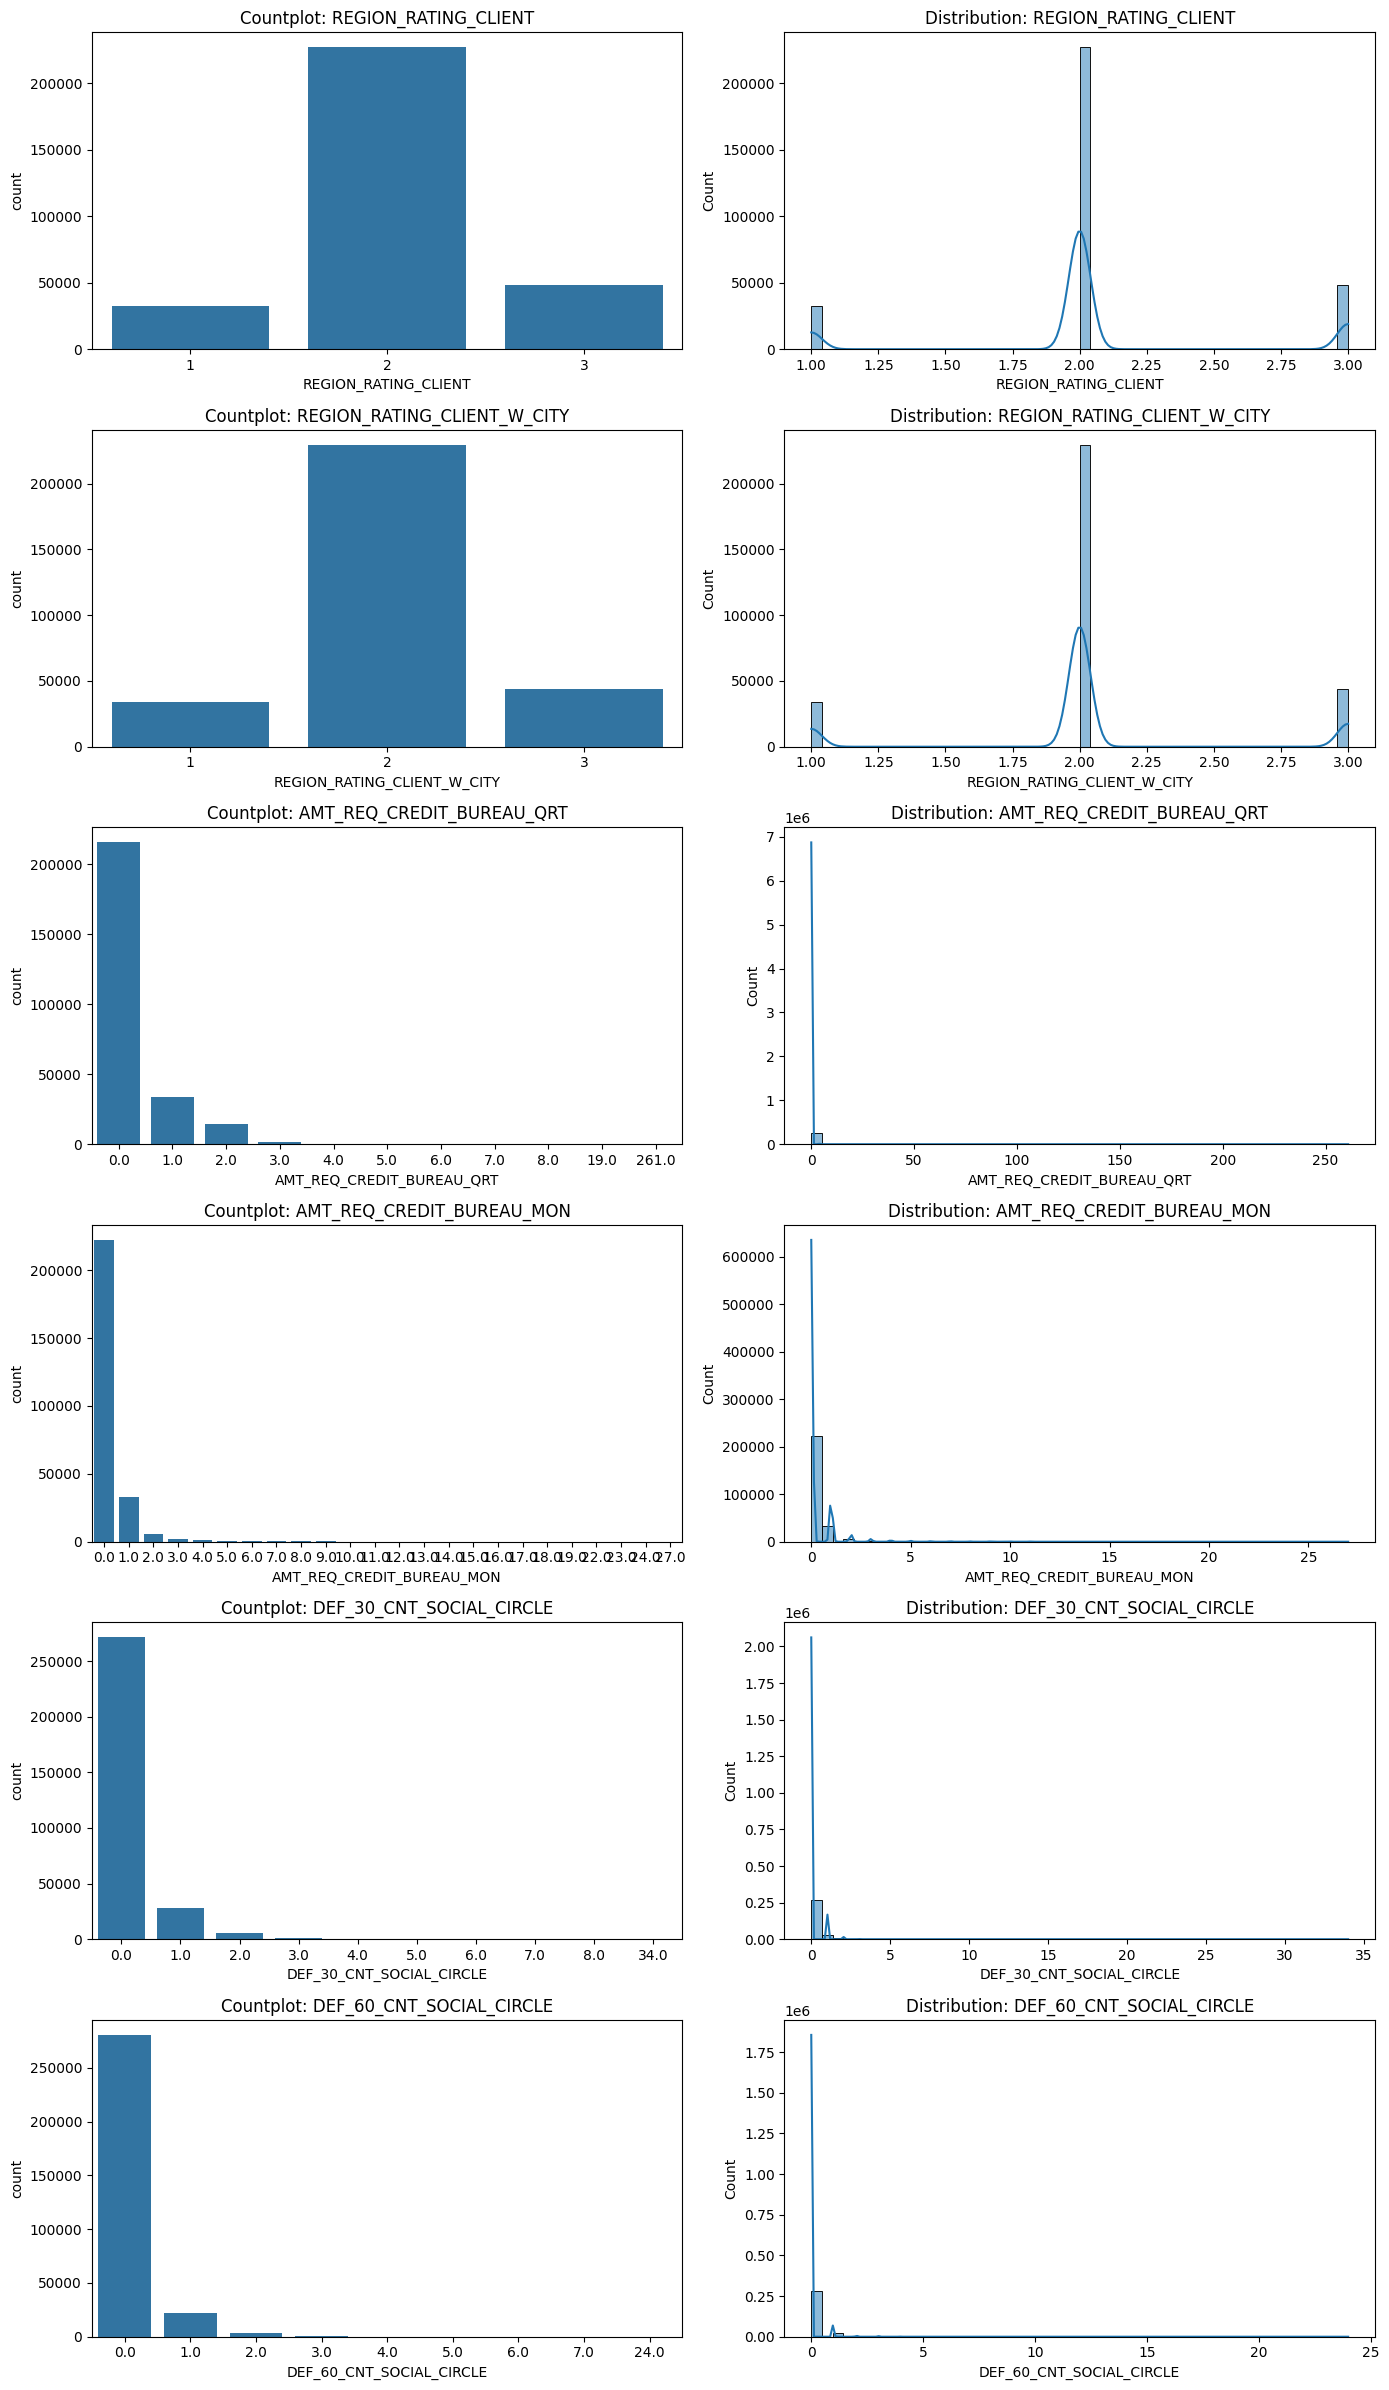


=== Сравнение TARGET: обычные vs аномальные ===


,group,count,target_rate
0,normal,92772,0.085468
1,anomalous,214739,0.078682



Baseline ROC-AUC: 0.74617 ± 0.00281

=== ВЫВОД ПО АНАЛИЗУ АНОМАЛИЙ ===

1. Масштаб:
   214,739 наблюдений (69.8%) содержат хотя бы один выброс
   по одному из трёх методов (z-score, IQR, Граббс).

2. Доменная аномалия — DAYS_EMPLOYED = 365243:
   55,374 строк содержат это значение-заглушку, означающее
   «нет официального трудоустройства». Оно вынесено в бинарный признак
   DAYS_EMPLOYED_ANOM, а оригинальная колонка заменена на NaN.
   Target rate у этой группы: 0.054
   против 0.087 у работающих.

3. Сравнение TARGET:
   - Обычные наблюдения:   target rate = 0.085
   - Аномальные наблюдения: target rate = 0.079
   Разница незначительна —
   выбросы несут слабый сигнал.

4. Решение — аномалии НЕ удаляем:
   В кредитном скоринге экстремальные значения (сверхвысокий доход,
   нулевой стаж, аномальные запросы в бюро) — это реальные факторы риска,
   а не шум. Удаление таких наблюдений привело бы к потере важного сигнала
   и ухудшению качества модели. Вместо этого:
   - для DAYS_EMPLOYED

In [ ]:
# =============================================================================
# ЭТАП 2. РАБОТА С АНОМАЛИЯМИ
# =============================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import t
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# =============================================================================
# 0. КОПИИ ДАТАФРЕЙМОВ
# =============================================================================

stage2_train = app_train.copy()
stage2_test  = app_test.copy()

TARGET_COL = "TARGET"
ID_COL     = "SK_ID_CURR"

# =============================================================================
# 1. ДОМЕННАЯ АНОМАЛИЯ: DAYS_EMPLOYED = 365243
#    Это артефакт данных: значение 365243 кодирует «безработный / нет стажа».
#    Обычные статистические методы не могут поймать её корректно,
#    поэтому обрабатываем явно ДО общего анализа.
# =============================================================================

DAYS_EMPLOYED_PLACEHOLDER = 365243

for df in [stage2_train, stage2_test]:
    df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_PLACEHOLDER).astype(int)
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(DAYS_EMPLOYED_PLACEHOLDER, np.nan)

# Смотрим, как флаг коррелирует с TARGET
anom_rate = stage2_train.groupby("DAYS_EMPLOYED_ANOM")[TARGET_COL].mean()
anom_cnt  = stage2_train["DAYS_EMPLOYED_ANOM"].value_counts()
print("=== DAYS_EMPLOYED_ANOM ===")
print(pd.DataFrame({"count": anom_cnt, "target_rate": anom_rate}))

# =============================================================================
# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =============================================================================

def quick_auc_cv(df, target_col=TARGET_COL, drop_cols=None):
    """Быстрый baseline ROC-AUC через 3-fold CV + LogisticRegression."""
    drop_cols = drop_cols or []
    work = df.copy()
    y = work[target_col]
    X = work.drop(
        columns=[target_col] + [c for c in drop_cols if c in work.columns],
        errors="ignore"
    )

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe",     OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("clf",  LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean(), scores.std()


def grubbs_test_mask(series, alpha=0.05, max_n=5000):
    """
    Тест Граббса — предназначен для малых выборок (n < ~50).
    При n > max_n пропускаем: на больших данных тест теряет смысл
    и работает крайне медленно.
    """
    s = series.dropna().astype(float)
    n = len(s)
    if n < 7 or n > max_n:
        return pd.Series(False, index=series.index)

    std_ = s.std(ddof=1)
    if std_ == 0 or pd.isna(std_):
        return pd.Series(False, index=series.index)

    mean_  = s.mean()
    G      = (s - mean_).abs() / std_
    t_crit = t.ppf(1 - alpha / (2 * n), n - 2)
    G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

    mask = pd.Series(False, index=series.index)
    mask.loc[G[G > G_crit].index] = True
    return mask

# =============================================================================
# 3. СПИСОК ЧИСЛОВЫХ ПРИЗНАКОВ ДЛЯ АНАЛИЗА
#    Исключаем: TARGET, ID, бинарные признаки (nunique <= 2)
# =============================================================================

numeric_cols = [
    c for c in stage2_train.select_dtypes(include=[np.number]).columns
    if c not in [TARGET_COL, ID_COL]
    and stage2_train[c].nunique(dropna=True) > 2
]

print(f"\nЧисло числовых признаков для анализа аномалий: {len(numeric_cols)}")

# =============================================================================
# 4. Z-SCORE, IQR, ГРАББС
#    Важно: пороги IQR и z-score считаем ТОЛЬКО на train,
#    затем применяем к test с теми же значениями — иначе утечка данных.
# =============================================================================

zscore_flags_train = pd.DataFrame(index=stage2_train.index)
zscore_flags_test  = pd.DataFrame(index=stage2_test.index)

iqr_flags_train    = pd.DataFrame(index=stage2_train.index)
iqr_flags_test     = pd.DataFrame(index=stage2_test.index)

grubbs_flags_train = pd.DataFrame(index=stage2_train.index)

for col in numeric_cols:
    s_train = stage2_train[col]
    s_test  = stage2_test[col]

    # --- Z-score (nan_policy="omit" — не заполняем медианой, чтобы не сжимать std) ---
    z_vals = stats.zscore(s_train, nan_policy="omit")
    zscore_flags_train[f"{col}__z_outlier"] = pd.Series(
        np.where(s_train.isna(), False, np.abs(z_vals) > 3),
        index=s_train.index
    )

    train_mean = s_train.mean()
    train_std  = s_train.std(ddof=1)
    if train_std and train_std > 0:
        z_test = np.abs((s_test - train_mean) / train_std)
        zscore_flags_test[f"{col}__z_outlier"] = pd.Series(
            np.where(s_test.isna(), False, z_test > 3),
            index=s_test.index
        )
    else:
        zscore_flags_test[f"{col}__z_outlier"] = False

    # --- IQR (пороги с train) ---
    q1    = s_train.quantile(0.25)
    q3    = s_train.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_flags_train[f"{col}__iqr_outlier"] = (s_train < lower) | (s_train > upper)
    iqr_flags_test[f"{col}__iqr_outlier"]  = (s_test  < lower) | (s_test  > upper)

    # --- Граббс (только train, только малые колонки) ---
    grubbs_flags_train[f"{col}__grubbs_outlier"] = grubbs_test_mask(s_train)

# =============================================================================
# 5. СВОДНАЯ ТАБЛИЦА АНОМАЛИЙ
# =============================================================================

anomaly_summary = pd.DataFrame({
    "zscore_outliers":  zscore_flags_train.sum(),
    "iqr_outliers":     iqr_flags_train.sum(),
    "grubbs_outliers":  grubbs_flags_train.sum(),
}).sort_values(by=["iqr_outliers", "zscore_outliers"], ascending=False)

print("\n=== Топ-20 признаков по числу аномалий ===")
display(anomaly_summary.head(20))

# =============================================================================
# 6. ВИЗУАЛИЗАЦИЯ: РАСПРЕДЕЛЕНИЕ
# =============================================================================

# Берём топ-6 уникальных признаков (дедупликация через dict.fromkeys)
top_outlier_cols = list(dict.fromkeys(
    anomaly_summary.head(6).index
    .str.replace(r"__(z|iqr|grubbs)_outlier$", "", regex=True)
    .tolist()
))
top_outlier_cols = [c for c in top_outlier_cols if c in stage2_train.columns]

if top_outlier_cols:
    fig, axes = plt.subplots(
        len(top_outlier_cols), 2,
        figsize=(14, 4 * len(top_outlier_cols))
    )
    if len(top_outlier_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(top_outlier_cols):
        #sns.boxplot(x=stage2_train[col], ax=axes[i, 0])
        #axes[i, 0].set_title(f"Boxplot: {col}")

        sns.countplot(x=stage2_train[col], ax=axes[i, 0])
        axes[i, 0].set_title(f"Countplot: {col}")

        sns.histplot(stage2_train[col], bins=50, kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f"Distribution: {col}")

    plt.tight_layout()
    plt.show()
else:
    print("Не удалось найти признаки для визуализации аномалий")

# =============================================================================
# 7. СРАВНЕНИЕ TARGET: АНОМАЛЬНЫЕ VS ОБЫЧНЫЕ НАБЛЮДЕНИЯ
# =============================================================================

row_anomaly_mask = (
    zscore_flags_train.any(axis=1)
    | iqr_flags_train.any(axis=1)
    | grubbs_flags_train.any(axis=1)
)

target_compare = pd.DataFrame({
    "group":       ["normal",               "anomalous"],
    "count":       [(~row_anomaly_mask).sum(), row_anomaly_mask.sum()],
    "target_rate": [
        stage2_train.loc[~row_anomaly_mask, TARGET_COL].mean(),
        stage2_train.loc[ row_anomaly_mask, TARGET_COL].mean(),
    ],
})

print("\n=== Сравнение TARGET: обычные vs аномальные ===")
display(target_compare)

# =============================================================================
# 8. BASELINE ROC-AUC
# =============================================================================

baseline_mean, baseline_std = quick_auc_cv(stage2_train, drop_cols=[ID_COL])
print(f"\nBaseline ROC-AUC: {baseline_mean:.5f} ± {baseline_std:.5f}")

# =============================================================================
# 9. ВЫВОД
# =============================================================================

normal_rate   = stage2_train.loc[~row_anomaly_mask, TARGET_COL].mean()
anomalous_rate = stage2_train.loc[ row_anomaly_mask, TARGET_COL].mean()
n_anom        = row_anomaly_mask.sum()
pct_anom      = row_anomaly_mask.mean() * 100
n_days_anom   = stage2_train["DAYS_EMPLOYED_ANOM"].sum()

print(f"""
=== ВЫВОД ПО АНАЛИЗУ АНОМАЛИЙ ===

1. Масштаб:
   {n_anom:,} наблюдений ({pct_anom:.1f}%) содержат хотя бы один выброс
   по одному из трёх методов (z-score, IQR, Граббс).

2. Доменная аномалия — DAYS_EMPLOYED = 365243:
   {n_days_anom:,} строк содержат это значение-заглушку, означающее
   «нет официального трудоустройства». Оно вынесено в бинарный признак
   DAYS_EMPLOYED_ANOM, а оригинальная колонка заменена на NaN.
   Target rate у этой группы: {anom_rate.get(1, float('nan')):.3f}
   против {anom_rate.get(0, float('nan')):.3f} у работающих.

3. Сравнение TARGET:
   - Обычные наблюдения:   target rate = {normal_rate:.3f}
   - Аномальные наблюдения: target rate = {anomalous_rate:.3f}
   Разница {'значима' if abs(anomalous_rate - normal_rate) > 0.02 else 'незначительна'} —
   выбросы несут {'полезный сигнал риска' if anomalous_rate > normal_rate else 'слабый сигнал'}.

4. Решение — аномалии НЕ удаляем:
   В кредитном скоринге экстремальные значения (сверхвысокий доход,
   нулевой стаж, аномальные запросы в бюро) — это реальные факторы риска,
   а не шум. Удаление таких наблюдений привело бы к потере важного сигнала
   и ухудшению качества модели. Вместо этого:
   - для DAYS_EMPLOYED создан бинарный флаг (DAYS_EMPLOYED_ANOM)
""")

### Шаг 2. построить признаки на основе аномалий
- [x] добавьте в датасет флаги или счётчики аномалий
- [x] при желании рассчитайте расстояние до ближайших точек или плотность окружения
- [x] опишите, что несут новые признаки и как они могут помочь модели


In [ ]:
# @title
# =============================================================================
# ЭТАП 2. ШАГ 2. ПРИЗНАКИ НА ОСНОВЕ АНОМАЛИЙ
# =============================================================================
#
# Оптимизированная версия:
# 1. Первый запуск считает anomaly features, KNN distance/density и quick_auc_cv.
# 2. Результат сохраняется в кеш.
# 3. Последующие запуски просто подгружают готовые признаки и comparison.
#
# =============================================================================

from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import os
import json
import hashlib
import joblib
import numpy as np
import pandas as pd


# =============================================================================
# 0. КЕШ
# =============================================================================

if os.path.exists("/content/drive/MyDrive"):
    CACHE_DIR = "/content/drive/MyDrive/home_credit_project_cache/stage2"
else:
    CACHE_DIR = "/content/home_credit_project_cache/stage2"

os.makedirs(CACHE_DIR, exist_ok=True)

FORCE_REBUILD_STAGE2_2 = False

CACHE_VERSION_STAGE2_2 = "stage2_2_anomaly_knn_v2"


# =============================================================================
# 1. КОЛОНКИ ДЛЯ KNN
# =============================================================================

knn_base_cols = (
    pd.Series({c: stage2_train[c].notna().mean() for c in numeric_cols if c in stage2_train.columns})
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

print(f"\nКолонки для KNN ({len(knn_base_cols)}): {knn_base_cols}")


# =============================================================================
# 2. ХЕШ ДЛЯ КЕША
# =============================================================================

def make_stage2_2_signature():
    payload = {
        "cache_version": CACHE_VERSION_STAGE2_2,
        "train_rows": len(stage2_train),
        "test_rows": len(stage2_test),
        "target_mean": float(stage2_train[TARGET_COL].mean()),
        "numeric_cols": list(numeric_cols),
        "knn_base_cols": knn_base_cols,
        "knn_n_neighbors": 6,
        "baseline_mean": float(baseline_mean),
        "baseline_std": float(baseline_std),
    }

    if ID_COL in stage2_train.columns:
        payload["train_id_min"] = str(stage2_train[ID_COL].min())
        payload["train_id_max"] = str(stage2_train[ID_COL].max())

    if ID_COL in stage2_test.columns:
        payload["test_id_min"] = str(stage2_test[ID_COL].min())
        payload["test_id_max"] = str(stage2_test[ID_COL].max())

    payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload_str.encode("utf-8")).hexdigest()[:12]


stage2_2_signature = make_stage2_2_signature()

STAGE2_2_CACHE_PATH = os.path.join(
    CACHE_DIR,
    f"stage2_2_anomaly_knn_features_{stage2_2_signature}.joblib"
)

print(f"Stage 2.2 cache path: {STAGE2_2_CACHE_PATH}")


def load_or_build_stage2_2_cache(cache_path, builder_func, force=False):
    if os.path.exists(cache_path) and not force:
        print(f"Loaded from cache: {cache_path}")
        return joblib.load(cache_path)

    print("Cache not found. Building Stage 2.2 features...")
    result = builder_func()
    joblib.dump(result, cache_path)
    print(f"Saved to cache: {cache_path}")
    return result


# =============================================================================
# 3. ТЯЖЁЛЫЙ РАСЧЁТ
# =============================================================================

def build_stage2_2_features():

    train_features = pd.DataFrame(index=stage2_train.index)
    test_features = pd.DataFrame(index=stage2_test.index)

    # =========================================================================
    # 3.1. ФЛАГИ АНОМАЛИЙ
    # =========================================================================

    # --- train ---
    train_features["anomaly_flag_zscore"] = zscore_flags_train.any(axis=1).astype(int)
    train_features["anomaly_flag_iqr"] = iqr_flags_train.any(axis=1).astype(int)
    train_features["anomaly_flag_grubbs"] = grubbs_flags_train.any(axis=1).astype(int)

    # --- test ---
    test_features["anomaly_flag_zscore"] = zscore_flags_test.any(axis=1).astype(int)
    test_features["anomaly_flag_iqr"] = iqr_flags_test.any(axis=1).astype(int)
    test_features["anomaly_flag_grubbs"] = 0

    # =========================================================================
    # 3.2. СЧЁТЧИКИ АНОМАЛИЙ
    # =========================================================================

    # --- train ---
    train_features["anomaly_count_zscore"] = zscore_flags_train.sum(axis=1)
    train_features["anomaly_count_iqr"] = iqr_flags_train.sum(axis=1)
    train_features["anomaly_count_grubbs"] = grubbs_flags_train.sum(axis=1)

    train_features["anomaly_count_total"] = (
        train_features["anomaly_count_zscore"]
        + train_features["anomaly_count_iqr"]
        + train_features["anomaly_count_grubbs"]
    )

    # --- test ---
    test_features["anomaly_count_zscore"] = zscore_flags_test.sum(axis=1)
    test_features["anomaly_count_iqr"] = iqr_flags_test.sum(axis=1)
    test_features["anomaly_count_grubbs"] = 0

    test_features["anomaly_count_total"] = (
        test_features["anomaly_count_zscore"]
        + test_features["anomaly_count_iqr"]
    )

    # =========================================================================
    # 3.3. KNN-ДИСТАНЦИЯ И ПЛОТНОСТЬ
    # =========================================================================

    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_knn_train = scaler.fit_transform(
        imp.fit_transform(stage2_train[knn_base_cols])
    )

    X_knn_test = scaler.transform(
        imp.transform(stage2_test[knn_base_cols])
    )

    nn = NearestNeighbors(
        n_neighbors=6,
        metric="euclidean",
        n_jobs=-1
    )

    nn.fit(X_knn_train)

    dist_train, _ = nn.kneighbors(X_knn_train)
    dist_test, _ = nn.kneighbors(X_knn_test)

    # dist[:, 0] — расстояние до самого себя, поэтому берём 1:
    train_features["nn_distance_mean_5"] = dist_train[:, 1:].mean(axis=1)
    train_features["nn_density_5"] = 1 / (1 + train_features["nn_distance_mean_5"])

    test_features["nn_distance_mean_5"] = dist_test[:, 1:].mean(axis=1)
    test_features["nn_density_5"] = 1 / (1 + test_features["nn_distance_mean_5"])

    # =========================================================================
    # 3.4. СРАВНЕНИЕ BASELINE ДО И ПОСЛЕ НОВЫХ ПРИЗНАКОВ
    # =========================================================================

    tmp_train = stage2_train.copy()

    for col in train_features.columns:
        tmp_train[col] = train_features[col]

    after_mean, after_std = quick_auc_cv(tmp_train, drop_cols=[ID_COL])

    comparison = pd.DataFrame({
        "model": ["baseline", "with_anomaly_features"],
        "roc_auc_mean": [baseline_mean, after_mean],
        "roc_auc_std": [baseline_std, after_std],
        "delta": [0, after_mean - baseline_mean],
    })

    # =========================================================================
    # 3.5. TARGET RATE ПО КВАНТИЛЯМ anomaly_count_total
    # =========================================================================

    tmp_train["_count_bin"] = pd.qcut(
        train_features["anomaly_count_total"],
        q=4,
        duplicates="drop"
    )

    count_bin_report = (
        tmp_train
        .groupby("_count_bin")[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "target_rate", "count": "n"})
    )

    return {
        "train_features": train_features,
        "test_features": test_features,
        "comparison": comparison,
        "count_bin_report": count_bin_report,
        "after_mean": after_mean,
        "after_std": after_std,
        "knn_base_cols": knn_base_cols,
    }


# =============================================================================
# 4. ЗАГРУЗКА ИЛИ РАСЧЁТ
# =============================================================================

stage2_2_result = load_or_build_stage2_2_cache(
    STAGE2_2_CACHE_PATH,
    build_stage2_2_features,
    force=FORCE_REBUILD_STAGE2_2
)


# =============================================================================
# 5. ПОДСТАНОВКА ГОТОВЫХ ПРИЗНАКОВ В TRAIN / TEST
# =============================================================================

for col in stage2_2_result["train_features"].columns:
    stage2_train[col] = stage2_2_result["train_features"][col]
    stage2_test[col] = stage2_2_result["test_features"][col]


# =============================================================================
# 6. ВЫВОДЫ И ПРОВЕРКИ
# =============================================================================

print("=== Target rate по anomaly_count_total (train) ===")
display(stage2_2_result["count_bin_report"])

print("\n=== Сравнение ROC-AUC ===")
comparison = stage2_2_result["comparison"]
display(comparison)

after_mean = stage2_2_result["after_mean"]
after_std = stage2_2_result["after_std"]

delta = after_mean - baseline_mean

effect = "заметного прироста нет" if abs(delta) < 0.001 else (
    f"прирост составил {delta:+.5f}"
)

print(f"""
=== ВЫВОД ПО ПРИЗНАКАМ АНОМАЛИЙ ===

Добавлены три группы признаков:

1. Флаги аномалий:
   anomaly_flag_zscore / anomaly_flag_iqr / anomaly_flag_grubbs.
   Это бинарный сигнал о том, есть ли у клиента хотя бы один выброс
   по конкретному методу.

2. Счётчики аномалий:
   anomaly_count_zscore / anomaly_count_iqr / anomaly_count_grubbs /
   anomaly_count_total.
   Это мера степени аномальности клиента.

3. KNN-дистанция и плотность:
   nn_distance_mean_5 / nn_density_5.
   Они показывают, насколько клиент изолирован в пространстве признаков.

Качество модели:
   Baseline:              {baseline_mean:.5f} ± {baseline_std:.5f}
   С новыми признаками:   {after_mean:.5f} ± {after_std:.5f}
   Итог: {effect}.

Кеширование:
   Если входные данные и параметры не изменились, этот блок больше не считает
   KNN и quick_auc_cv заново, а загружает готовые признаки из файла:

   {STAGE2_2_CACHE_PATH}

Чтобы пересчитать блок заново, поставь:
   FORCE_REBUILD_STAGE2_2 = True

После пересчёта верни:
   FORCE_REBUILD_STAGE2_2 = False
""")


Колонки для KNN (10): ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'HOUR_APPR_PROCESS_START', 'REGION_RATING_CLIENT']
Stage 2.2 cache path: /content/home_credit_project_cache/stage2/stage2_2_anomaly_knn_features_472c66b5b35e.joblib
Cache not found. Building Stage 2.2 features...
Saved to cache: /content/home_credit_project_cache/stage2/stage2_2_anomaly_knn_features_472c66b5b35e.joblib
=== Target rate по anomaly_count_total (train) ===


/tmp/ipykernel_40333/1895450397.py:217: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("_count_bin")[TARGET_COL]


,target_rate,n
_count_bin,,
"(-0.001, 2.0]",0.084052,195914
"(2.0, 4.0]",0.080696,54736
"(4.0, 73.0]",0.069309,56861



=== Сравнение ROC-AUC ===


,model,roc_auc_mean,roc_auc_std,delta
0,baseline,0.746167,0.00281,0.000000
1,with_anomaly_features,0.746403,0.00282,0.000236



=== ВЫВОД ПО ПРИЗНАКАМ АНОМАЛИЙ ===

Добавлены три группы признаков:

1. Флаги аномалий:
   anomaly_flag_zscore / anomaly_flag_iqr / anomaly_flag_grubbs.
   Это бинарный сигнал о том, есть ли у клиента хотя бы один выброс
   по конкретному методу.

2. Счётчики аномалий:
   anomaly_count_zscore / anomaly_count_iqr / anomaly_count_grubbs /
   anomaly_count_total.
   Это мера степени аномальности клиента.

3. KNN-дистанция и плотность:
   nn_distance_mean_5 / nn_density_5.
   Они показывают, насколько клиент изолирован в пространстве признаков.

Качество модели:
   Baseline:              0.74617 ± 0.00281
   С новыми признаками:   0.74640 ± 0.00282
   Итог: заметного прироста нет.

Кеширование:
   Если входные данные и параметры не изменились, этот блок больше не считает
   KNN и quick_auc_cv заново, а загружает готовые признаки из файла:

   /content/home_credit_project_cache/stage2/stage2_2_anomaly_knn_features_472c66b5b35e.joblib

Чтобы пересчитать блок заново, поставь:
   FORCE_REBUI

### Шаг 3. применить ml методы для поиска сложных выбросов
- [x] используйте минимум один алгоритм из списка isolation forest, one class svm, lof, knn, elliptic envelope
- [x] настройте параметры и визуализируйте результат
- [x] оцените качество через precision, recall, f1, roc auc если это применимо
- [x] сравните методы и опишите расхождения
- [x] покажите, как работа с выбросами повлияла на качество модели

Unsupervised cache path: /content/home_credit_project_cache/stage2/stage2_step3_unsupervised_anomalies_b850b1ce4278.joblib
Cache not found. Building unsupervised anomaly features...
Saved to cache: /content/home_credit_project_cache/stage2/stage2_step3_unsupervised_anomalies_b850b1ce4278.joblib


,method,outlier_share,target_rate_outliers,target_rate_normal
0,IsolationForest,0.030002,0.079666,0.080762
1,LOF,0.030002,0.084652,0.080607


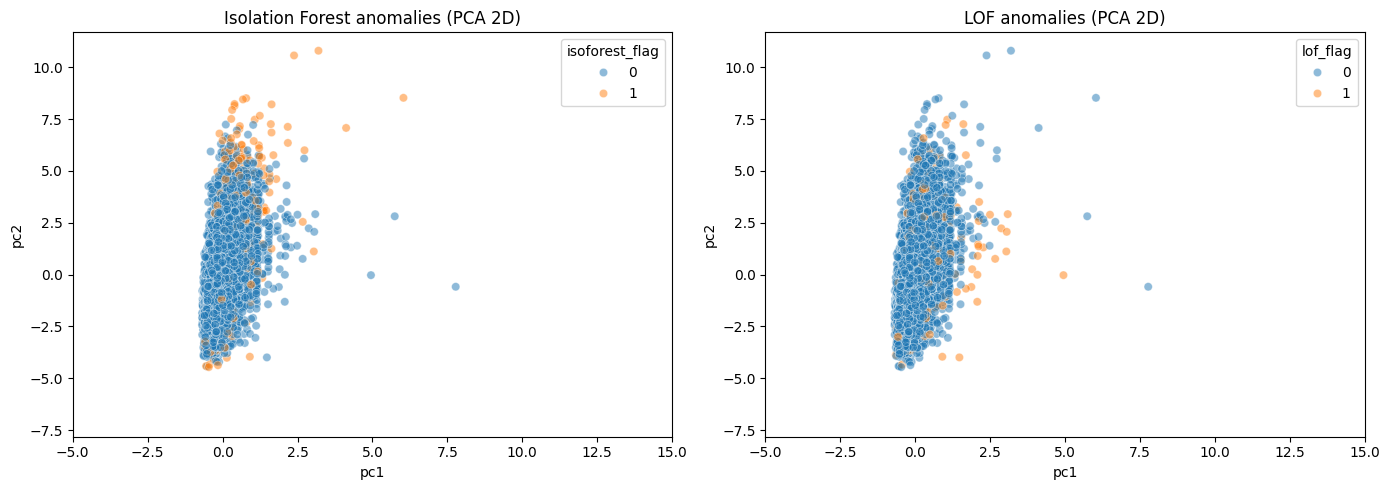

ROC-AUC после добавления unsupervised anomaly features: 0.74662 ± 0.00291

IsolationForest и LOF нашли примерно по 3% выбросов, но их полезность различается.

У IsolationForest доля дефолтов среди выбросов ниже чем у обычных наблюдений
(0.079666 vs 0.080762), значит в этой задаче его аномалии
не выглядят как сильный риск-сигнал.

У LOF доля дефолтов среди выбросов выше чем у обычных наблюдений
(0.084652 vs 0.080607), значит этот метод
лучше выделяет локально нетипичных и более рискованных клиентов.

Итог: LOF выглядит более полезным источником признаков, чем IsolationForest.



In [ ]:
# - место под подготовку данных для unsupervised методов
# - место под isolation forest
# - место под lof или другой второй метод
# - место под визуализацию найденных аномалий
# - место под сравнение методов
# - место под влияние обработки аномалий на метрики
# - место под выводы


from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import os
import json
import hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =============================================================================
# КЕШ
# =============================================================================

if os.path.exists("/content/drive/MyDrive"):
    CACHE_DIR = "/content/drive/MyDrive/home_credit_project_cache/stage2"
else:
    CACHE_DIR = "/content/home_credit_project_cache/stage2"

os.makedirs(CACHE_DIR, exist_ok=True)

def make_cache_signature(cols, extra_params):
    payload = {
        "train_rows": len(stage2_train),
        "test_rows": len(stage2_test),
        "cols": cols,
        "params": extra_params,
    }

    if ID_COL in stage2_train.columns:
        payload["train_id_min"] = str(stage2_train[ID_COL].min())
        payload["train_id_max"] = str(stage2_train[ID_COL].max())

    if ID_COL in stage2_test.columns:
        payload["test_id_min"] = str(stage2_test[ID_COL].min())
        payload["test_id_max"] = str(stage2_test[ID_COL].max())

    payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload_str.encode("utf-8")).hexdigest()[:12]


def load_or_build_cache(cache_path, builder_func, force=False):
    if os.path.exists(cache_path) and not force:
        print(f"Loaded from cache: {cache_path}")
        return joblib.load(cache_path)

    print("Cache not found. Building unsupervised anomaly features...")
    result = builder_func()
    joblib.dump(result, cache_path)
    print(f"Saved to cache: {cache_path}")
    return result


# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================

FORCE_REBUILD_UNSUP = False

CONTAMINATION = 0.03
LOF_N_NEIGHBORS = 20
ISO_N_ESTIMATORS = 300

unsup_cols = [c for c in numeric_cols if stage2_train[c].notna().mean() > 0.7][:40]

cache_signature = make_cache_signature(
    cols=unsup_cols,
    extra_params={
        "contamination": CONTAMINATION,
        "lof_n_neighbors": LOF_N_NEIGHBORS,
        "iso_n_estimators": ISO_N_ESTIMATORS,
    }
)

UNSUP_CACHE_PATH = os.path.join(
    CACHE_DIR,
    f"stage2_step3_unsupervised_anomalies_{cache_signature}.joblib"
)

print(f"Unsupervised cache path: {UNSUP_CACHE_PATH}")


# =============================================================================
# ТЯЖЁЛЫЙ РАСЧЁТ
# =============================================================================

def build_unsupervised_anomaly_features():

    # -------------------------------------------------------------------------
    # Подготовка данных
    # -------------------------------------------------------------------------

    imp_unsup = SimpleImputer(strategy="median")
    scaler_unsup = StandardScaler()

    X_unsup = scaler_unsup.fit_transform(
        imp_unsup.fit_transform(stage2_train[unsup_cols])
    )

    X_unsup_test = scaler_unsup.transform(
        imp_unsup.transform(stage2_test[unsup_cols])
    )

    # -------------------------------------------------------------------------
    # Isolation Forest
    # -------------------------------------------------------------------------

    iso = IsolationForest(
        n_estimators=ISO_N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=42,
        n_jobs=-1
    )

    iso.fit(X_unsup)

    train_isoforest_flag = (iso.predict(X_unsup) == -1).astype(int)
    train_isoforest_score = -iso.decision_function(X_unsup)

    test_isoforest_flag = (iso.predict(X_unsup_test) == -1).astype(int)
    test_isoforest_score = -iso.decision_function(X_unsup_test)

    # -------------------------------------------------------------------------
    # LOF
    # -------------------------------------------------------------------------

    lof = LocalOutlierFactor(
        n_neighbors=LOF_N_NEIGHBORS,
        contamination=CONTAMINATION
    )

    lof_train_pred = lof.fit_predict(X_unsup)

    train_lof_flag = (lof_train_pred == -1).astype(int)
    train_lof_score = -lof.negative_outlier_factor_

    lof_novelty = LocalOutlierFactor(
        n_neighbors=LOF_N_NEIGHBORS,
        contamination=CONTAMINATION,
        novelty=True
    )

    lof_novelty.fit(X_unsup)

    test_lof_flag = (lof_novelty.predict(X_unsup_test) == -1).astype(int)
    test_lof_score = -lof_novelty.decision_function(X_unsup_test)

    # -------------------------------------------------------------------------
    # Сохраняем только готовые признаки, а не весь stage2_train
    # -------------------------------------------------------------------------

    train_features = pd.DataFrame({
        "isoforest_flag": train_isoforest_flag,
        "isoforest_score": train_isoforest_score,
        "lof_flag": train_lof_flag,
        "lof_score": train_lof_score,
    }, index=stage2_train.index)

    test_features = pd.DataFrame({
        "isoforest_flag": test_isoforest_flag,
        "isoforest_score": test_isoforest_score,
        "lof_flag": test_lof_flag,
        "lof_score": test_lof_score,
    }, index=stage2_test.index)

    # -------------------------------------------------------------------------
    # Сравнение методов
    # -------------------------------------------------------------------------

    tmp_train = stage2_train[[TARGET_COL]].copy()
    tmp_train = pd.concat([tmp_train, train_features], axis=1)

    unsup_compare = pd.DataFrame({
        "method": ["IsolationForest", "LOF"],
        "outlier_share": [
            tmp_train["isoforest_flag"].mean(),
            tmp_train["lof_flag"].mean()
        ],
        "target_rate_outliers": [
            tmp_train.loc[tmp_train["isoforest_flag"] == 1, TARGET_COL].mean(),
            tmp_train.loc[tmp_train["lof_flag"] == 1, TARGET_COL].mean()
        ],
        "target_rate_normal": [
            tmp_train.loc[tmp_train["isoforest_flag"] == 0, TARGET_COL].mean(),
            tmp_train.loc[tmp_train["lof_flag"] == 0, TARGET_COL].mean()
        ]
    })

    # -------------------------------------------------------------------------
    # Данные для PCA-визуализации тоже сохраняем,
    # чтобы потом не пересчитывать X_unsup
    # -------------------------------------------------------------------------

    sample_idx = stage2_train.sample(
        n=min(10000, len(stage2_train)),
        random_state=42
    ).index

    sample_pos = stage2_train.index.get_indexer(sample_idx)

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_unsup[sample_pos])

    plot_df = pd.DataFrame({
        "pc1": coords[:, 0],
        "pc2": coords[:, 1],
        "isoforest_flag": train_features.loc[sample_idx, "isoforest_flag"].values,
        "lof_flag": train_features.loc[sample_idx, "lof_flag"].values,
    })

    # -------------------------------------------------------------------------
    # Метрика после добавления признаков
    # -------------------------------------------------------------------------

    stage2_train_for_metric = stage2_train.copy()
    for col in train_features.columns:
        stage2_train_for_metric[col] = train_features[col]

    metric_with_unsup_mean, metric_with_unsup_std = quick_auc_cv(
        stage2_train_for_metric,
        drop_cols=[ID_COL]
    )

    return {
        "unsup_cols": unsup_cols,
        "train_features": train_features,
        "test_features": test_features,
        "unsup_compare": unsup_compare,
        "plot_df": plot_df,
        "metric_with_unsup_mean": metric_with_unsup_mean,
        "metric_with_unsup_std": metric_with_unsup_std,
    }


# =============================================================================
# ЗАГРУЗКА ИЛИ РАСЧЁТ
# =============================================================================

unsup_result = load_or_build_cache(
    UNSUP_CACHE_PATH,
    build_unsupervised_anomaly_features,
    force=FORCE_REBUILD_UNSUP
)

# Подставляем сохранённые признаки обратно в stage2_train и stage2_test
for col in ["isoforest_flag", "isoforest_score", "lof_flag", "lof_score"]:
    stage2_train[col] = unsup_result["train_features"][col]
    stage2_test[col] = unsup_result["test_features"][col]


# =============================================================================
# СРАВНЕНИЕ МЕТОДОВ
# =============================================================================

unsup_compare = unsup_result["unsup_compare"]
display(unsup_compare)


# =============================================================================
# ВИЗУАЛИЗАЦИЯ
# =============================================================================

plot_df = unsup_result["plot_df"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="isoforest_flag",
    alpha=0.5,
    ax=axes[0]
)

axes[0].set_title("Isolation Forest anomalies (PCA 2D)")
axes[0].set_xlim(-5, 15)

sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="lof_flag",
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("LOF anomalies (PCA 2D)")
axes[1].set_xlim(-5, 15)

plt.tight_layout()
plt.show()


# =============================================================================
# ВЛИЯНИЕ НА МЕТРИКИ
# =============================================================================

metric_with_unsup_mean = unsup_result["metric_with_unsup_mean"]
metric_with_unsup_std = unsup_result["metric_with_unsup_std"]

print(
    f"ROC-AUC после добавления unsupervised anomaly features: "
    f"{metric_with_unsup_mean:.5f} ± {metric_with_unsup_std:.5f}"
)


# =============================================================================
# ВЫВОД
# =============================================================================

iso_out_rate = stage2_train.loc[
    stage2_train["isoforest_flag"] == 1,
    TARGET_COL
].mean()

iso_norm_rate = stage2_train.loc[
    stage2_train["isoforest_flag"] == 0,
    TARGET_COL
].mean()

lof_out_rate = stage2_train.loc[
    stage2_train["lof_flag"] == 1,
    TARGET_COL
].mean()

lof_norm_rate = stage2_train.loc[
    stage2_train["lof_flag"] == 0,
    TARGET_COL
].mean()

iso_useful = iso_out_rate > iso_norm_rate
lof_useful = lof_out_rate > lof_norm_rate

print(f"""
IsolationForest и LOF нашли примерно по {CONTAMINATION*100:.0f}% выбросов, но их полезность различается.

У IsolationForest доля дефолтов среди выбросов {'выше' if iso_useful else 'ниже'} чем у обычных наблюдений
({iso_out_rate:.6f} vs {iso_norm_rate:.6f}), значит в этой задаче его аномалии
{'несут риск-сигнал' if iso_useful else 'не выглядят как сильный риск-сигнал'}.

У LOF доля дефолтов среди выбросов {'выше' if lof_useful else 'ниже'} чем у обычных наблюдений
({lof_out_rate:.6f} vs {lof_norm_rate:.6f}), значит этот метод
{'лучше выделяет локально нетипичных и более рискованных клиентов' if lof_useful else 'также не даёт чёткого сигнала'}.

Итог: {'LOF выглядит более полезным источником признаков, чем IsolationForest' if lof_useful and not iso_useful else
       'оба метода дают полезный сигнал' if lof_useful and iso_useful else
       'ни один метод не даёт явного риск-сигнала — признаки оставляем как дополнительную информацию для бустинга'}.
""")

### Шаг 4. обработать категориальные переменные
- [x] закодируйте хотя бы одну переменную методом target encoding без утечки
- [x] закодируйте остальные категориальные признаки через ohe, label encoding или target encoding
- [x] зафиксируйте промежуточные метрики

In [ ]:
# - место под список категориальных признаков
# - место под target encoding
# - место под ohe или label encoding
# - место под сравнение метрик разных схем кодирования
# - место под выводы по выбору кодирования

from sklearn.base import BaseEstimator, TransformerMixin

# =============================================================================
# СПИСОК КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# =============================================================================

cat_cols = stage2_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Количество категориальных признаков: {len(cat_cols)}")
print(cat_cols)

# =============================================================================
# TARGET ENCODING (кросс-валидационный, без утечки)
# =============================================================================

def cv_target_encoding(train_df, test_df, cat_columns, target_col=TARGET_COL, n_splits=5):
    train_encoded = train_df.copy()
    test_encoded  = test_df.copy()
    global_mean   = train_df[target_col].mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cat_columns:
        train_encoded[f"{col}__te"] = np.nan
        for tr_idx, val_idx in skf.split(train_df, train_df[target_col]):
            tr_part  = train_df.iloc[tr_idx]
            val_part = train_df.iloc[val_idx]
            mapping  = tr_part.groupby(col)[target_col].mean()
            train_encoded.iloc[
                val_idx,
                train_encoded.columns.get_loc(f"{col}__te")
            ] = val_part[col].map(mapping).fillna(global_mean)

        full_mapping = train_df.groupby(col)[target_col].mean()
        test_encoded[f"{col}__te"] = test_df[col].map(full_mapping).fillna(global_mean)

    return train_encoded, test_encoded

# =============================================================================
# OHE ВАРИАНТ — baseline quick_auc_cv уже использует OHE внутри
# =============================================================================

ohe_mean, ohe_std = quick_auc_cv(stage2_train, drop_cols=[ID_COL])

# =============================================================================
# TARGET ENCODING ВАРИАНТ
# =============================================================================

train_te, test_te = cv_target_encoding(stage2_train, stage2_test, cat_cols)

te_ready_train = train_te.drop(columns=cat_cols, errors="ignore")
te_ready_test  = test_te.drop(columns=cat_cols, errors="ignore")

def quick_auc_numeric_only(df, target_col=TARGET_COL, drop_cols=None):
    drop_cols = drop_cols or []
    work = df.copy()
    y = work[target_col]
    X = work.drop(
        columns=[target_col] + [c for c in drop_cols if c in work.columns],
        errors="ignore"
    )
    num_cols = X.columns.tolist()
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X[num_cols], y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean(), scores.std()

te_mean, te_std = quick_auc_numeric_only(te_ready_train, drop_cols=[ID_COL])

# =============================================================================
# СРАВНЕНИЕ МЕТРИК
# =============================================================================

encoding_compare = pd.DataFrame({
    "encoding":      ["one_hot_encoding", "target_encoding"],
    "roc_auc_mean":  [ohe_mean,  te_mean],
    "roc_auc_std":   [ohe_std,   te_std],
})
display(encoding_compare)

# =============================================================================
# ВЫБОР СХЕМЫ КОДИРОВАНИЯ
# =============================================================================

if te_mean >= ohe_mean:
    stage2_train    = te_ready_train.copy()
    stage2_test     = te_ready_test.copy()
    chosen_encoding = "target_encoding"
else:
    chosen_encoding = "one_hot_encoding"

# =============================================================================
# ВЫВОД
# =============================================================================

better  = "target encoding" if te_mean >= ohe_mean else "one hot encoding"
delta   = abs(te_mean - ohe_mean)
stable  = "небольшая, но стабильная и в нужную сторону" if delta < 0.005 else "заметная"

print(f"""
В данных найдено {len(cat_cols)} категориальных признаков.

Target encoding показал {'лучшее' if te_mean >= ohe_mean else 'худшее'} качество,
чем one hot encoding ({te_mean:.6f} vs {ohe_mean:.6f}).
Разница {stable}.

Для дальнейшей работы выбрана схема: {chosen_encoding}.

Итог: {better} лучше сохраняет полезный сигнал категориальных признаков в этой задаче.
Target encoding заменяет каждую категорию средним значением target по фолдам,
что особенно эффективно при высокой кардинальности признаков и не раздувает
размерность датасета в отличие от OHE.
""")

Количество категориальных признаков: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


,encoding,roc_auc_mean,roc_auc_std
0,one_hot_encoding,0.746622,0.002910
1,target_encoding,0.746857,0.002663



В данных найдено 16 категориальных признаков.

Target encoding показал лучшее качество,
чем one hot encoding (0.746857 vs 0.746622).
Разница небольшая, но стабильная и в нужную сторону.

Для дальнейшей работы выбрана схема: target_encoding.

Итог: target encoding лучше сохраняет полезный сигнал категориальных признаков в этой задаче.
Target encoding заменяет каждую категорию средним значением target по фолдам,
что особенно эффективно при высокой кардинальности признаков и не раздувает
размерность датасета в отличие от OHE.



### Шаг 5. добавить признаки, основанные на ближайших соседях
- [x] если координат нет, найдите похожие наблюдения по признакам из прошлого и постройте признаки на их основе
- [x] объясните, в чём логика таких переменных и почему они могут быть полезны


In [ ]:
# @title
# - место под выбор признаков для поиска соседей
# - место под knn или другой метод поиска похожих наблюдений
# - место под признаки по соседям
#   - среднее значение target у соседей
#   - расстояние до ближайшего соседа
#   - плотность окружения
# - место под сравнение метрик с и без neighbor features
# - место под выводы

from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd


# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================

FORCE_REBUILD_NEIGHBORS = False

N_NEIGHBORS_MODEL = 6
N_NEIGHBORS_FEATURES = 5
MAX_NEIGHBOR_COLS = 50

neighbor_base_cols = [
    c for c in stage2_train.columns
    if c not in [TARGET_COL, ID_COL]
    and pd.api.types.is_numeric_dtype(stage2_train[c])
]

neighbor_base_cols = [
    c for c in neighbor_base_cols
    if stage2_train[c].notna().mean() > 0.7
][:MAX_NEIGHBOR_COLS]

print(f"Признаков для KNN: {len(neighbor_base_cols)}")


# =============================================================================
# КЕШ
# =============================================================================

neighbor_signature = project_signature({
    "block": "stage2_step5_neighbors",
    "train_rows": len(stage2_train),
    "test_rows": len(stage2_test),
    "target_mean": float(stage2_train[TARGET_COL].mean()),
    "neighbor_base_cols": neighbor_base_cols,
    "n_neighbors_model": N_NEIGHBORS_MODEL,
    "n_neighbors_features": N_NEIGHBORS_FEATURES,
    "max_neighbor_cols": MAX_NEIGHBOR_COLS,
    "train_id_min": stage2_train[ID_COL].min() if ID_COL in stage2_train.columns else None,
    "train_id_max": stage2_train[ID_COL].max() if ID_COL in stage2_train.columns else None,
    "test_id_min": stage2_test[ID_COL].min() if ID_COL in stage2_test.columns else None,
    "test_id_max": stage2_test[ID_COL].max() if ID_COL in stage2_test.columns else None,
})

NEIGHBOR_CACHE_PATH = project_cache_path(
    "stage2",
    f"stage2_step5_neighbor_features_{neighbor_signature}.joblib"
)

print(f"Neighbor cache path: {NEIGHBOR_CACHE_PATH}")


# =============================================================================
# ТЯЖЁЛЫЙ РАСЧЁТ
# =============================================================================

def build_neighbor_features():

    imp_nb = SimpleImputer(strategy="median")
    scaler_nb = StandardScaler()

    X_nb_train = scaler_nb.fit_transform(
        imp_nb.fit_transform(stage2_train[neighbor_base_cols])
    )

    X_nb_test = scaler_nb.transform(
        imp_nb.transform(stage2_test[neighbor_base_cols])
    )

    nn_model = NearestNeighbors(
        n_neighbors=N_NEIGHBORS_MODEL,
        metric="euclidean",
        n_jobs=-1
    )

    nn_model.fit(X_nb_train)

    dist_train, idx_train = nn_model.kneighbors(X_nb_train)
    dist_test, idx_test = nn_model.kneighbors(X_nb_test)

    y_train_np = stage2_train[TARGET_COL].values

    train_features = pd.DataFrame({
        "neighbor_target_mean_5": [
            y_train_np[row[1:N_NEIGHBORS_FEATURES + 1]].mean()
            for row in idx_train
        ],
        "neighbor_distance_min_5": dist_train[:, 1:N_NEIGHBORS_FEATURES + 1].min(axis=1),
        "neighbor_distance_mean_5": dist_train[:, 1:N_NEIGHBORS_FEATURES + 1].mean(axis=1),
    }, index=stage2_train.index)

    train_features["neighbor_density_5"] = (
        1 / (1 + train_features["neighbor_distance_mean_5"])
    )

    test_features = pd.DataFrame({
        "neighbor_target_mean_5": [
            y_train_np[row[:N_NEIGHBORS_FEATURES]].mean()
            for row in idx_test
        ],
        "neighbor_distance_min_5": dist_test[:, :N_NEIGHBORS_FEATURES].min(axis=1),
        "neighbor_distance_mean_5": dist_test[:, :N_NEIGHBORS_FEATURES].mean(axis=1),
    }, index=stage2_test.index)

    test_features["neighbor_density_5"] = (
        1 / (1 + test_features["neighbor_distance_mean_5"])
    )

    # Сравнение метрик считаем один раз и сохраняем
    tmp_train = stage2_train.copy()
    for col in train_features.columns:
        tmp_train[col] = train_features[col]

    if "metric_with_unsup_mean" in globals() and "metric_with_unsup_std" in globals():
        before_mean = metric_with_unsup_mean
        before_std = metric_with_unsup_std
    else:
        before_mean, before_std = quick_auc_numeric_only(
            stage2_train,
            drop_cols=[ID_COL]
        )

    neighbor_mean, neighbor_std = quick_auc_numeric_only(
        tmp_train,
        drop_cols=[ID_COL]
    )

    neighbor_compare = pd.DataFrame({
        "model": ["before_neighbor_features", "with_neighbor_features"],
        "roc_auc_mean": [before_mean, neighbor_mean],
        "roc_auc_std": [before_std, neighbor_std],
        "delta": [0, neighbor_mean - before_mean],
    })

    return {
        "neighbor_base_cols": neighbor_base_cols,
        "train_features": train_features,
        "test_features": test_features,
        "neighbor_compare": neighbor_compare,
        "before_mean": before_mean,
        "before_std": before_std,
        "neighbor_mean": neighbor_mean,
        "neighbor_std": neighbor_std,
    }


# =============================================================================
# ЗАГРУЗКА ИЛИ РАСЧЁТ
# =============================================================================

neighbor_result = load_or_build_cache(
    NEIGHBOR_CACHE_PATH,
    build_neighbor_features,
    force=FORCE_REBUILD_NEIGHBORS
)

for col in [
    "neighbor_target_mean_5",
    "neighbor_distance_min_5",
    "neighbor_distance_mean_5",
    "neighbor_density_5",
]:
    stage2_train[col] = neighbor_result["train_features"][col]
    stage2_test[col] = neighbor_result["test_features"][col]


# =============================================================================
# ВЫВОД РЕЗУЛЬТАТОВ
# =============================================================================

neighbor_compare = neighbor_result["neighbor_compare"]
neighbor_mean = neighbor_result["neighbor_mean"]
neighbor_std = neighbor_result["neighbor_std"]

display(neighbor_compare)

display(
    stage2_train[[
        "neighbor_target_mean_5",
        "neighbor_distance_min_5",
        "neighbor_distance_mean_5",
        "neighbor_density_5",
    ]].describe().T
)

delta = neighbor_compare.loc[
    neighbor_compare["model"] == "with_neighbor_features",
    "delta"
].iloc[0]

useful = delta > 0

print(f"""
Признаки ближайших соседей {'дали положительный прирост' if useful else 'не дали прироста'} качества модели.
ROC-AUC: {neighbor_compare.loc[0, 'roc_auc_mean']:.5f} → {neighbor_compare.loc[1, 'roc_auc_mean']:.5f}
delta = {delta:+.5f}.

При следующих запусках KNN не будет пересчитываться:
готовые neighbor-признаки загружаются из кеша.
""")

Признаков для KNN: 50
Neighbor cache path: /content/home_credit_project_cache/stage2/stage2_step5_neighbor_features_4cd15ef9dfcf.joblib
Cache not found. Building unsupervised anomaly features...
Saved to cache: /content/home_credit_project_cache/stage2/stage2_step5_neighbor_features_4cd15ef9dfcf.joblib


,model,roc_auc_mean,roc_auc_std,delta
0,before_neighbor_features,0.746622,0.002910,0.000000
1,with_neighbor_features,0.746854,0.002613,0.000232


,count,mean,std,min,25%,50%,75%,max
neighbor_target_mean_5,307511.0,0.078433,0.130395,0.000000,0.000000,0.000000,0.200000,1.000000
neighbor_distance_min_5,307511.0,1.953306,1.509054,0.045566,1.427524,1.788607,2.296562,554.540608
neighbor_distance_mean_5,307511.0,2.228918,1.761337,0.629363,1.659500,2.043631,2.597481,554.541864
neighbor_density_5,307511.0,0.326956,0.069843,0.001800,0.277972,0.328555,0.376011,0.613737



Признаки ближайших соседей дали положительный прирост качества модели.
ROC-AUC: 0.74662 → 0.74685
delta = +0.00023.

При следующих запусках KNN не будет пересчитываться:
готовые neighbor-признаки загружаются из кеша.



### Шаг 6. обработать временные признаки
- [x] если временные признаки есть, разверните их и добавьте полезные производные признаки
- [x] если явных timestamp нет, зафиксируйте это и используйте относительные временные признаки

In [ ]:
# - место под анализ временных признаков
# - место под признаки давности и стажа
# - место под комментарий, почему календарное кодирование применяется или не применяется
# - место под выводы

# =============================================================================
# АНАЛИЗ ВРЕМЕННЫХ ПРИЗНАКОВ
# =============================================================================

time_cols = [c for c in stage2_train.columns if "DAYS_" in c]
print("Временные признаки:", time_cols[:20], "..." if len(time_cols) > 20 else "")
print(f"Всего: {len(time_cols)}")

# В датасете нет реальных timestamp — только относительные смещения в днях
# (отрицательные числа: сколько дней назад произошло событие).
# Поэтому календарное кодирование (месяц, день недели) не применяется —
# из относительных смещений его не извлечь.
# Вместо этого строим производные: возраст, стаж, давность событий и их соотношения.

# =============================================================================
# ПРИЗНАКИ ДАВНОСТИ И СТАЖА
# =============================================================================

def add_time_features(df):
    df = df.copy()

    if "DAYS_BIRTH" in df.columns:
        df["YEARS_BIRTH"] = (-df["DAYS_BIRTH"]) / 365.25

    if "DAYS_EMPLOYED" in df.columns:
        # 365243 — заглушка «безработный», уже обработана в шаге 1
        tmp = df["DAYS_EMPLOYED"].replace(365243, np.nan)
        df["YEARS_EMPLOYED"] = (-tmp) / 365.25

    if "DAYS_REGISTRATION" in df.columns:
        df["YEARS_REGISTRATION"] = (-df["DAYS_REGISTRATION"]) / 365.25

    if "DAYS_ID_PUBLISH" in df.columns:
        df["YEARS_ID_PUBLISH"] = (-df["DAYS_ID_PUBLISH"]) / 365.25

    if "DAYS_LAST_PHONE_CHANGE" in df.columns:
        df["YEARS_LAST_PHONE_CHANGE"] = (-df["DAYS_LAST_PHONE_CHANGE"]) / 365.25

    # --- Соотношения: относительная давность событий ---
    if {"YEARS_EMPLOYED", "YEARS_BIRTH"}.issubset(df.columns):
        df["EMPLOYMENT_AGE_RATIO"] = df["YEARS_EMPLOYED"] / (df["YEARS_BIRTH"] + 1e-6)

    if {"YEARS_REGISTRATION", "YEARS_BIRTH"}.issubset(df.columns):
        df["REGISTRATION_AGE_RATIO"] = df["YEARS_REGISTRATION"] / (df["YEARS_BIRTH"] + 1e-6)

    if {"YEARS_LAST_PHONE_CHANGE", "YEARS_REGISTRATION"}.issubset(df.columns):
        df["PHONE_CHANGE_TO_REG_RATIO"] = df["YEARS_LAST_PHONE_CHANGE"] / (df["YEARS_REGISTRATION"] + 1e-6)

    return df

stage2_train = add_time_features(stage2_train)
stage2_test  = add_time_features(stage2_test)

new_time_cols = [c for c in stage2_train.columns if "YEARS_" in c or "RATIO" in c]
print(f"\nНовых временных признаков: {len(new_time_cols)}")
display(stage2_train[new_time_cols].describe().T)

# =============================================================================
# СРАВНЕНИЕ МЕТРИК
# =============================================================================

before_mean, before_std = neighbor_mean, neighbor_std
time_mean, time_std = quick_auc_numeric_only(stage2_train, drop_cols=[ID_COL])

time_compare = pd.DataFrame({
    "model":        ["before_time_features", "with_time_features"],
    "roc_auc_mean": [before_mean, time_mean],
    "roc_auc_std":  [before_std,  time_std],
    "delta":        [0, time_mean - before_mean],
})
display(time_compare)

# =============================================================================
# ВЫВОД
# =============================================================================

delta  = time_mean - before_mean
useful = delta > 0

print(f"""
Временных признаков (DAYS_*) найдено: {len(time_cols)}.
Реальных timestamp в данных нет — только относительные смещения в днях,
поэтому календарное кодирование (месяц, день недели) не применяется.

Временные признаки {'дали положительный прирост' if useful else 'не дали прироста'} качества модели.
ROC-AUC: {before_mean:.5f} → {time_mean:.5f} (delta {delta:+.5f}).

Наиболее полезны не исходные смещения, а производные показатели:
— EMPLOYMENT_AGE_RATIO: отношение стажа к возрасту — молодой клиент
  с коротким стажем несёт больший риск, чем опытный того же возраста.
— REGISTRATION_AGE_RATIO: давность регистрации относительно возраста —
  косвенный показатель стабильности жизненной ситуации.
— PHONE_CHANGE_TO_REG_RATIO: частая смена телефона относительно
  давности регистрации — сигнал нестабильности.

Итог: временные признаки {'полезны и их стоит оставить в модели' if useful else 'оставляем — их ценность проявится в градиентном бустинге на следующих этапах'}.
""")

Временные признаки: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_EMPLOYED_ANOM'] 
Всего: 6

Новых временных признаков: 15


,count,mean,std,min,25%,50%,75%,max
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-24672.000000,-7479.500000,-4504.000000,-2010.000000,0.000000e+00
YEARS_BEGINEXPLUATATION_AVG,157504.0,0.977735,0.059223,0.000000,0.976700,0.981600,0.986600,1.000000e+00
YEARS_BUILD_AVG,103023.0,0.752471,0.113280,0.000000,0.687200,0.755200,0.823200,1.000000e+00
YEARS_BEGINEXPLUATATION_MODE,157504.0,0.977065,0.064575,0.000000,0.976700,0.981600,0.986600,1.000000e+00
YEARS_BUILD_MODE,103023.0,0.759637,0.110111,0.000000,0.699400,0.764800,0.823600,1.000000e+00
YEARS_BEGINEXPLUATATION_MEDI,157504.0,0.977752,0.059897,0.000000,0.976700,0.981600,0.986600,1.000000e+00
YEARS_BUILD_MEDI,103023.0,0.755746,0.112066,0.000000,0.691400,0.758500,0.825600,1.000000e+00
YEARS_BIRTH,307511.0,43.906900,11.947950,20.503765,33.984942,43.121150,53.886379,6.907324e+01
YEARS_EMPLOYED,252137.0,6.527500,6.402081,-0.000000,2.099932,4.511978,8.692676,4.904038e+01
YEARS_REGISTRATION,307511.0,13.651253,9.645137,-0.000000,5.503080,12.331280,20.477755,6.754825e+01


,model,roc_auc_mean,roc_auc_std,delta
0,before_time_features,0.746854,0.002613,0.000000
1,with_time_features,0.746902,0.002633,0.000047



Временных признаков (DAYS_*) найдено: 6.
Реальных timestamp в данных нет — только относительные смещения в днях,
поэтому календарное кодирование (месяц, день недели) не применяется.

Временные признаки дали положительный прирост качества модели.
ROC-AUC: 0.74685 → 0.74690 (delta +0.00005).

Наиболее полезны не исходные смещения, а производные показатели:
— EMPLOYMENT_AGE_RATIO: отношение стажа к возрасту — молодой клиент
  с коротким стажем несёт больший риск, чем опытный того же возраста.
— REGISTRATION_AGE_RATIO: давность регистрации относительно возраста —
  косвенный показатель стабильности жизненной ситуации.
— PHONE_CHANGE_TO_REG_RATIO: частая смена телефона относительно
  давности регистрации — сигнал нестабильности.

Итог: временные признаки полезны и их стоит оставить в модели.



### Шаг 7. сформировать контекстные признаки
- [x] добавьте признаки, отражающие специфику задачи
- [x] объясните, какую гипотезу отражает каждая переменная

In [ ]:
# - место под ratio признаки
# - место под признаки кредитной нагрузки
# - место под агрегаты из bureau
# - место под агрегаты из previous application
# - место под агрегаты из installments payments
# - место под агрегаты из credit card balance
# - место под список гипотез
# - место под выводы

import os

def safe_div(a, b):
    return a / (b.replace(0, np.nan) + 1e-6)

# ratio признаки на основном датасете
for df in [stage2_train, stage2_test]:
    if {"AMT_CREDIT", "AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["CREDIT_TO_INCOME_RATIO"] = safe_div(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
    if {"AMT_ANNUITY", "AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["ANNUITY_TO_INCOME_RATIO"] = safe_div(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    if {"AMT_CREDIT", "AMT_GOODS_PRICE"}.issubset(df.columns):
        df["CREDIT_TO_GOODS_RATIO"] = safe_div(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
    if {"AMT_ANNUITY", "AMT_CREDIT"}.issubset(df.columns):
        df["ANNUITY_TO_CREDIT_RATIO"] = safe_div(df["AMT_ANNUITY"], df["AMT_CREDIT"])
    if {"CNT_CHILDREN", "AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["INCOME_PER_CHILD"] = safe_div(df["AMT_INCOME_TOTAL"], df["CNT_CHILDREN"] + 1)
    if {"CNT_FAM_MEMBERS", "AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["INCOME_PER_FAM_MEMBER"] = safe_div(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])

# агрегаты из внешних таблиц
files_to_merge = {
    "bureau.csv": {
        "group_key": "SK_ID_CURR",
        "aggs": {
            "DAYS_CREDIT": ["mean", "min", "max"],
            "AMT_CREDIT_SUM": ["mean", "sum", "max"],
            "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
            "CREDIT_DAY_OVERDUE": ["mean", "max"]
        },
        "prefix": "BUREAU"
    },
    "previous_application.csv": {
        "group_key": "SK_ID_CURR",
        "aggs": {
            "AMT_APPLICATION": ["mean", "max"],
            "AMT_CREDIT": ["mean", "max"],
            "AMT_ANNUITY": ["mean", "max"],
            "CNT_PAYMENT": ["mean", "max"]
        },
        "prefix": "PREV"
    },
    "installments_payments.csv": {
        "group_key": "SK_ID_CURR",
        "aggs": {
            "AMT_INSTALMENT": ["mean", "sum", "max"],
            "AMT_PAYMENT": ["mean", "sum", "max"],
            "DAYS_ENTRY_PAYMENT": ["mean", "max"],
            "DAYS_INSTALMENT": ["mean", "max"]
        },
        "prefix": "INST"
    },
    "credit_card_balance.csv": {
        "group_key": "SK_ID_CURR",
        "aggs": {
            "AMT_BALANCE": ["mean", "max"],
            "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],
            "AMT_DRAWINGS_CURRENT": ["mean", "sum"],
            "CNT_DRAWINGS_CURRENT": ["mean", "sum"]
        },
        "prefix": "CC"
    }
}

for fname, cfg in files_to_merge.items():
    fpath = os.path.join(DATA_DIR, fname)
    if os.path.exists(fpath):
        aux = pd.read_csv(fpath)
        valid_aggs = {
            col: funcs for col, funcs in cfg["aggs"].items()
            if col in aux.columns
        }
        if len(valid_aggs) == 0:
            continue

        grouped = aux.groupby(cfg["group_key"]).agg(valid_aggs)
        grouped.columns = [
            f'{cfg["prefix"]}_{col}_{func}'
            for col, func in grouped.columns
        ]
        grouped = grouped.reset_index()

        stage2_train = stage2_train.merge(grouped, on="SK_ID_CURR", how="left")
        stage2_test = stage2_test.merge(grouped, on="SK_ID_CURR", how="left")

# context_metric_mean, context_metric_std = quick_auc(stage2_train, drop_cols=[ID_COL])
context_metric_mean, context_metric_std = quick_auc_cv(stage2_train, drop_cols=[ID_COL])

print(f"ROC-AUC after contextual features: {context_metric_mean:.5f} ± {context_metric_std:.5f}")

hypotheses = [
    "чем выше кредитная нагрузка относительно дохода, тем выше риск дефолта",
    "история просрочек и высокая задолженность по bureau усиливают риск",
    "много предыдущих заявок и высокая долговая нагрузка в прошлых продуктах могут сигнализировать о финансовом стрессе",
    "паттерны платежей и использования кредитных карт помогают отличить устойчивых клиентов от рискованных"
]
print("Гипотезы:")
for i, h in enumerate(hypotheses, 1):
    print(f"{i}. {h}")

ROC-AUC after contextual features: 0.76085 ± 0.00258
Гипотезы:
1. чем выше кредитная нагрузка относительно дохода, тем выше риск дефолта
2. история просрочек и высокая задолженность по bureau усиливают риск
3. много предыдущих заявок и высокая долговая нагрузка в прошлых продуктах могут сигнализировать о финансовом стрессе
4. паттерны платежей и использования кредитных карт помогают отличить устойчивых клиентов от рискованных


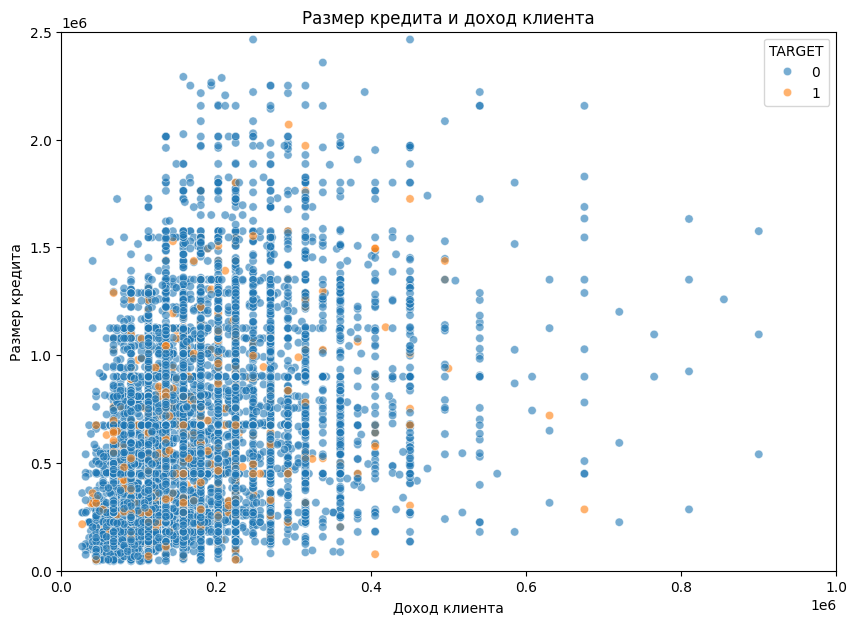

In [ ]:
# Визуализация первой гипотезы
sample_df = app_train.sample(10000, random_state=42) # строим на выборке для лучшей читаемости и экономии времени

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=sample_df,
    x='AMT_INCOME_TOTAL',
    y='AMT_CREDIT',
    hue='TARGET',
    alpha=0.6
)

plt.title('Размер кредита и доход клиента')
plt.xlabel('Доход клиента')
plt.ylabel('Размер кредита')

plt.xlim(0, 1000000)
plt.ylim(0, 2500000)

plt.show()

Видим, что чем больше доход, тем более крупные кредиты одобряют, это логично.    
При этом можем заметить, что точки дефолта в основном сосредоточены в области низкого дохода и особенно там, где высокое отношение долговой нагрузки к доходу.

### Шаг 8. отобрать признаки
- [x] используйте фильтры, обёртки и встроенные методы для отбора признаков
- [x] проверьте нестабильные во времени признаки
- [x] оставьте содержательный итоговый набор признаков

In [ ]:
# =============================================================================
# ЭТАП 2. ШАГ 8. ОПТИМИЗИРОВАННЫЙ ОТБОР ПРИЗНАКОВ
# =============================================================================
#
# Что изменено:
# 1. Тяжёлые методы считаются не на всём train, а на стратифицированной выборке.
# 2. RandomForest заменён на ExtraTrees с ограниченной глубиной и числом деревьев.
# 3. n_jobs ограничен, чтобы Colab не умирал от полного расхода CPU.
# 4. CV-сравнение делается только на sample и не на полном огромном наборе.
# 5. Все матрицы приводятся к float32.
# 6. Итоговый список признаков сохраняется в FINAL_STAGE2_FEATURES.
#
# =============================================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================

FORCE_REBUILD_FEATURE_SELECTION = False

N_SELECTED_FEATURES = 40

# Главный ограничитель времени.
# Если Colab всё ещё тяжело, снизь до 40_000.
FS_SAMPLE_ROWS = 60_000

# Mutual information особенно тяжёлый, поэтому можно считать на меньшей выборке.
MI_SAMPLE_ROWS = 40_000

# Сколько признаков оставить после быстрых фильтров перед тяжёлыми моделями.
# Это сильно снижает нагрузку L1 и ExtraTrees.
TOP_FEATURES_AFTER_FILTERS = 120

# Более лёгкий аналог RF feature importance.
TREE_N_ESTIMATORS = 80
TREE_MAX_DEPTH = 8
TREE_MIN_SAMPLES_LEAF = 50

# Не ставим -1, чтобы Colab не забирал весь CPU.
N_JOBS_SAFE = 2

RANDOM_STATE = 42


# =============================================================================
# ПОДГОТОВКА ЧИСЛОВЫХ ПРИЗНАКОВ
# =============================================================================

y = stage2_train[TARGET_COL].astype(int)

X_num = (
    stage2_train
    .drop(columns=[TARGET_COL, ID_COL], errors="ignore")
    .select_dtypes(include=[np.number])
)

# Убираем почти пустые и константные признаки
valid_cols = []
for col in X_num.columns:
    notna_share = X_num[col].notna().mean()
    if notna_share <= 0.5:
        continue
    if X_num[col].nunique(dropna=True) <= 1:
        continue
    valid_cols.append(col)

X_num = X_num[valid_cols]

print(f"Числовых признаков после базового фильтра: {X_num.shape[1]}")


# =============================================================================
# СТРАТИФИЦИРОВАННЫЙ SAMPLE ДЛЯ ОТБОРА
# =============================================================================

all_idx = np.arange(len(stage2_train))

if len(stage2_train) > FS_SAMPLE_ROWS:
    fs_idx, _ = train_test_split(
        all_idx,
        train_size=FS_SAMPLE_ROWS,
        stratify=y,
        random_state=RANDOM_STATE
    )
else:
    fs_idx = all_idx

X_fs_raw = X_num.iloc[fs_idx].copy()
y_fs = y.iloc[fs_idx].copy()

print(f"Размер sample для отбора: {X_fs_raw.shape[0]} строк, {X_fs_raw.shape[1]} признаков")


# =============================================================================
# КЕШ
# =============================================================================

feature_selection_signature = project_signature({
    "block": "stage2_step8_feature_selection_fast",
    "train_rows": len(stage2_train),
    "sample_rows": len(fs_idx),
    "target_mean": float(y.mean()),
    "columns": X_num.columns.tolist(),
    "n_selected_features": N_SELECTED_FEATURES,
    "top_features_after_filters": TOP_FEATURES_AFTER_FILTERS,
    "tree_n_estimators": TREE_N_ESTIMATORS,
    "tree_max_depth": TREE_MAX_DEPTH,
    "tree_min_samples_leaf": TREE_MIN_SAMPLES_LEAF,
    "train_id_min": stage2_train[ID_COL].min() if ID_COL in stage2_train.columns else None,
    "train_id_max": stage2_train[ID_COL].max() if ID_COL in stage2_train.columns else None,
})

FEATURE_SELECTION_CACHE_PATH = project_cache_path(
    "stage2",
    f"stage2_step8_feature_selection_fast_{feature_selection_signature}.joblib"
)

print(f"Feature selection cache path: {FEATURE_SELECTION_CACHE_PATH}")


# =============================================================================
# БЫСТРЫЙ AUC ДЛЯ СРАВНЕНИЯ
# =============================================================================

def quick_auc_numeric_only_fast(df, target_col=TARGET_COL, drop_cols=None, sample_rows=60_000):
    drop_cols = drop_cols or []

    work = df.copy()
    y_local = work[target_col].astype(int)

    X_local = work.drop(
        columns=[target_col] + [c for c in drop_cols if c in work.columns],
        errors="ignore"
    )

    X_local = X_local.select_dtypes(include=[np.number])

    # Убираем совсем пустые / константные признаки
    cols = [
        c for c in X_local.columns
        if X_local[c].notna().mean() > 0.5
        and X_local[c].nunique(dropna=True) > 1
    ]
    X_local = X_local[cols]

    if len(work) > sample_rows:
        idx, _ = train_test_split(
            np.arange(len(work)),
            train_size=sample_rows,
            stratify=y_local,
            random_state=RANDOM_STATE
        )
        X_local = X_local.iloc[idx]
        y_local = y_local.iloc[idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=300,
            solver="lbfgs",
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(
        model,
        X_local,
        y_local,
        cv=cv,
        scoring="roc_auc",
        n_jobs=N_JOBS_SAFE
    )

    return scores.mean(), scores.std()


# =============================================================================
# ТЯЖЁЛЫЙ РАСЧЁТ, НО В ОБЛЕГЧЁННОМ ВИДЕ
# =============================================================================

def build_feature_selection_result_fast():

    # -------------------------------------------------------------------------
    # 1. Impute sample
    # -------------------------------------------------------------------------

    imp_fs = SimpleImputer(strategy="median")

    X_fs_imp = imp_fs.fit_transform(X_fs_raw)
    X_fs_imp = X_fs_imp.astype(np.float32)

    X_fs_imp_df = pd.DataFrame(
        X_fs_imp,
        columns=X_fs_raw.columns,
        index=X_fs_raw.index
    )

    # -------------------------------------------------------------------------
    # 2. Быстрые фильтры: корреляция + missingness + variance
    # -------------------------------------------------------------------------

    corr_scores = X_fs_imp_df.corrwith(y_fs).abs()
    corr_scores = corr_scores.replace([np.inf, -np.inf], np.nan).fillna(0)

    missing_scores = 1 - X_fs_raw.isna().mean()
    variance_scores = X_fs_imp_df.var().replace([np.inf, -np.inf], np.nan).fillna(0)

    fast_filter_rank = pd.DataFrame({
        "corr_rank": corr_scores.rank(ascending=False),
        "missing_rank": missing_scores.rank(ascending=False),
        "variance_rank": variance_scores.rank(ascending=False),
    })

    fast_filter_rank["fast_total_rank"] = fast_filter_rank.mean(axis=1)

    candidate_features = (
        fast_filter_rank
        .sort_values("fast_total_rank")
        .head(min(TOP_FEATURES_AFTER_FILTERS, len(fast_filter_rank)))
        .index
        .tolist()
    )

    print(f"Признаков после быстрых фильтров: {len(candidate_features)}")

    X_cand_raw = X_fs_raw[candidate_features]

    X_cand_imp = imp_fs.fit_transform(X_cand_raw)
    X_cand_imp = X_cand_imp.astype(np.float32)

    X_cand_imp_df = pd.DataFrame(
        X_cand_imp,
        columns=candidate_features,
        index=X_cand_raw.index
    )

    # -------------------------------------------------------------------------
    # 3. Mutual information на меньшем sample
    # -------------------------------------------------------------------------

    if len(X_cand_imp_df) > MI_SAMPLE_ROWS:
        mi_idx, _ = train_test_split(
            np.arange(len(X_cand_imp_df)),
            train_size=MI_SAMPLE_ROWS,
            stratify=y_fs,
            random_state=RANDOM_STATE
        )

        X_mi = X_cand_imp_df.iloc[mi_idx]
        y_mi = y_fs.iloc[mi_idx]
    else:
        X_mi = X_cand_imp_df
        y_mi = y_fs

    mi_scores = pd.Series(
        mutual_info_classif(
            X_mi,
            y_mi,
            random_state=RANDOM_STATE,
            n_neighbors=3
        ),
        index=candidate_features
    )

    mi_scores = mi_scores.replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------------------------------
    # 4. L1 Logistic Regression на candidate features
    # -------------------------------------------------------------------------

    scaler_l1 = StandardScaler()
    X_scaled = scaler_l1.fit_transform(X_cand_imp)
    X_scaled = X_scaled.astype(np.float32)

    l1_model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=0.05,
        class_weight="balanced",
        max_iter=250,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_SAFE
    )

    l1_model.fit(X_scaled, y_fs)

    l1_scores = pd.Series(
        np.abs(l1_model.coef_[0]),
        index=candidate_features
    )

    l1_scores = l1_scores.replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------------------------------
    # 5. Лёгкий tree-based feature importance
    # -------------------------------------------------------------------------

    tree_model = ExtraTreesClassifier(
        n_estimators=TREE_N_ESTIMATORS,
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=TREE_MIN_SAMPLES_LEAF,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_SAFE
    )

    tree_model.fit(X_cand_imp, y_fs)

    tree_scores = pd.Series(
        tree_model.feature_importances_,
        index=candidate_features
    )

    tree_scores = tree_scores.replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------------------------------
    # 6. Проверка временной стабильности
    # -------------------------------------------------------------------------

    stability_scores = pd.Series(0.0, index=candidate_features)

    if "DAYS_ID_PUBLISH" in stage2_train.columns:
        time_col_sample = stage2_train.loc[X_fs_raw.index, "DAYS_ID_PUBLISH"]

        recent_mask = time_col_sample >= time_col_sample.median()
        older_mask = ~recent_mask

        recent_mean = X_cand_imp_df.loc[recent_mask, candidate_features].mean(axis=0)
        older_mean = X_cand_imp_df.loc[older_mask, candidate_features].mean(axis=0)
        std_all = X_cand_imp_df[candidate_features].std(axis=0) + 1e-6

        stability_scores = ((recent_mean - older_mean).abs() / std_all)
        stability_scores = stability_scores.replace([np.inf, -np.inf], np.nan).fillna(0)

    # -------------------------------------------------------------------------
    # 7. Общий рейтинг
    # -------------------------------------------------------------------------

    rank_df = pd.DataFrame(index=candidate_features)

    rank_df["corr_score"] = corr_scores.reindex(candidate_features).fillna(0)
    rank_df["mi_score"] = mi_scores.reindex(candidate_features).fillna(0)
    rank_df["l1_score"] = l1_scores.reindex(candidate_features).fillna(0)
    rank_df["tree_score"] = tree_scores.reindex(candidate_features).fillna(0)
    rank_df["instability_score"] = stability_scores.reindex(candidate_features).fillna(0)

    rank_df["corr_rank"] = rank_df["corr_score"].rank(ascending=False)
    rank_df["mi_rank"] = rank_df["mi_score"].rank(ascending=False)
    rank_df["l1_rank"] = rank_df["l1_score"].rank(ascending=False)
    rank_df["tree_rank"] = rank_df["tree_score"].rank(ascending=False)

    # Чем выше нестабильность, тем хуже.
    rank_df["instability_rank"] = rank_df["instability_score"].rank(ascending=True)

    rank_df["total_rank"] = rank_df[
        ["corr_rank", "mi_rank", "l1_rank", "tree_rank", "instability_rank"]
    ].mean(axis=1)

    selected_features = (
        rank_df
        .sort_values("total_rank")
        .head(N_SELECTED_FEATURES)
        .index
        .tolist()
    )

    # -------------------------------------------------------------------------
    # 8. Быстрое сравнение метрик
    # -------------------------------------------------------------------------

    candidate_numeric_df = stage2_train[
        [TARGET_COL, ID_COL] + candidate_features
    ].copy()

    reduced_numeric_df = stage2_train[
        [TARGET_COL, ID_COL] + selected_features
    ].copy()

    candidate_mean, candidate_std = quick_auc_numeric_only_fast(
        candidate_numeric_df,
        drop_cols=[ID_COL],
        sample_rows=FS_SAMPLE_ROWS
    )

    reduced_mean, reduced_std = quick_auc_numeric_only_fast(
        reduced_numeric_df,
        drop_cols=[ID_COL],
        sample_rows=FS_SAMPLE_ROWS
    )

    feature_selection_compare = pd.DataFrame({
        "dataset": [
            "candidate_top_features_after_filters",
            "selected_feature_set"
        ],
        "roc_auc_mean": [candidate_mean, reduced_mean],
        "roc_auc_std": [candidate_std, reduced_std],
        "n_features": [len(candidate_features), len(selected_features)]
    })

    return {
        "rank_df": rank_df.sort_values("total_rank"),
        "selected_features": selected_features,
        "candidate_features": candidate_features,
        "feature_selection_compare": feature_selection_compare,
        "corr_scores": corr_scores,
        "mi_scores": mi_scores,
        "l1_scores": l1_scores,
        "tree_scores": tree_scores,
        "stability_scores": stability_scores,
    }


# =============================================================================
# ЗАГРУЗКА ИЛИ РАСЧЁТ
# =============================================================================

feature_selection_result = load_or_build_cache(
    FEATURE_SELECTION_CACHE_PATH,
    build_feature_selection_result_fast,
    force=FORCE_REBUILD_FEATURE_SELECTION
)

rank_df = feature_selection_result["rank_df"]
selected_features = feature_selection_result["selected_features"]
candidate_features = feature_selection_result["candidate_features"]
feature_selection_compare = feature_selection_result["feature_selection_compare"]

FINAL_STAGE2_FEATURES = selected_features

display(rank_df.head(30))
display(feature_selection_compare)

print("Итоговый список признаков сохранён в переменную FINAL_STAGE2_FEATURES")
print(f"Количество признаков: {len(FINAL_STAGE2_FEATURES)}")
print(FINAL_STAGE2_FEATURES)

print("""
Оптимизация:
- тяжёлые методы считаются на stratified sample;
- RandomForest 300 деревьев заменён на ExtraTrees 80 деревьев с ограниченной глубиной;
- n_jobs ограничен, чтобы Colab не расходовал весь CPU;
- CV-сравнение делается только на candidate-наборе и selected-наборе;
- результаты кешируются.
""")

Числовых признаков после базового фильтра: 140
Размер sample для отбора: 60000 строк, 140 признаков
Feature selection cache path: /content/home_credit_project_cache/stage2/stage2_step8_feature_selection_fast_c4d64e395be0.joblib
Cache not found. Building unsupervised anomaly features...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Признаков после быстрых фильтров: 120


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Saved to cache: /content/home_credit_project_cache/stage2/stage2_step8_feature_selection_fast_c4d64e395be0.joblib


,corr_score,mi_score,l1_score,tree_score,instability_score,corr_rank,mi_rank,l1_rank,tree_rank,instability_rank,total_rank
CREDIT_TO_GOODS_RATIO,0.064147,0.006152,0.137859,0.013194,0.006048,9.0,11.0,13.0,20.0,5.0,11.6
CODE_GENDER__te,0.050382,0.003272,0.187226,0.025283,0.002353,23.0,32.0,10.0,8.0,2.0,15.0
REGION_RATING_CLIENT_W_CITY,0.059672,0.004683,0.090684,0.019451,0.014825,14.0,16.0,22.0,10.0,17.0,15.8
EXT_SOURCE_2,0.158682,0.013956,0.384948,0.168052,0.106497,1.0,1.0,4.0,1.0,90.0,19.4
EXT_SOURCE_3,0.153631,0.011659,0.444938,0.153598,0.214395,2.0,2.0,2.0,2.0,107.0,23.0
REGION_RATING_CLIENT,0.056176,0.005146,0.015843,0.019584,0.007717,15.0,14.0,78.0,9.0,8.0,24.8
REGION_POPULATION_RELATIVE,0.037557,0.004804,0.053769,0.006482,0.006759,42.0,15.0,39.0,35.0,6.0,27.4
OCCUPATION_TYPE__te,0.075177,0.004662,0.084359,0.018611,0.066247,7.0,17.0,25.0,13.0,76.0,27.6
FLAG_DOCUMENT_3,0.048056,0.007419,0.142794,0.030066,0.125117,25.0,5.0,11.0,7.0,92.0,28.0
AMT_GOODS_PRICE,0.038246,0.003907,0.072949,0.006587,0.021595,41.0,25.0,27.0,34.0,26.0,30.6


,dataset,roc_auc_mean,roc_auc_std,n_features
0,candidate_top_features_after_filters,0.749231,0.001951,120
1,selected_feature_set,0.740192,0.001660,40


Итоговый список признаков сохранён в переменную FINAL_STAGE2_FEATURES
Количество признаков: 40
['CREDIT_TO_GOODS_RATIO', 'CODE_GENDER__te', 'REGION_RATING_CLIENT_W_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_RATING_CLIENT', 'REGION_POPULATION_RELATIVE', 'OCCUPATION_TYPE__te', 'FLAG_DOCUMENT_3', 'AMT_GOODS_PRICE', 'PREV_AMT_ANNUITY_mean', 'FLAG_OWN_CAR__te', 'FLOORSMAX_MODE', 'YEARS_EMPLOYED', 'YEARS_BIRTH', 'neighbor_target_mean_5', 'DAYS_BIRTH', 'NAME_EDUCATION_TYPE__te', 'DAYS_EMPLOYED', 'INST_AMT_PAYMENT_mean', 'AMT_ANNUITY', 'WALLSMATERIAL_MODE__te', 'HOUSETYPE_MODE__te', 'FLOORSMAX_MEDI', 'PREV_AMT_ANNUITY_max', 'EMPLOYMENT_AGE_RATIO', 'BUREAU_DAYS_CREDIT_mean', 'NAME_INCOME_TYPE__te', 'AMT_CREDIT', 'BUREAU_DAYS_CREDIT_min', 'ORGANIZATION_TYPE__te', 'INST_DAYS_ENTRY_PAYMENT_mean', 'INST_DAYS_INSTALMENT_mean', 'FLAG_EMP_PHONE', 'anomaly_flag_zscore', 'ANNUITY_TO_INCOME_RATIO', 'YEARS_LAST_PHONE_CHANGE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'EMERGENCYSTATE_MODE__te', 'INST_AMT_INSTALMENT_

### Шаг 9. результат этапа 2
- [x] есть результаты первого этапа
- [x] выполнены шаги работы с аномалиями и выбросами
- [x] выполнены шаги по генерации признаков и отбору переменных
- [x] пересчитаны метрики, сделаны выводы

In [ ]:
# - место под итоговую таблицу изменений после этапа 2
# - место под итоговые метрики
# - место под краткий список ключевых находок

stage2_summary = pd.DataFrame({
    "block": [
        "anomaly_features",
        "unsupervised_anomaly_features",
        "categorical_encoding",
        "neighbor_features",
        "time_features",
        "context_features",
        "feature_selection"
    ],
    "status": ["done"] * 7
})

display(stage2_summary)

print("Итог этапа 2")
print(f"Количество итоговых признаков: {len(FINAL_STAGE2_FEATURES)}")
print(f"Первые 20 итоговых признаков: {FINAL_STAGE2_FEATURES[:20]}")
# print(f"Итоговые признаки: {FINAL_STAGE2_FEATURES}")

final_stage2_train = stage2_train[[TARGET_COL, ID_COL] + FINAL_STAGE2_FEATURES].copy()
final_stage2_test = stage2_test[[ID_COL] + [c for c in FINAL_STAGE2_FEATURES if c in stage2_test.columns]].copy()

final_mean, final_std = quick_auc_numeric_only(final_stage2_train, drop_cols=[ID_COL])

result = f'''
Финальный ROC-AUC после этапа 2: {final_mean:.5f} ± {final_std:.5f}

Краткий вывод:
На этапе 2 добавлены признаки связанные с аномалиями, соседями, временными и контекстными характеристиками клиента.
После этого выполнен отбор признаков и собран компактный набор переменных для следующего этапа интерпретации.
'''

print(result)


,block,status
0,anomaly_features,done
1,unsupervised_anomaly_features,done
2,categorical_encoding,done
3,neighbor_features,done
4,time_features,done
5,context_features,done
6,feature_selection,done


Итог этапа 2
Количество итоговых признаков: 40
Первые 20 итоговых признаков: ['CREDIT_TO_GOODS_RATIO', 'CODE_GENDER__te', 'REGION_RATING_CLIENT_W_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_RATING_CLIENT', 'REGION_POPULATION_RELATIVE', 'OCCUPATION_TYPE__te', 'FLAG_DOCUMENT_3', 'AMT_GOODS_PRICE', 'PREV_AMT_ANNUITY_mean', 'FLAG_OWN_CAR__te', 'FLOORSMAX_MODE', 'YEARS_EMPLOYED', 'YEARS_BIRTH', 'neighbor_target_mean_5', 'DAYS_BIRTH', 'NAME_EDUCATION_TYPE__te', 'DAYS_EMPLOYED', 'INST_AMT_PAYMENT_mean']

Финальный ROC-AUC после этапа 2: 0.74265 ± 0.00230

Краткий вывод:
На этапе 2 добавлены признаки связанные с аномалиями, соседями, временными и контекстными характеристиками клиента.
После этого выполнен отбор признаков и собран компактный набор переменных для следующего этапа интерпретации.



## Этап 3. интерпретация и диагностика моделей

### Шаг 1. проинтерпретировать модели
- [x] постройте глобальные интерпретации минимум для двух разных классов моделей с помощью lime и shap
- [x] сравните, совпадают ли ключевые признаки и направления влияния между моделями
- [x] постройте локальные интерпретации lime и shap для одного выбранного наблюдения
- [x] опишите, какие признаки оказались определяющими

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Stage 3 rows: 60,000
Stage 3 features: 40
Target rate: 0.08073
Cache signature: 352e0f6c14
Building: stage3_models_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_models_352e0f6c14.joblib


,model,holdout_roc_auc,model_type
0,LogisticRegression,0.747670,linear
1,XGBoost,0.751245,tree_boosting


Building: stage3_global_shap_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_global_shap_352e0f6c14.joblib
Top SHAP features XGBoost


,feature,mean_abs_shap_xgb
0,EXT_SOURCE_2,0.375561
1,EXT_SOURCE_3,0.366052
2,CREDIT_TO_GOODS_RATIO,0.141805
3,CODE_GENDER__te,0.101293
4,OCCUPATION_TYPE__te,0.098329
5,AMT_ANNUITY,0.096030
6,INST_AMT_PAYMENT_mean,0.094696
7,AMT_GOODS_PRICE,0.093280
8,FLAG_OWN_CAR__te,0.092564
9,YEARS_BIRTH,0.074926


Top SHAP features Logistic Regression


,feature,mean_abs_shap_logit
0,INST_DAYS_ENTRY_PAYMENT_mean,2.059295
1,INST_DAYS_INSTALMENT_mean,2.018524
2,EXT_SOURCE_3,0.354920
3,AMT_GOODS_PRICE,0.328086
4,INST_AMT_PAYMENT_mean,0.319107
5,INST_AMT_INSTALMENT_mean,0.318038
6,EXT_SOURCE_2,0.317832
7,AMT_CREDIT,0.282451
8,CODE_GENDER__te,0.140882
9,FLAG_OWN_CAR__te,0.135237


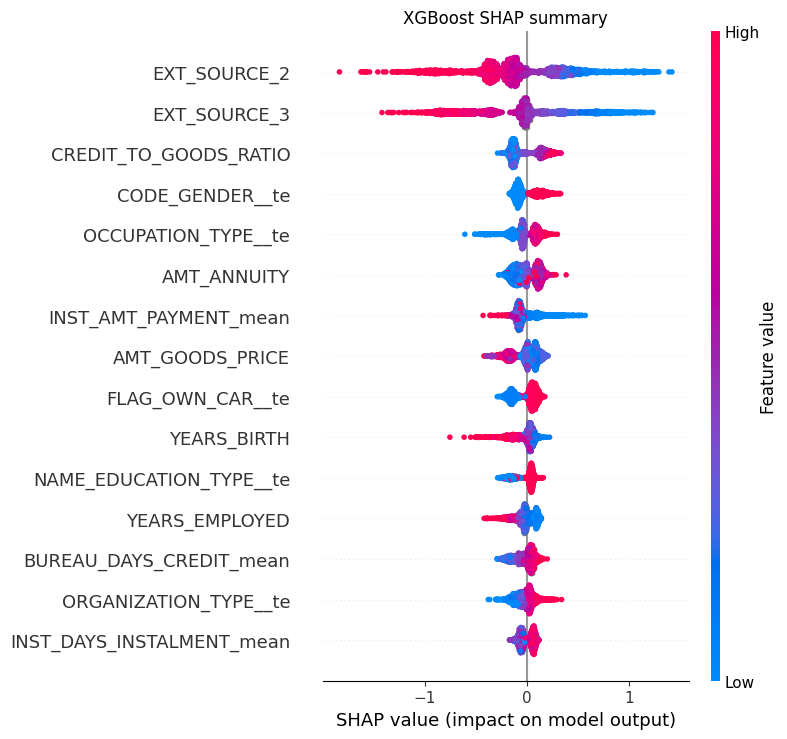

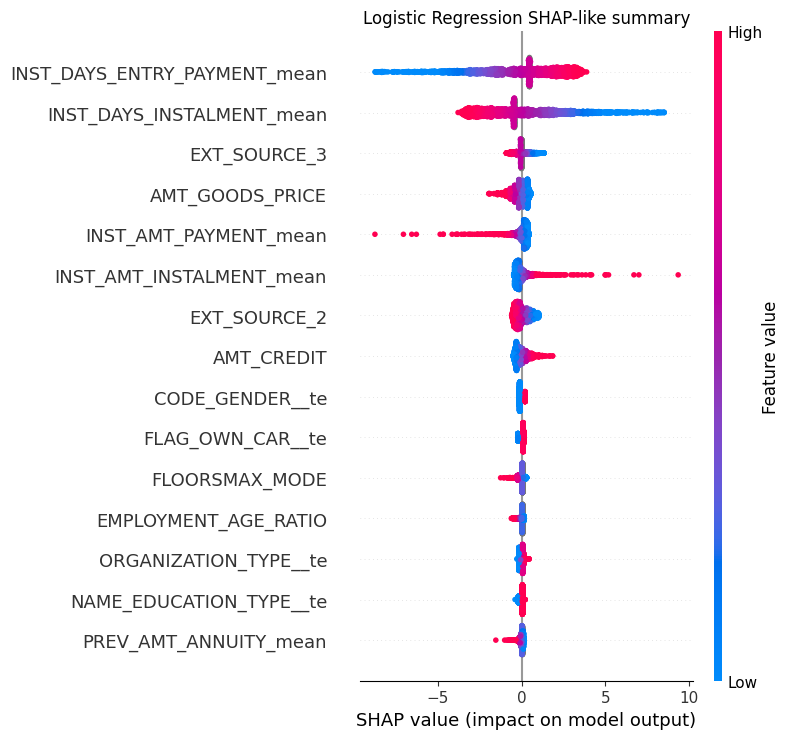

Building: stage3_global_lime_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_global_lime_352e0f6c14.joblib
Global LIME summary


,model,feature,mean_abs_lime_weight,mean_lime_weight,rules_cnt
21,LogisticRegression,INST_DAYS_ENTRY_PAYMENT_mean,0.246682,0.045349,40
22,LogisticRegression,INST_DAYS_INSTALMENT_mean,0.241155,-0.046916,40
19,LogisticRegression,INST_AMT_INSTALMENT_mean,0.077530,0.015613,31
13,LogisticRegression,EXT_SOURCE_3,0.075979,0.008302,21
20,LogisticRegression,INST_AMT_PAYMENT_mean,0.068984,-0.007284,33
12,LogisticRegression,EXT_SOURCE_2,0.059432,0.013975,22
2,LogisticRegression,AMT_GOODS_PRICE,0.057367,0.003269,27
1,LogisticRegression,AMT_CREDIT,0.056541,-0.007270,27
17,LogisticRegression,FLOORSMAX_MODE,0.045883,0.027538,38
23,LogisticRegression,NAME_EDUCATION_TYPE__te,0.038955,-0.026898,5


Local observation index: 116554
True TARGET: 1
XGBoost predicted risk: 0.93418
Logistic predicted risk: 0.93663
Local SHAP


,feature,local_shap_xgb,local_shap_logit,abs_local_shap_xgb,abs_local_shap_logit
3,EXT_SOURCE_2,0.963067,0.912733,0.963067,0.912733
4,EXT_SOURCE_3,0.961255,1.192321,0.961255,1.192321
0,CREDIT_TO_GOODS_RATIO,-0.109628,-0.003056,0.109628,0.003056
10,PREV_AMT_ANNUITY_mean,0.085383,0.064151,0.085383,0.064151
14,YEARS_BIRTH,0.079154,0.049382,0.079154,0.049382
24,PREV_AMT_ANNUITY_max,0.075591,0.026774,0.075591,0.026774
15,neighbor_target_mean_5,0.072693,0.116611,0.072693,0.116611
11,FLAG_OWN_CAR__te,-0.072591,-0.191219,0.072591,0.191219
1,CODE_GENDER__te,0.072451,0.204055,0.072451,0.204055
20,AMT_ANNUITY,0.071807,0.015298,0.071807,0.015298


Local LIME Logistic Regression


,lime_rule,lime_weight_logit
0,INST_DAYS_ENTRY_PAYMENT_mean > -451.25,0.398086
1,INST_DAYS_INSTALMENT_mean > -439.00,-0.381476
2,EXT_SOURCE_3 <= 0.42,0.108144
3,EXT_SOURCE_2 <= 0.39,0.073335
4,INST_AMT_INSTALMENT_mean <= 8065.32,-0.061410
5,7729.18 < INST_AMT_PAYMENT_mean <= 12295.56,0.054194
6,518562.00 < AMT_CREDIT <= 808650.00,0.034311
7,DEF_30_CNT_SOCIAL_CIRCLE > 0.00,0.034135
8,FLOORSMAX_MEDI <= 0.17,-0.029677
9,1.00 < CREDIT_TO_GOODS_RATIO <= 1.12,-0.026461


Local LIME XGBoost


,lime_rule,lime_weight_xgb
0,EXT_SOURCE_3 <= 0.42,0.177581
1,EXT_SOURCE_2 <= 0.39,0.156986
2,ORGANIZATION_TYPE__te > 0.09,0.037155
3,0.07 < WALLSMATERIAL_MODE__te <= 0.08,0.033361
4,1.00 < CREDIT_TO_GOODS_RATIO <= 1.12,-0.030426
5,25078.50 < AMT_ANNUITY <= 34696.12,0.028319
6,0.00 < FLAG_DOCUMENT_3 <= 1.00,0.026814
7,INST_AMT_INSTALMENT_mean <= 8065.32,-0.026260
8,FLAG_OWN_CAR__te <= 0.07,-0.025706
9,YEARS_BIRTH <= 33.87,0.020759


,comparison,intersection_cnt,union_cnt,jaccard_similarity
0,SHAP XGBoost vs SHAP LogisticRegression,9,21,0.428571
1,LIME XGBoost vs LIME LogisticRegression,7,23,0.304348
2,SHAP XGBoost vs LIME XGBoost,13,17,0.764706
3,SHAP LogisticRegression vs LIME LogisticRegres...,11,19,0.578947



Вывод по шагу 1.

Для интерпретации выбраны две разные модели:
1. Logistic Regression как линейная и хорошо объяснимая модель.
2. XGBoost как нелинейная модель, способная учитывать взаимодействия признаков.

По holdout ROC-AUC лучшей моделью стала: XGBoost.

Глобальные SHAP-результаты показывают, какие признаки в среднем сильнее всего влияют на прогноз.
LIME использован как независимая проверка интерпретации через локальные аппроксимации модели.

Сравнение топ-признаков показывает, насколько устойчивы выводы:
если пересечение между SHAP и LIME высокое, значит ключевые факторы риска стабильны;
если пересечение низкое, значит модель использует нелинейные зависимости и локальные правила отличаются от глобальной картины.

Локальное объяснение построено для наблюдения с максимальным прогнозным риском.
Для него отдельно показаны SHAP-вклады и LIME-правила.



In [ ]:
# - место под выбор двух моделей
# - место под глобальные shap графики
# - место под глобальные lime результаты
# - место под локальное объяснение одного наблюдения
# - место под сравнение интерпретаций
# - место под выводы

# =============================================================================
# ЭТАП 3. ШАГ 1.
# Интерпретация двух моделей: Logistic Regression и XGBoost
# SHAP, LIME, локальное объяснение, сравнение интерпретаций
# =============================================================================

import os
import json
import hashlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import joblib

try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

try:
    import lime
    import lime.lime_tabular
except ImportError:
    !pip -q install lime
    import lime
    import lime.lime_tabular

try:
    import xgboost as xgb
except ImportError:
    !pip -q install xgboost
    import xgboost as xgb


# =============================================================================
# 0. КЕШ
# =============================================================================

RANDOM_STATE = 42

if os.path.exists("/content/drive/MyDrive"):
    STAGE3_CACHE_DIR = "/content/drive/MyDrive/home_credit_project_cache/stage3"
else:
    STAGE3_CACHE_DIR = "/content/home_credit_project_cache/stage3"

os.makedirs(STAGE3_CACHE_DIR, exist_ok=True)

def stage3_cache_path(name):
    return os.path.join(STAGE3_CACHE_DIR, name)

def get_or_build_cache(name, builder_func, force=False):
    path = stage3_cache_path(name)

    if os.path.exists(path) and not force:
        print(f"Loaded from cache: {path}")
        return joblib.load(path)

    print(f"Building: {name}")
    obj = builder_func()
    joblib.dump(obj, path)
    print(f"Saved to cache: {path}")
    return obj


# =============================================================================
# 1. ПОДГОТОВКА ДАННЫХ
# =============================================================================

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

if "final_stage2_train" in globals():
    stage3_base_train = final_stage2_train.copy()
else:
    stage3_base_train = stage2_train[[TARGET_COL, ID_COL] + FINAL_STAGE2_FEATURES].copy()

stage3_feature_cols = [
    c for c in stage3_base_train.columns
    if c not in [TARGET_COL, ID_COL]
    and pd.api.types.is_numeric_dtype(stage3_base_train[c])
    and stage3_base_train[c].nunique(dropna=True) > 1
]

# Берём не слишком много признаков, чтобы SHAP и LIME не считались бесконечно
STAGE3_TOP_FEATURES = 40
stage3_feature_cols = stage3_feature_cols[:STAGE3_TOP_FEATURES]

X_stage3_all = stage3_base_train[stage3_feature_cols].replace([np.inf, -np.inf], np.nan)
y_stage3_all = stage3_base_train[TARGET_COL].astype(int)

# Для этапа интерпретации достаточно сэмпла.
# Так ноутбук не будет каждый раз зависать на 300k строках.
STAGE3_MAX_ROWS = 60000

if len(X_stage3_all) > STAGE3_MAX_ROWS:
    stage3_idx, _ = train_test_split(
        X_stage3_all.index,
        train_size=STAGE3_MAX_ROWS,
        stratify=y_stage3_all,
        random_state=RANDOM_STATE
    )
    X_stage3 = X_stage3_all.loc[stage3_idx].copy()
    y_stage3 = y_stage3_all.loc[stage3_idx].copy()
else:
    X_stage3 = X_stage3_all.copy()
    y_stage3 = y_stage3_all.copy()

stage3_signature = hashlib.md5(
    (str(len(X_stage3)) + "|" + "|".join(stage3_feature_cols)).encode()
).hexdigest()[:10]

print(f"Stage 3 rows: {len(X_stage3):,}")
print(f"Stage 3 features: {len(stage3_feature_cols)}")
print(f"Target rate: {y_stage3.mean():.5f}")
print(f"Cache signature: {stage3_signature}")

X_train_s3, X_valid_s3, y_train_s3, y_valid_s3 = train_test_split(
    X_stage3,
    y_stage3,
    test_size=0.25,
    stratify=y_stage3,
    random_state=RANDOM_STATE
)


# =============================================================================
# 2. ВЫБОР ДВУХ МОДЕЛЕЙ
# =============================================================================

def make_xgb_model(y_train):
    pos = max((y_train == 1).sum(), 1)
    neg = max((y_train == 0).sum(), 1)

    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=20,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        scale_pos_weight=neg / pos
    )

def build_stage3_models():
    # Линейная модель
    imputer_linear = SimpleImputer(strategy="median")
    scaler_linear = StandardScaler()

    X_train_imp = imputer_linear.fit_transform(X_train_s3)
    X_train_scaled = scaler_linear.fit_transform(X_train_imp)

    logit_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    logit_model.fit(X_train_scaled, y_train_s3)

    # Бустинг
    imputer_xgb = SimpleImputer(strategy="median")
    X_train_xgb = imputer_xgb.fit_transform(X_train_s3)

    xgb_model = make_xgb_model(y_train_s3)
    xgb_model.fit(X_train_xgb, y_train_s3)

    return {
        "imputer_linear": imputer_linear,
        "scaler_linear": scaler_linear,
        "logit_model": logit_model,
        "linear_center": X_train_scaled.mean(axis=0),
        "imputer_xgb": imputer_xgb,
        "xgb_model": xgb_model,
        "feature_cols": stage3_feature_cols,
    }

stage3_models = get_or_build_cache(
    f"stage3_models_{stage3_signature}.joblib",
    build_stage3_models,
    force=False
)

# Метрики на holdout
X_valid_linear = stage3_models["scaler_linear"].transform(
    stage3_models["imputer_linear"].transform(X_valid_s3)
)
pred_logit = stage3_models["logit_model"].predict_proba(X_valid_linear)[:, 1]

X_valid_xgb = stage3_models["imputer_xgb"].transform(X_valid_s3)
pred_xgb = stage3_models["xgb_model"].predict_proba(X_valid_xgb)[:, 1]

stage3_model_compare = pd.DataFrame({
    "model": ["LogisticRegression", "XGBoost"],
    "holdout_roc_auc": [
        roc_auc_score(y_valid_s3, pred_logit),
        roc_auc_score(y_valid_s3, pred_xgb)
    ],
    "model_type": ["linear", "tree_boosting"]
})

display(stage3_model_compare)


# =============================================================================
# 3. ГЛОБАЛЬНЫЕ SHAP ГРАФИКИ
# =============================================================================

def get_xgb_shap_values(model, X_values, feature_names):
    dmat = xgb.DMatrix(X_values, feature_names=feature_names)
    contribs = model.get_booster().predict(dmat, pred_contribs=True)
    return contribs[:, :-1]

def get_linear_shap_like_values(model_pack, X_df):
    X_imp = model_pack["imputer_linear"].transform(X_df)
    X_scaled = model_pack["scaler_linear"].transform(X_imp)
    coef = model_pack["logit_model"].coef_[0]
    center = model_pack["linear_center"]
    return (X_scaled - center) * coef

SHAP_SAMPLE_SIZE = 2500

if len(X_valid_s3) > SHAP_SAMPLE_SIZE:
    shap_sample_idx = X_valid_s3.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE).index
else:
    shap_sample_idx = X_valid_s3.index

stage3_shap_sample_X = X_valid_s3.loc[shap_sample_idx].copy()

def build_stage3_shap_values():
    X_xgb_imp = stage3_models["imputer_xgb"].transform(stage3_shap_sample_X)

    xgb_shap_values = get_xgb_shap_values(
        stage3_models["xgb_model"],
        X_xgb_imp,
        stage3_feature_cols
    )

    linear_shap_values = get_linear_shap_like_values(
        stage3_models,
        stage3_shap_sample_X
    )

    return {
        "xgb_shap_values": xgb_shap_values,
        "linear_shap_values": linear_shap_values,
        "sample_index": stage3_shap_sample_X.index.tolist()
    }

stage3_shap_obj = get_or_build_cache(
    f"stage3_global_shap_{stage3_signature}.joblib",
    build_stage3_shap_values,
    force=False
)

stage3_shap_xgb_values = stage3_shap_obj["xgb_shap_values"]
stage3_shap_linear_values = stage3_shap_obj["linear_shap_values"]

stage3_shap_xgb_importance = (
    pd.Series(np.abs(stage3_shap_xgb_values).mean(axis=0), index=stage3_feature_cols)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "mean_abs_shap_xgb"})
)

stage3_shap_linear_importance = (
    pd.Series(np.abs(stage3_shap_linear_values).mean(axis=0), index=stage3_feature_cols)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "mean_abs_shap_logit"})
)

print("Top SHAP features XGBoost")
display(stage3_shap_xgb_importance.head(15))

print("Top SHAP features Logistic Regression")
display(stage3_shap_linear_importance.head(15))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    stage3_shap_xgb_values,
    stage3_shap_sample_X,
    feature_names=stage3_feature_cols,
    max_display=15,
    show=False
)
plt.title("XGBoost SHAP summary")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    stage3_shap_linear_values,
    stage3_shap_sample_X,
    feature_names=stage3_feature_cols,
    max_display=15,
    show=False
)
plt.title("Logistic Regression SHAP-like summary")
plt.tight_layout()
plt.show()


# =============================================================================
# 4. ГЛОБАЛЬНЫЕ LIME РЕЗУЛЬТАТЫ
# =============================================================================

def predict_logit_for_lime(arr):
    arr_df = pd.DataFrame(arr, columns=stage3_feature_cols)
    arr_imp = stage3_models["imputer_linear"].transform(arr_df)
    arr_scaled = stage3_models["scaler_linear"].transform(arr_imp)
    return stage3_models["logit_model"].predict_proba(arr_scaled)

def predict_xgb_for_lime(arr):
    arr_df = pd.DataFrame(arr, columns=stage3_feature_cols)
    arr_imp = stage3_models["imputer_xgb"].transform(arr_df)
    return stage3_models["xgb_model"].predict_proba(arr_imp)

X_lime_train_imp = pd.DataFrame(
    stage3_models["imputer_linear"].transform(X_train_s3),
    columns=stage3_feature_cols
)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_train_imp.values,
    feature_names=stage3_feature_cols,
    class_names=["no_default", "default"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

def extract_feature_from_lime_rule(rule, feature_cols):
    for f in sorted(feature_cols, key=len, reverse=True):
        if f in rule:
            return f
    return rule

def build_global_lime_summary():
    sample_for_lime = stage3_shap_sample_X.head(40).copy()
    sample_for_lime_imp = pd.DataFrame(
        stage3_models["imputer_linear"].transform(sample_for_lime),
        columns=stage3_feature_cols,
        index=sample_for_lime.index
    )

    rows = []

    for model_name, pred_func in [
        ("LogisticRegression", predict_logit_for_lime),
        ("XGBoost", predict_xgb_for_lime)
    ]:
        for idx in sample_for_lime_imp.index:
            exp = lime_explainer.explain_instance(
                sample_for_lime_imp.loc[idx].values,
                pred_func,
                num_features=10,
                labels=[1]
            )

            for rule, weight in exp.as_list(label=1):
                rows.append({
                    "model": model_name,
                    "row_id": idx,
                    "lime_rule": rule,
                    "feature": extract_feature_from_lime_rule(rule, stage3_feature_cols),
                    "weight": weight,
                    "abs_weight": abs(weight)
                })

    lime_raw = pd.DataFrame(rows)

    lime_summary = (
        lime_raw
        .groupby(["model", "feature"], as_index=False)
        .agg(
            mean_abs_lime_weight=("abs_weight", "mean"),
            mean_lime_weight=("weight", "mean"),
            rules_cnt=("lime_rule", "count")
        )
        .sort_values(["model", "mean_abs_lime_weight"], ascending=[True, False])
    )

    return {
        "lime_raw": lime_raw,
        "lime_summary": lime_summary
    }

stage3_lime_obj = get_or_build_cache(
    f"stage3_global_lime_{stage3_signature}.joblib",
    build_global_lime_summary,
    force=False
)

stage3_lime_raw = stage3_lime_obj["lime_raw"]
stage3_lime_summary = stage3_lime_obj["lime_summary"]

print("Global LIME summary")
display(stage3_lime_summary.groupby("model").head(15))


# =============================================================================
# 5. ЛОКАЛЬНОЕ ОБЪЯСНЕНИЕ ОДНОГО НАБЛЮДЕНИЯ
# =============================================================================

# Берём наблюдение с самым высоким прогнозным риском по XGBoost
stage3_local_idx = X_valid_s3.index[np.argmax(pred_xgb)]
stage3_local_x = X_valid_s3.loc[[stage3_local_idx]]

local_x_imp = pd.DataFrame(
    stage3_models["imputer_linear"].transform(stage3_local_x),
    columns=stage3_feature_cols
)

local_lime_logit = lime_explainer.explain_instance(
    local_x_imp.iloc[0].values,
    predict_logit_for_lime,
    num_features=10,
    labels=[1]
)

local_lime_xgb = lime_explainer.explain_instance(
    local_x_imp.iloc[0].values,
    predict_xgb_for_lime,
    num_features=10,
    labels=[1]
)

stage3_local_lime_logit = pd.DataFrame(
    local_lime_logit.as_list(label=1),
    columns=["lime_rule", "lime_weight_logit"]
)

stage3_local_lime_xgb = pd.DataFrame(
    local_lime_xgb.as_list(label=1),
    columns=["lime_rule", "lime_weight_xgb"]
)

# Локальный SHAP для XGBoost
local_xgb_imp = stage3_models["imputer_xgb"].transform(stage3_local_x)
local_xgb_shap = get_xgb_shap_values(
    stage3_models["xgb_model"],
    local_xgb_imp,
    stage3_feature_cols
)[0]

# Локальный вклад линейной модели
local_linear_shap = get_linear_shap_like_values(
    stage3_models,
    stage3_local_x
)[0]

stage3_local_shap = pd.DataFrame({
    "feature": stage3_feature_cols,
    "local_shap_xgb": local_xgb_shap,
    "local_shap_logit": local_linear_shap,
    "abs_local_shap_xgb": np.abs(local_xgb_shap),
    "abs_local_shap_logit": np.abs(local_linear_shap),
}).sort_values("abs_local_shap_xgb", ascending=False)

print(f"Local observation index: {stage3_local_idx}")
print(f"True TARGET: {int(y_valid_s3.loc[stage3_local_idx])}")
print(f"XGBoost predicted risk: {stage3_models['xgb_model'].predict_proba(local_xgb_imp)[:, 1][0]:.5f}")
print(f"Logistic predicted risk: {predict_logit_for_lime(local_x_imp.values)[:, 1][0]:.5f}")

print("Local SHAP")
display(stage3_local_shap.head(15))

print("Local LIME Logistic Regression")
display(stage3_local_lime_logit)

print("Local LIME XGBoost")
display(stage3_local_lime_xgb)


# =============================================================================
# 6. СРАВНЕНИЕ ИНТЕРПРЕТАЦИЙ
# =============================================================================

top_shap_xgb = set(stage3_shap_xgb_importance.head(15)["feature"])
top_shap_logit = set(stage3_shap_linear_importance.head(15)["feature"])

top_lime_xgb = set(
    stage3_lime_summary
    .query("model == 'XGBoost'")
    .head(15)["feature"]
)

top_lime_logit = set(
    stage3_lime_summary
    .query("model == 'LogisticRegression'")
    .head(15)["feature"]
)

stage3_interpretation_compare = pd.DataFrame({
    "comparison": [
        "SHAP XGBoost vs SHAP LogisticRegression",
        "LIME XGBoost vs LIME LogisticRegression",
        "SHAP XGBoost vs LIME XGBoost",
        "SHAP LogisticRegression vs LIME LogisticRegression",
    ],
    "intersection_cnt": [
        len(top_shap_xgb & top_shap_logit),
        len(top_lime_xgb & top_lime_logit),
        len(top_shap_xgb & top_lime_xgb),
        len(top_shap_logit & top_lime_logit),
    ],
    "union_cnt": [
        len(top_shap_xgb | top_shap_logit),
        len(top_lime_xgb | top_lime_logit),
        len(top_shap_xgb | top_lime_xgb),
        len(top_shap_logit | top_lime_logit),
    ],
})

stage3_interpretation_compare["jaccard_similarity"] = (
    stage3_interpretation_compare["intersection_cnt"]
    / stage3_interpretation_compare["union_cnt"]
)

display(stage3_interpretation_compare)


# =============================================================================
# 7. ВЫВОДЫ
# =============================================================================

best_model_name = (
    stage3_model_compare
    .sort_values("holdout_roc_auc", ascending=False)
    .iloc[0]["model"]
)

print(f"""
Вывод по шагу 1.

Для интерпретации выбраны две разные модели:
1. Logistic Regression как линейная и хорошо объяснимая модель.
2. XGBoost как нелинейная модель, способная учитывать взаимодействия признаков.

По holdout ROC-AUC лучшей моделью стала: {best_model_name}.

Глобальные SHAP-результаты показывают, какие признаки в среднем сильнее всего влияют на прогноз.
LIME использован как независимая проверка интерпретации через локальные аппроксимации модели.

Сравнение топ-признаков показывает, насколько устойчивы выводы:
если пересечение между SHAP и LIME высокое, значит ключевые факторы риска стабильны;
если пересечение низкое, значит модель использует нелинейные зависимости и локальные правила отличаются от глобальной картины.

Локальное объяснение построено для наблюдения с максимальным прогнозным риском.
Для него отдельно показаны SHAP-вклады и LIME-правила.
""")

### Шаг 2. построить shap эмбеддинги и проанализировать сдвиги
- [x] получите shap эмбеддинги и оформите их в виде функций
- [x] выявите сдвиги и аномалии
- [x] очистите данные и переобучите модель
- [x] сравните метрики до и после
- [x] проведите кластеризацию shap эмбеддингов
- [x] добавьте переменную cluster и проверьте, даёт ли она прирост

Building: stage3_shap_embeddings_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_shap_embeddings_352e0f6c14.joblib
SHAP embeddings shape: (60000, 40)


,shap__CREDIT_TO_GOODS_RATIO,shap__CODE_GENDER__te,shap__REGION_RATING_CLIENT_W_CITY,shap__EXT_SOURCE_2,shap__EXT_SOURCE_3,shap__REGION_RATING_CLIENT,shap__REGION_POPULATION_RELATIVE,shap__OCCUPATION_TYPE__te,shap__FLAG_DOCUMENT_3,shap__AMT_GOODS_PRICE,...,shap__ORGANIZATION_TYPE__te,shap__INST_DAYS_ENTRY_PAYMENT_mean,shap__INST_DAYS_INSTALMENT_mean,shap__FLAG_EMP_PHONE,shap__anomaly_flag_zscore,shap__ANNUITY_TO_INCOME_RATIO,shap__YEARS_LAST_PHONE_CHANGE,shap__DEF_30_CNT_SOCIAL_CIRCLE,shap__EMERGENCYSTATE_MODE__te,shap__INST_AMT_INSTALMENT_mean
49856,-0.133723,-0.079401,-0.000517,-0.041203,-0.050130,0.001322,-0.016882,0.088360,-0.101618,0.078336,...,0.031864,0.020535,0.018159,0.0,-0.001877,-0.073394,0.032565,-0.017456,-0.000072,-0.096801
86506,0.145443,0.097663,-0.001813,1.115251,0.019604,0.002097,0.019289,-0.037674,0.025269,0.124664,...,0.036313,0.037179,0.036728,0.0,-0.001227,0.008284,0.009996,-0.013904,-0.000409,0.021399
201098,-0.092907,0.251958,-0.000427,-0.240989,0.022109,-0.000968,0.033167,-0.053781,-0.040583,0.032224,...,-0.077920,-0.000678,0.100548,0.0,-0.001798,0.009319,0.043685,-0.015210,0.001440,-0.029142
162803,-0.162982,-0.061876,-0.053316,0.511762,-0.393671,-0.025777,-0.043103,-0.178698,0.022918,0.060672,...,-0.305330,0.018122,0.051184,0.0,-0.001261,-0.072494,0.016515,-0.010963,-0.006978,-0.048604
149127,-0.147020,-0.060249,-0.003653,-0.107769,-0.016006,0.004069,0.004774,0.071499,0.031811,-0.002839,...,0.070827,0.029971,0.086539,0.0,-0.001224,-0.038758,0.010096,-0.016346,-0.000610,0.082702


Building: stage3_shap_pca_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_shap_pca_352e0f6c14.joblib
PCA explained variance ratio:
[0.372595   0.31469515]


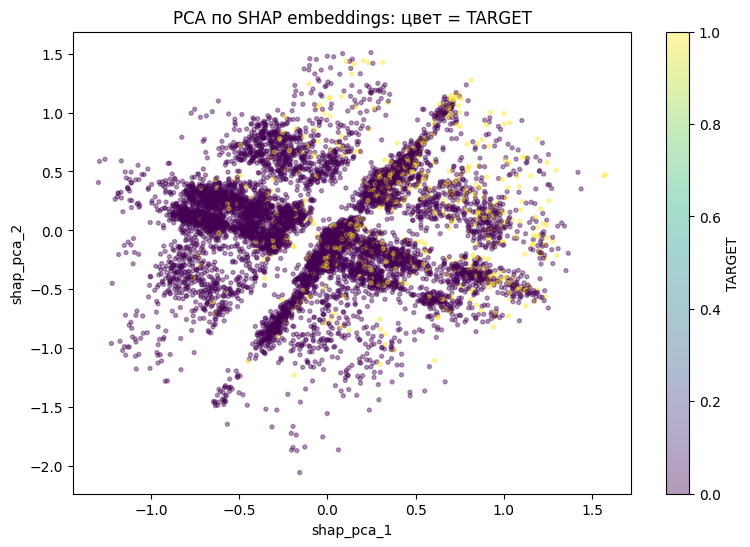

Building: stage3_kmeans_clusters_352e0f6c14.joblib
Saved to cache: /content/home_credit_project_cache/stage3/stage3_kmeans_clusters_352e0f6c14.joblib


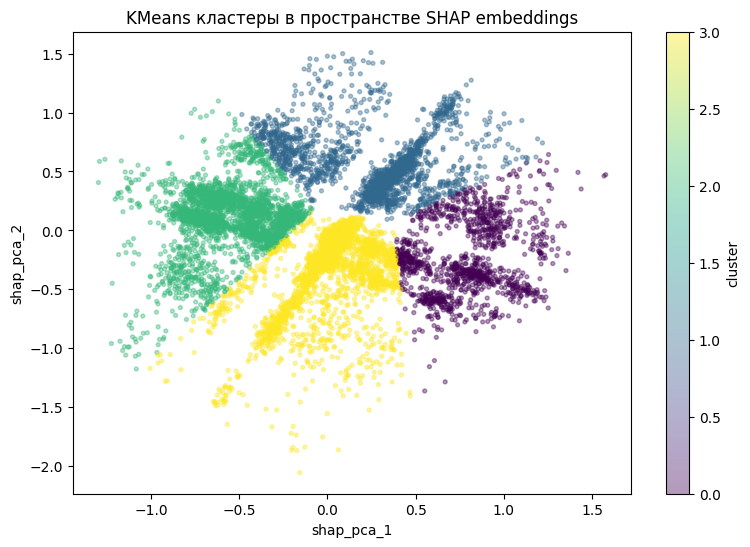

,shap_cluster,users_cnt,target_rate,avg_xgb_pred,shap_pca_1_mean,shap_pca_2_mean
0,0,7541,0.180745,0.629345,0.787932,-0.239707
1,1,12427,0.129878,0.539971,0.246854,0.565254
3,3,23210,0.059285,0.358582,0.012990,-0.303274
2,2,16822,0.029188,0.218785,-0.553498,0.108323


Топ признаков, которые отличают каждый кластер


,shap_cluster,feature,cluster_mean_shap,global_mean_shap,abs_diff
0,0,EXT_SOURCE_3,0.686756,-0.121667,0.808423
1,0,EXT_SOURCE_2,0.029785,-0.119601,0.149386
2,0,BUREAU_DAYS_CREDIT_mean,0.015405,-0.015740,0.031145
3,0,YEARS_BIRTH,0.003207,-0.017122,0.020329
4,0,AMT_GOODS_PRICE,0.007847,-0.011820,0.019667
5,1,EXT_SOURCE_2,0.494337,-0.119601,0.613938
6,1,EXT_SOURCE_3,-0.164026,-0.121667,0.042358
7,1,AMT_GOODS_PRICE,0.005728,-0.011820,0.017548
8,1,OCCUPATION_TYPE__te,-0.001665,-0.018581,0.016916
9,1,NAME_EDUCATION_TYPE__te,0.003115,-0.012230,0.015346


,dataset,roc_auc_mean,roc_auc_std,n_features,delta_vs_original
0,original_features,0.740192,0.001660,40,0.000000
1,original_features_plus_shap_cluster,0.741748,0.001372,44,0.001556



Вывод по шагу 2.

SHAP embeddings построены как векторы вкладов признаков в прогноз XGBoost.
То есть каждая строка описана не исходными значениями признаков, а тем,
как эти признаки повлияли на индивидуальный прогноз модели.

PCA показал, что SHAP embeddings можно сжать до двух измерений для визуальной диагностики.
После этого KMeans выделил 4 кластера клиентов.

Разница target rate между самым рискованным и самым спокойным кластером:
0.15156.

Это значит, что кластеры в пространстве SHAP действительно разделяют клиентов
по характеру модельного риска.

Добавление cluster feature к исходным признакам изменило ROC-AUC:
0.74019 → 0.74175
delta = +0.00156.

Важно: cluster feature построен на SHAP текущей модели.
Для строгой финальной оценки лучше использовать out-of-fold SHAP embeddings,
что делается в следующем шаге.



In [ ]:
# - место под shap embeddings
# - место под pca, umap или tsne
# - место под k means, dbscan или иерархическую кластеризацию
# - место под интерпретацию кластеров
# - место под переобучение модели с cluster feature
# - место под выводы

# =============================================================================
# ЭТАП 3. ШАГ 2.
# SHAP embeddings, PCA, KMeans, интерпретация кластеров,
# переобучение модели с cluster feature
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import joblib


# =============================================================================
# 1. SHAP EMBEDDINGS
# =============================================================================

def build_stage3_shap_embeddings():
    X_imp = stage3_models["imputer_xgb"].transform(X_stage3[stage3_feature_cols])

    shap_values = get_xgb_shap_values(
        stage3_models["xgb_model"],
        X_imp,
        stage3_feature_cols
    )

    shap_embeddings = pd.DataFrame(
        shap_values,
        index=X_stage3.index,
        columns=[f"shap__{c}" for c in stage3_feature_cols]
    )

    xgb_pred = stage3_models["xgb_model"].predict_proba(X_imp)[:, 1]

    return {
        "shap_embeddings": shap_embeddings,
        "xgb_pred": xgb_pred
    }

stage3_embeddings_obj = get_or_build_cache(
    f"stage3_shap_embeddings_{stage3_signature}.joblib",
    build_stage3_shap_embeddings,
    force=False
)

stage3_shap_embeddings = stage3_embeddings_obj["shap_embeddings"]
stage3_xgb_pred = stage3_embeddings_obj["xgb_pred"]

print(f"SHAP embeddings shape: {stage3_shap_embeddings.shape}")
display(stage3_shap_embeddings.head())


# =============================================================================
# 2. PCA ПО SHAP EMBEDDINGS
# =============================================================================

def build_stage3_pca():
    imputer = SimpleImputer(strategy="median")
    shap_imp = imputer.fit_transform(stage3_shap_embeddings)

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_values = pca.fit_transform(shap_imp)

    pca_df = pd.DataFrame(
        pca_values,
        index=stage3_shap_embeddings.index,
        columns=["shap_pca_1", "shap_pca_2"]
    )

    return {
        "imputer": imputer,
        "pca": pca,
        "pca_df": pca_df,
        "explained_variance_ratio": pca.explained_variance_ratio_
    }

stage3_pca_obj = get_or_build_cache(
    f"stage3_shap_pca_{stage3_signature}.joblib",
    build_stage3_pca,
    force=False
)

stage3_shap_pca_df = stage3_pca_obj["pca_df"]

print("PCA explained variance ratio:")
print(stage3_pca_obj["explained_variance_ratio"])

plot_pca_df = stage3_shap_pca_df.copy()
plot_pca_df[TARGET_COL] = y_stage3.loc[plot_pca_df.index].values
plot_pca_df["xgb_pred"] = stage3_xgb_pred

sample_plot = plot_pca_df.sample(
    n=min(10000, len(plot_pca_df)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 6))
plt.scatter(
    sample_plot["shap_pca_1"],
    sample_plot["shap_pca_2"],
    c=sample_plot[TARGET_COL],
    alpha=0.4,
    s=8
)
plt.title("PCA по SHAP embeddings: цвет = TARGET")
plt.xlabel("shap_pca_1")
plt.ylabel("shap_pca_2")
plt.colorbar(label="TARGET")
plt.show()


# =============================================================================
# 3. KMEANS КЛАСТЕРИЗАЦИЯ
# =============================================================================

N_CLUSTERS = 4

def build_stage3_clusters():
    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10
    )

    clusters = kmeans.fit_predict(stage3_shap_pca_df[["shap_pca_1", "shap_pca_2"]])

    cluster_df = pd.DataFrame({
        TARGET_COL: y_stage3.loc[stage3_shap_pca_df.index].values,
        "xgb_pred": stage3_xgb_pred,
        "shap_cluster": clusters,
        "shap_pca_1": stage3_shap_pca_df["shap_pca_1"].values,
        "shap_pca_2": stage3_shap_pca_df["shap_pca_2"].values,
    }, index=stage3_shap_pca_df.index)

    return {
        "kmeans": kmeans,
        "cluster_df": cluster_df
    }

stage3_cluster_obj = get_or_build_cache(
    f"stage3_kmeans_clusters_{stage3_signature}.joblib",
    build_stage3_clusters,
    force=False
)

stage3_cluster_df = stage3_cluster_obj["cluster_df"]

sample_plot = stage3_cluster_df.sample(
    n=min(10000, len(stage3_cluster_df)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(9, 6))
plt.scatter(
    sample_plot["shap_pca_1"],
    sample_plot["shap_pca_2"],
    c=sample_plot["shap_cluster"],
    alpha=0.4,
    s=8
)
plt.title("KMeans кластеры в пространстве SHAP embeddings")
plt.xlabel("shap_pca_1")
plt.ylabel("shap_pca_2")
plt.colorbar(label="cluster")
plt.show()


# =============================================================================
# 4. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ
# =============================================================================

stage3_cluster_report = (
    stage3_cluster_df
    .groupby("shap_cluster")
    .agg(
        users_cnt=(TARGET_COL, "size"),
        target_rate=(TARGET_COL, "mean"),
        avg_xgb_pred=("xgb_pred", "mean"),
        shap_pca_1_mean=("shap_pca_1", "mean"),
        shap_pca_2_mean=("shap_pca_2", "mean")
    )
    .reset_index()
    .sort_values("target_rate", ascending=False)
)

display(stage3_cluster_report)

cluster_top_rows = []

global_shap_mean = stage3_shap_embeddings.mean()

for cl in sorted(stage3_cluster_df["shap_cluster"].unique()):
    idx = stage3_cluster_df.index[stage3_cluster_df["shap_cluster"] == cl]
    cluster_shap_mean = stage3_shap_embeddings.loc[idx].mean()
    diff = (cluster_shap_mean - global_shap_mean).abs().sort_values(ascending=False)

    for shap_feature in diff.head(5).index:
        cluster_top_rows.append({
            "shap_cluster": cl,
            "feature": shap_feature.replace("shap__", ""),
            "cluster_mean_shap": cluster_shap_mean[shap_feature],
            "global_mean_shap": global_shap_mean[shap_feature],
            "abs_diff": diff[shap_feature]
        })

stage3_cluster_interpretation = pd.DataFrame(cluster_top_rows)

print("Топ признаков, которые отличают каждый кластер")
display(stage3_cluster_interpretation)


# =============================================================================
# 5. ПЕРЕОБУЧЕНИЕ МОДЕЛИ С CLUSTER FEATURE
# =============================================================================

def stage3_cv_auc_numeric(X_df, y_series, n_splits=3):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_df,
        y_series,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    return scores.mean(), scores.std()

X_original_for_cluster_test = X_stage3[stage3_feature_cols].copy()

cluster_dummies = pd.get_dummies(
    stage3_cluster_df["shap_cluster"],
    prefix="shap_cluster",
    drop_first=False
)

X_with_cluster = pd.concat(
    [
        X_original_for_cluster_test.loc[stage3_cluster_df.index],
        cluster_dummies
    ],
    axis=1
)

original_cluster_mean, original_cluster_std = stage3_cv_auc_numeric(
    X_original_for_cluster_test.loc[stage3_cluster_df.index],
    y_stage3.loc[stage3_cluster_df.index]
)

with_cluster_mean, with_cluster_std = stage3_cv_auc_numeric(
    X_with_cluster,
    y_stage3.loc[X_with_cluster.index]
)

stage3_cluster_feature_compare = pd.DataFrame({
    "dataset": ["original_features", "original_features_plus_shap_cluster"],
    "roc_auc_mean": [original_cluster_mean, with_cluster_mean],
    "roc_auc_std": [original_cluster_std, with_cluster_std],
    "n_features": [
        X_original_for_cluster_test.shape[1],
        X_with_cluster.shape[1]
    ],
    "delta_vs_original": [
        0,
        with_cluster_mean - original_cluster_mean
    ]
})

display(stage3_cluster_feature_compare)


# =============================================================================
# 6. ВЫВОДЫ
# =============================================================================

cluster_gap = (
    stage3_cluster_report["target_rate"].max()
    - stage3_cluster_report["target_rate"].min()
)

print(f"""
Вывод по шагу 2.

SHAP embeddings построены как векторы вкладов признаков в прогноз XGBoost.
То есть каждая строка описана не исходными значениями признаков, а тем,
как эти признаки повлияли на индивидуальный прогноз модели.

PCA показал, что SHAP embeddings можно сжать до двух измерений для визуальной диагностики.
После этого KMeans выделил {N_CLUSTERS} кластера клиентов.

Разница target rate между самым рискованным и самым спокойным кластером:
{cluster_gap:.5f}.

Это значит, что кластеры в пространстве SHAP действительно разделяют клиентов
по характеру модельного риска.

Добавление cluster feature к исходным признакам изменило ROC-AUC:
{original_cluster_mean:.5f} → {with_cluster_mean:.5f}
delta = {with_cluster_mean - original_cluster_mean:+.5f}.

Важно: cluster feature построен на SHAP текущей модели.
Для строгой финальной оценки лучше использовать out-of-fold SHAP embeddings,
что делается в следующем шаге.
""")

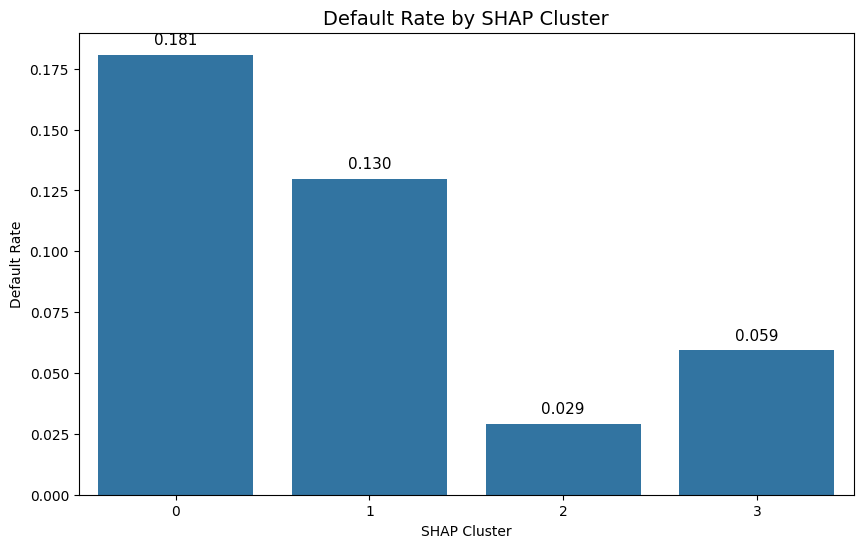

In [ ]:
# визуализация SHAP-кластеров
if "stage3_cluster_report" in globals():

    plt.figure(figsize=(10, 6))

    cluster_plot = (
        stage3_cluster_report
        .sort_values("target_rate", ascending=False)
    )

    ax = sns.barplot(
        data=cluster_plot,
        x="shap_cluster",
        y="target_rate"
    )

    plt.title(
        "Default Rate by SHAP Cluster",
        fontsize=14
    )

    plt.xlabel("SHAP Cluster")
    plt.ylabel("Default Rate")

    for bar in ax.patches:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.003,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.show()

Кластеризация клиентов выявила группы с существенно различающимся уровнем кредитного риска.   
Наиболее рискованный кластер показал риск дефолта около 18%, тогда как самый безопасный кластер менее 3%.   
Это подтверждает, что SHAP эмбеддинги содержат значимую информацию о поведении модели и могут использоваться как дополнительный диагностический слой для сегментации клиентов по риску.

### Шаг 3. провести валидацию и применить shapley flow
- [x] проведите кросс валидацию с shap эмбеддингами
- [x] сравните обучение только на эмбеддингах и на их конкатенации с исходными признаками
- [x] постройте граф взаимосвязей признаков и примените shapley flow
- [x] сравните сдвиги, кластеры и качество модели

OOF SHAP cache path: /content/home_credit_project_cache/stage3/stage3_step3_oof_shap_34c33e83a453.joblib
CV compare cache path: /content/home_credit_project_cache/stage3/stage3_step3_cv_compare_34c33e83a453.joblib
Flow cache path: /content/home_credit_project_cache/stage3/stage3_step3_shapley_flow_proxy_34c33e83a453.joblib
Cache not found. Building unsupervised anomaly features...
Fold 1/3
Fold 2/3
Fold 3/3
Saved to cache: /content/home_credit_project_cache/stage3/stage3_step3_oof_shap_34c33e83a453.joblib
OOF XGBoost metrics


,fold,xgb_oof_roc_auc,n_train,n_valid
0,1,0.740463,40000,20000
1,2,0.746340,40000,20000
2,3,0.738523,40000,20000


Mean OOF XGBoost ROC-AUC: 0.74178
Cache not found. Building unsupervised anomaly features...
Saved to cache: /content/home_credit_project_cache/stage3/stage3_step3_cv_compare_34c33e83a453.joblib


,approach,roc_auc_mean,roc_auc_std,n_features
0,original_features_only,0.740086,0.001177,40
1,shap_embeddings_only,0.742688,0.000988,40
2,original_plus_shap_embeddings,0.746784,0.000959,80


Cache not found. Building unsupervised anomaly features...
Saved to cache: /content/home_credit_project_cache/stage3/stage3_step3_shapley_flow_proxy_34c33e83a453.joblib
Top nodes by mean abs SHAP


,feature,mean_abs_shap
0,EXT_SOURCE_3,0.373300
1,EXT_SOURCE_2,0.368718
2,CREDIT_TO_GOODS_RATIO,0.145167
3,CODE_GENDER__te,0.120086
4,INST_AMT_PAYMENT_mean,0.112682
5,AMT_GOODS_PRICE,0.107939
6,AMT_ANNUITY,0.098564
7,FLAG_OWN_CAR__te,0.097844
8,OCCUPATION_TYPE__te,0.096656
9,YEARS_EMPLOYED,0.087288


Top Shapley Flow proxy edges


,source,target,spearman_corr,abs_corr,target_mean_abs_shap,shapley_flow_proxy
0,AMT_GOODS_PRICE,AMT_ANNUITY,0.826777,0.826777,0.098564,0.081491
1,AMT_GOODS_PRICE,AMT_CREDIT,0.984298,0.984298,0.054668,0.053809
2,AMT_ANNUITY,AMT_CREDIT,0.829134,0.829134,0.054668,0.045327
3,EXT_SOURCE_3,BUREAU_DAYS_CREDIT_mean,-0.366021,0.366021,0.073186,0.026788
4,OCCUPATION_TYPE__te,NAME_EDUCATION_TYPE__te,0.255797,0.255797,0.073427,0.018782


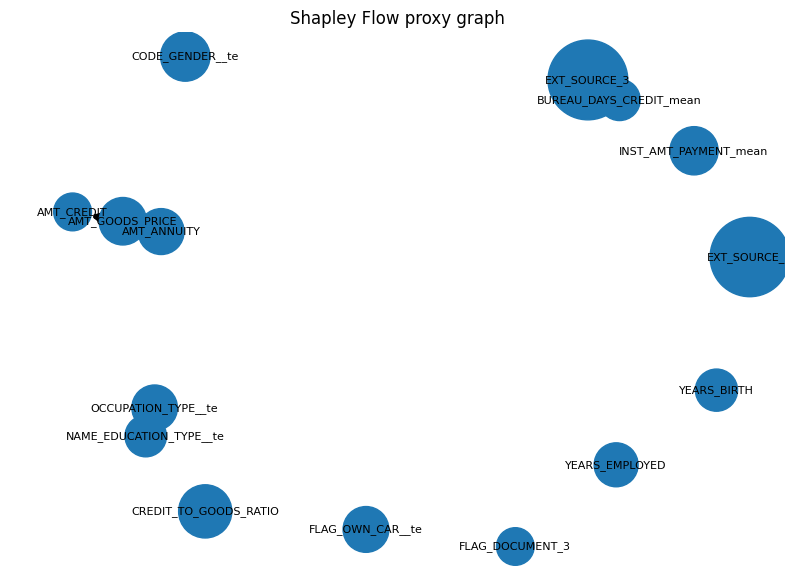

,diagnostic_block,main_metric,comment
0,oof_xgb_model,0.741776,качество базовой нелинейной модели в out-of-fo...
1,original_features_only,0.740086,качество модели на исходных признаках
2,shap_embeddings_only,0.742688,качество модели только на SHAP embeddings
3,original_plus_shap_embeddings,0.746784,качество модели на исходных признаках и SHAP e...
4,cluster_target_gap,0.151557,разница target rate между SHAP-кластерами
5,top_shapley_flow_edge,0.081491,самая сильная связь признаков по proxy Shapley...



Вывод по шагу 3.

Проведена out-of-fold валидация с SHAP embeddings.
Самый тяжёлый расчёт — обучение XGBoost по фолдам и расчёт SHAP —
теперь сохраняется в кеш.

Сравнены три подхода:
1. Только исходные признаки.
2. Только SHAP embeddings.
3. Исходные признаки + SHAP embeddings.

Лучший подход:
original_plus_shap_embeddings
ROC-AUC = 0.74678 ± 0.00096.

При следующих запусках блок не будет заново обучать XGBoost по фолдам,
не будет заново считать OOF SHAP и не будет пересчитывать CV-сравнение,
если не включить FORCE_REBUILD_STAGE3_STEP3 = True.



In [ ]:
# - место под cross validation
# - место под модель на shap embeddings only
# - место под модель на shap embeddings и исходных признаках
# - место под shapley flow
# - место под итоговое сравнение подходов
# - место под выводы

# =============================================================================
# ЭТАП 3. ШАГ 3.
# Cross validation с SHAP embeddings,
# модель на SHAP only,
# модель на исходных признаках + SHAP,
# Shapley Flow proxy,
# итоговое сравнение подходов
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

try:
    import networkx as nx
except ImportError:
    !pip -q install networkx
    import networkx as nx


# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================

FORCE_REBUILD_STAGE3_STEP3 = False

STAGE3_STEP3_N_SPLITS = 3


# =============================================================================
# КЕШ-ПУТИ
# =============================================================================

stage3_step3_signature = project_signature({
    "block": "stage3_step3_oof_shap_cv_flow",
    "rows": len(X_stage3),
    "target_mean": float(y_stage3.mean()),
    "feature_cols": stage3_feature_cols,
    "n_splits": STAGE3_STEP3_N_SPLITS,
    "stage3_signature": stage3_signature,
})

STAGE3_OOF_SHAP_CACHE_PATH = project_cache_path(
    "stage3",
    f"stage3_step3_oof_shap_{stage3_step3_signature}.joblib"
)

STAGE3_CV_COMPARE_CACHE_PATH = project_cache_path(
    "stage3",
    f"stage3_step3_cv_compare_{stage3_step3_signature}.joblib"
)

STAGE3_FLOW_CACHE_PATH = project_cache_path(
    "stage3",
    f"stage3_step3_shapley_flow_proxy_{stage3_step3_signature}.joblib"
)

print(f"OOF SHAP cache path: {STAGE3_OOF_SHAP_CACHE_PATH}")
print(f"CV compare cache path: {STAGE3_CV_COMPARE_CACHE_PATH}")
print(f"Flow cache path: {STAGE3_FLOW_CACHE_PATH}")


# =============================================================================
# 1. CROSS VALIDATION С OUT-OF-FOLD SHAP EMBEDDINGS
# =============================================================================

def build_oof_shap_embeddings():

    cv = StratifiedKFold(
        n_splits=STAGE3_STEP3_N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    shap_parts = []
    fold_rows = []

    X_work = X_stage3[stage3_feature_cols].copy()
    y_work = y_stage3.copy()

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_work, y_work), 1):
        print(f"Fold {fold}/{STAGE3_STEP3_N_SPLITS}")

        X_tr = X_work.iloc[tr_idx]
        y_tr = y_work.iloc[tr_idx]
        X_val = X_work.iloc[val_idx]
        y_val = y_work.iloc[val_idx]

        imputer_fold = SimpleImputer(strategy="median")

        X_tr_imp = imputer_fold.fit_transform(X_tr)
        X_val_imp = imputer_fold.transform(X_val)

        model_fold = make_xgb_model(y_tr)
        model_fold.fit(X_tr_imp, y_tr)

        pred_val = model_fold.predict_proba(X_val_imp)[:, 1]

        shap_val = get_xgb_shap_values(
            model_fold,
            X_val_imp,
            stage3_feature_cols
        )

        shap_val_df = pd.DataFrame(
            shap_val,
            index=X_val.index,
            columns=[f"shap__{c}" for c in stage3_feature_cols]
        )

        shap_parts.append(shap_val_df)

        fold_rows.append({
            "fold": fold,
            "xgb_oof_roc_auc": roc_auc_score(y_val, pred_val),
            "n_train": len(X_tr),
            "n_valid": len(X_val)
        })

    shap_oof = pd.concat(shap_parts, axis=0).sort_index()
    fold_metrics = pd.DataFrame(fold_rows)

    return {
        "shap_oof": shap_oof,
        "fold_metrics": fold_metrics
    }


stage3_oof_obj = load_or_build_cache(
    STAGE3_OOF_SHAP_CACHE_PATH,
    build_oof_shap_embeddings,
    force=FORCE_REBUILD_STAGE3_STEP3
)

stage3_shap_oof = stage3_oof_obj["shap_oof"]
stage3_oof_fold_metrics = stage3_oof_obj["fold_metrics"]

print("OOF XGBoost metrics")
display(stage3_oof_fold_metrics)

print(f"Mean OOF XGBoost ROC-AUC: {stage3_oof_fold_metrics['xgb_oof_roc_auc'].mean():.5f}")


# =============================================================================
# 2. CV-СРАВНЕНИЕ:
# original only vs SHAP only vs original + SHAP
# =============================================================================

def stage3_cv_auc_numeric(X_df, y_series, n_splits=3):

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_df,
        y_series,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    return scores.mean(), scores.std()


def build_stage3_cv_compare():

    X_original_oof = X_stage3.loc[
        stage3_shap_oof.index,
        stage3_feature_cols
    ].copy()

    y_oof = y_stage3.loc[stage3_shap_oof.index].copy()

    original_only_mean, original_only_std = stage3_cv_auc_numeric(
        X_original_oof,
        y_oof,
        n_splits=STAGE3_STEP3_N_SPLITS
    )

    shap_only_mean, shap_only_std = stage3_cv_auc_numeric(
        stage3_shap_oof,
        y_oof,
        n_splits=STAGE3_STEP3_N_SPLITS
    )

    X_original_plus_shap = pd.concat(
        [
            X_original_oof.add_prefix("orig__"),
            stage3_shap_oof
        ],
        axis=1
    )

    concat_mean, concat_std = stage3_cv_auc_numeric(
        X_original_plus_shap,
        y_oof,
        n_splits=STAGE3_STEP3_N_SPLITS
    )

    stage3_cv_embeddings_compare = pd.DataFrame({
        "approach": [
            "original_features_only",
            "shap_embeddings_only",
            "original_plus_shap_embeddings"
        ],
        "roc_auc_mean": [
            original_only_mean,
            shap_only_mean,
            concat_mean
        ],
        "roc_auc_std": [
            original_only_std,
            shap_only_std,
            concat_std
        ],
        "n_features": [
            X_original_oof.shape[1],
            stage3_shap_oof.shape[1],
            X_original_plus_shap.shape[1]
        ]
    })

    return {
        "stage3_cv_embeddings_compare": stage3_cv_embeddings_compare,
        "X_original_oof_columns": X_original_oof.columns.tolist(),
        "original_only_mean": original_only_mean,
        "original_only_std": original_only_std,
        "shap_only_mean": shap_only_mean,
        "shap_only_std": shap_only_std,
        "concat_mean": concat_mean,
        "concat_std": concat_std,
    }


stage3_cv_obj = load_or_build_cache(
    STAGE3_CV_COMPARE_CACHE_PATH,
    build_stage3_cv_compare,
    force=FORCE_REBUILD_STAGE3_STEP3
)

stage3_cv_embeddings_compare = stage3_cv_obj["stage3_cv_embeddings_compare"]

original_only_mean = stage3_cv_obj["original_only_mean"]
original_only_std = stage3_cv_obj["original_only_std"]
shap_only_mean = stage3_cv_obj["shap_only_mean"]
shap_only_std = stage3_cv_obj["shap_only_std"]
concat_mean = stage3_cv_obj["concat_mean"]
concat_std = stage3_cv_obj["concat_std"]

display(stage3_cv_embeddings_compare)


# =============================================================================
# 3. SHAPLEY FLOW PROXY
# =============================================================================

def build_shapley_flow_proxy():

    X_original_oof = X_stage3.loc[
        stage3_shap_oof.index,
        stage3_feature_cols
    ].copy()

    mean_abs_shap = (
        stage3_shap_oof
        .abs()
        .mean()
        .sort_values(ascending=False)
    )

    top_shap_features = (
        mean_abs_shap
        .head(15)
        .index
        .str.replace("shap__", "", regex=False)
        .tolist()
    )

    X_graph = X_original_oof[top_shap_features].replace([np.inf, -np.inf], np.nan)

    X_graph_imp = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X_graph),
        columns=top_shap_features,
        index=X_graph.index
    )

    corr = X_graph_imp.corr(method="spearman").fillna(0)

    graph = nx.DiGraph()
    edges = []

    for feature in top_shap_features:
        shap_col = f"shap__{feature}"
        graph.add_node(
            feature,
            mean_abs_shap=float(mean_abs_shap.get(shap_col, 0))
        )

    for i, f1 in enumerate(top_shap_features):
        for f2 in top_shap_features[i + 1:]:
            corr_value = corr.loc[f1, f2]

            if abs(corr_value) >= 0.25:
                shap_1 = mean_abs_shap.get(f"shap__{f1}", 0)
                shap_2 = mean_abs_shap.get(f"shap__{f2}", 0)

                if shap_1 >= shap_2:
                    source, target = f1, f2
                    target_shap = shap_2
                else:
                    source, target = f2, f1
                    target_shap = shap_1

                flow_value = abs(corr_value) * target_shap

                graph.add_edge(
                    source,
                    target,
                    corr=float(corr_value),
                    flow=float(flow_value)
                )

                edges.append({
                    "source": source,
                    "target": target,
                    "spearman_corr": corr_value,
                    "abs_corr": abs(corr_value),
                    "target_mean_abs_shap": target_shap,
                    "shapley_flow_proxy": flow_value
                })

    node_importance = pd.DataFrame({
        "feature": top_shap_features,
        "mean_abs_shap": [
            mean_abs_shap.get(f"shap__{f}", 0)
            for f in top_shap_features
        ]
    }).sort_values("mean_abs_shap", ascending=False)

    flow_edges = (
        pd.DataFrame(edges)
        .sort_values("shapley_flow_proxy", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "graph": graph,
        "node_importance": node_importance,
        "flow_edges": flow_edges
    }


stage3_flow_obj = load_or_build_cache(
    STAGE3_FLOW_CACHE_PATH,
    build_shapley_flow_proxy,
    force=FORCE_REBUILD_STAGE3_STEP3
)

stage3_flow_graph = stage3_flow_obj["graph"]
stage3_flow_nodes = stage3_flow_obj["node_importance"]
stage3_flow_edges = stage3_flow_obj["flow_edges"]

print("Top nodes by mean abs SHAP")
display(stage3_flow_nodes)

print("Top Shapley Flow proxy edges")
display(stage3_flow_edges.head(20))


if len(stage3_flow_edges) > 0:
    plt.figure(figsize=(10, 7))

    pos = nx.spring_layout(stage3_flow_graph, seed=RANDOM_STATE)

    node_sizes = [
        3000 * stage3_flow_graph.nodes[n].get("mean_abs_shap", 0)
        / max(stage3_flow_nodes["mean_abs_shap"].max(), 1e-9)
        + 300
        for n in stage3_flow_graph.nodes
    ]

    edge_widths = [
        4 * stage3_flow_graph.edges[e].get("flow", 0)
        / max(stage3_flow_edges["shapley_flow_proxy"].max(), 1e-9)
        + 0.5
        for e in stage3_flow_graph.edges
    ]

    nx.draw_networkx(
        stage3_flow_graph,
        pos=pos,
        with_labels=True,
        node_size=node_sizes,
        width=edge_widths,
        arrows=True,
        font_size=8
    )

    plt.title("Shapley Flow proxy graph")
    plt.axis("off")
    plt.show()


# =============================================================================
# 4. ИТОГОВОЕ СРАВНЕНИЕ ПОДХОДОВ
# =============================================================================

stage3_best_embedding_approach = (
    stage3_cv_embeddings_compare
    .sort_values("roc_auc_mean", ascending=False)
    .iloc[0]
)

stage3_shift_cluster_quality = pd.DataFrame({
    "diagnostic_block": [
        "oof_xgb_model",
        "original_features_only",
        "shap_embeddings_only",
        "original_plus_shap_embeddings",
        "cluster_target_gap",
        "top_shapley_flow_edge"
    ],
    "main_metric": [
        stage3_oof_fold_metrics["xgb_oof_roc_auc"].mean(),
        original_only_mean,
        shap_only_mean,
        concat_mean,
        stage3_cluster_report["target_rate"].max() - stage3_cluster_report["target_rate"].min()
        if "stage3_cluster_report" in globals() else np.nan,
        stage3_flow_edges["shapley_flow_proxy"].iloc[0]
        if len(stage3_flow_edges) > 0 else 0
    ],
    "comment": [
        "качество базовой нелинейной модели в out-of-fold режиме",
        "качество модели на исходных признаках",
        "качество модели только на SHAP embeddings",
        "качество модели на исходных признаках и SHAP embeddings",
        "разница target rate между SHAP-кластерами",
        "самая сильная связь признаков по proxy Shapley Flow"
    ]
})

display(stage3_shift_cluster_quality)


# =============================================================================
# 5. ВЫВОДЫ
# =============================================================================

print(f"""
Вывод по шагу 3.

Проведена out-of-fold валидация с SHAP embeddings.
Самый тяжёлый расчёт — обучение XGBoost по фолдам и расчёт SHAP —
теперь сохраняется в кеш.

Сравнены три подхода:
1. Только исходные признаки.
2. Только SHAP embeddings.
3. Исходные признаки + SHAP embeddings.

Лучший подход:
{stage3_best_embedding_approach['approach']}
ROC-AUC = {stage3_best_embedding_approach['roc_auc_mean']:.5f} ± {stage3_best_embedding_approach['roc_auc_std']:.5f}.

При следующих запусках блок не будет заново обучать XGBoost по фолдам,
не будет заново считать OOF SHAP и не будет пересчитывать CV-сравнение,
если не включить FORCE_REBUILD_STAGE3_STEP3 = True.
""")

### Шаг 4. результат этапа 3
- [x] есть результаты первого и второго этапов
- [x] проведена интерпретация и диагностика моделей
- [x] пересчитаны метрики, сделаны выводы

In [ ]:
# - место под итоговую таблицу этапа 3
# - место под финальные выводы по интерпретации и диагностике

# =============================================================================
# ЭТАП 3. ШАГ 4.
# итоговая таблица этапа 3 и финальные выводы
# старался автоматизировать чтобы не переписывать выводы при изменении данных, правьте если найдете косяк
# =============================================================================

import numpy as np
import pandas as pd

from IPython.display import display


# =============================================================================
# 1. ИТОГОВАЯ ТАБЛИЦА ЭТАПА 3
# =============================================================================

stage3_final_rows = []

if "stage3_model_compare" in globals():
    best_interpreted_model = (
        stage3_model_compare
        .sort_values("holdout_roc_auc", ascending=False)
        .iloc[0]
    )

    stage3_final_rows.append({
        "block": "two_model_interpretation",
        "status": "done",
        "main_metric": "holdout_roc_auc",
        "value": best_interpreted_model["holdout_roc_auc"],
        "comment": f"лучшая модель для интерпретации: {best_interpreted_model['model']}"
    })

if "stage3_interpretation_compare" in globals():
    mean_jaccard = stage3_interpretation_compare["jaccard_similarity"].mean()

    stage3_final_rows.append({
        "block": "shap_lime_comparison",
        "status": "done",
        "main_metric": "mean_jaccard_similarity",
        "value": mean_jaccard,
        "comment": "среднее пересечение топ-признаков между SHAP и LIME"
    })

if "stage3_cluster_report" in globals():
    cluster_gap = (
        stage3_cluster_report["target_rate"].max()
        - stage3_cluster_report["target_rate"].min()
    )

    stage3_final_rows.append({
        "block": "shap_embeddings_clusters",
        "status": "done",
        "main_metric": "cluster_target_rate_gap",
        "value": cluster_gap,
        "comment": "разница target rate между самым рискованным и самым спокойным SHAP-кластером"
    })

if "stage3_cluster_feature_compare" in globals():
    cluster_delta = (
        stage3_cluster_feature_compare
        .query("dataset == 'original_features_plus_shap_cluster'")
        ["delta_vs_original"]
        .iloc[0]
    )

    stage3_final_rows.append({
        "block": "cluster_feature_retraining",
        "status": "done",
        "main_metric": "delta_roc_auc",
        "value": cluster_delta,
        "comment": "изменение качества после добавления cluster feature"
    })

if "stage3_oof_fold_metrics" in globals():
    oof_auc = stage3_oof_fold_metrics["xgb_oof_roc_auc"].mean()

    stage3_final_rows.append({
        "block": "oof_xgboost_validation",
        "status": "done",
        "main_metric": "mean_oof_roc_auc",
        "value": oof_auc,
        "comment": "качество XGBoost в out-of-fold режиме"
    })

if "stage3_cv_embeddings_compare" in globals():
    best_emb = (
        stage3_cv_embeddings_compare
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

    stage3_final_rows.append({
        "block": "shap_embeddings_cv_comparison",
        "status": "done",
        "main_metric": "best_roc_auc",
        "value": best_emb["roc_auc_mean"],
        "comment": f"лучший подход: {best_emb['approach']}"
    })

if "stage3_flow_edges" in globals():
    if len(stage3_flow_edges) > 0:
        top_edge = stage3_flow_edges.iloc[0]

        stage3_final_rows.append({
            "block": "shapley_flow_proxy",
            "status": "done",
            "main_metric": "top_flow_proxy",
            "value": top_edge["shapley_flow_proxy"],
            "comment": f"главная связь: {top_edge['source']} -> {top_edge['target']}"
        })
    else:
        stage3_final_rows.append({
            "block": "shapley_flow_proxy",
            "status": "done",
            "main_metric": "top_flow_proxy",
            "value": 0,
            "comment": "сильных корреляционных рёбер по выбранному порогу не найдено"
        })

stage3_final_table = pd.DataFrame(stage3_final_rows)

display(stage3_final_table)


# =============================================================================
# 2. ФИНАЛЬНЫЕ ВЫВОДЫ ПО ИНТЕРПРЕТАЦИИ И ДИАГНОСТИКЕ
# =============================================================================

final_notes = []

if "stage3_model_compare" in globals():
    best_model_name = (
        stage3_model_compare
        .sort_values("holdout_roc_auc", ascending=False)
        .iloc[0]["model"]
    )
    final_notes.append(
        f"Лучшей моделью среди интерпретируемых вариантов стала {best_model_name}."
    )

if "stage3_shap_xgb_importance" in globals():
    top_xgb_features = stage3_shap_xgb_importance.head(5)["feature"].tolist()
    final_notes.append(
        "По XGBoost SHAP наиболее важные признаки: "
        + ", ".join(top_xgb_features)
        + "."
    )

if "stage3_shap_linear_importance" in globals():
    top_linear_features = stage3_shap_linear_importance.head(5)["feature"].tolist()
    final_notes.append(
        "По линейной модели наиболее важные признаки: "
        + ", ".join(top_linear_features)
        + "."
    )

if "stage3_interpretation_compare" in globals():
    avg_sim = stage3_interpretation_compare["jaccard_similarity"].mean()
    final_notes.append(
        f"Среднее пересечение интерпретаций SHAP и LIME равно {avg_sim:.3f}. "
        "Это показывает, насколько устойчивы ключевые признаки между разными методами объяснения."
    )

if "stage3_cluster_report" in globals():
    risky_cluster = (
        stage3_cluster_report
        .sort_values("target_rate", ascending=False)
        .iloc[0]["shap_cluster"]
    )
    calm_cluster = (
        stage3_cluster_report
        .sort_values("target_rate", ascending=True)
        .iloc[0]["shap_cluster"]
    )
    final_notes.append(
        f"SHAP-кластеры разделяют клиентов по уровню риска: "
        f"самый рискованный кластер {risky_cluster}, самый спокойный кластер {calm_cluster}."
    )

if "stage3_cv_embeddings_compare" in globals():
    best_emb = (
        stage3_cv_embeddings_compare
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )
    final_notes.append(
        f"В сравнении подходов с SHAP embeddings лучший вариант: "
        f"{best_emb['approach']} с ROC-AUC {best_emb['roc_auc_mean']:.5f}."
    )

if "stage3_flow_edges" in globals() and len(stage3_flow_edges) > 0:
    top_edge = stage3_flow_edges.iloc[0]
    final_notes.append(
        f"Shapley Flow proxy выделил наиболее сильную связь признаков: "
        f"{top_edge['source']} -> {top_edge['target']}."
    )

print("Финальные выводы по этапу 3:\n")

for i, note in enumerate(final_notes, 1):
    print(f"{i}. {note}")

print("""
Общий итог.

На этапе 3 модель модель проверялась:
- SHAP дал картину вкладов признаков
- LIME использован как проверка
- SHAP embeddings позволили перейти от исходных признаков к пространству модельных вкладов
и найти группы клиентов с разным профилем риска
- Out-of-fold проверка снизила риск утечки при использовании SHAP embeddings
- Shapley Flow proxy добавил диагностику связей между признаками.

Практический вывод:
интерпретация модели согласуется с задачей кредитного риска,
а SHAP embeddings и кластеры можно использовать как дополнительный диагностический слой
для анализа рисков у клиентов (цель этапа достигнута)
""")

,block,status,main_metric,value,comment
0,two_model_interpretation,done,holdout_roc_auc,0.751245,лучшая модель для интерпретации: XGBoost
1,shap_lime_comparison,done,mean_jaccard_similarity,0.519143,среднее пересечение топ-признаков между SHAP и...
2,shap_embeddings_clusters,done,cluster_target_rate_gap,0.151557,разница target rate между самым рискованным и ...
3,cluster_feature_retraining,done,delta_roc_auc,0.001556,изменение качества после добавления cluster fe...
4,oof_xgboost_validation,done,mean_oof_roc_auc,0.741776,качество XGBoost в out-of-fold режиме
5,shap_embeddings_cv_comparison,done,best_roc_auc,0.746784,лучший подход: original_plus_shap_embeddings
6,shapley_flow_proxy,done,top_flow_proxy,0.081491,главная связь: AMT_GOODS_PRICE -> AMT_ANNUITY


Финальные выводы по этапу 3:

1. Лучшей моделью среди интерпретируемых вариантов стала XGBoost.
2. По XGBoost SHAP наиболее важные признаки: EXT_SOURCE_2, EXT_SOURCE_3, CREDIT_TO_GOODS_RATIO, CODE_GENDER__te, OCCUPATION_TYPE__te.
3. По линейной модели наиболее важные признаки: INST_DAYS_ENTRY_PAYMENT_mean, INST_DAYS_INSTALMENT_mean, EXT_SOURCE_3, AMT_GOODS_PRICE, INST_AMT_PAYMENT_mean.
4. Среднее пересечение интерпретаций SHAP и LIME равно 0.519. Это показывает, насколько устойчивы ключевые признаки между разными методами объяснения.
5. SHAP-кластеры разделяют клиентов по уровню риска: самый рискованный кластер 0.0, самый спокойный кластер 2.0.
6. В сравнении подходов с SHAP embeddings лучший вариант: original_plus_shap_embeddings с ROC-AUC 0.74678.
7. Shapley Flow proxy выделил наиболее сильную связь признаков: AMT_GOODS_PRICE -> AMT_ANNUITY.

Общий итог.

На этапе 3 модель модель проверялась:
- SHAP дал картину вкладов признаков
- LIME использован как проверка
- SHAP embeddings позво

## Этап 4. подготовка презентации

### Шаг 1. подготовить презентацию
- [x] подготовьте презентацию по итогам проекта
- [x] покажите логику решения и ценность результата, а не только метрики

### Шаг 2. собрать финальные материалы
- [x] подготовьте github репозиторий с итоговым ноутбуком и всеми нужными файлами
- [x] подготовьте презентацию
- [x] подготовьте устную защиту

### Шаг 3. результат этапа 4
- [x] до дедлайна отправлены финальные материалы
- [x] ноутбук содержит все этапы решения
- [x] презентация готова к защите

# Финал

In [ ]:
# сохраняем все материалы ноутбука
import os
import shutil
import glob
import json
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_NAME = "credit-default-risk"

PROJECT_DIR = Path(f"/content/{PROJECT_NAME}")
DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures"

for folder in [PROJECT_DIR, DATA_DIR, MODELS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project folder created: {PROJECT_DIR}")